# Emotion Detection using Natural Language Processing

## 1. Problem Statement

The objective of this project is to build a machine learning model capable of identifying human emotions from textual data.

The dataset contains sentences labeled with different emotions such as sadness, joy, anger, fear, love, and surprise.

The project follows a complete NLP pipeline including:

- Data loading
- Data cleaning
- Text preprocessing
- Exploratory Data Analysis
- Feature Engineering
- Machine Learning model development
- Hyperparameter tuning
- Model evaluation
- Best model selection

Finally, the trained model will be capable of predicting emotions from unseen text.

# 2. Import Required Libraries

In this section, we import all the required Python libraries that will be used throughout the project for data manipulation, visualization, text preprocessing, feature engineering, machine learning model development, and evaluation.

In [1]:
# ===========================
# Data Manipulation
# ===========================
import os
import re
import string
import warnings

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

# ===========================
# Visualization
# ===========================
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

# ===========================
# NLP Libraries
# ===========================
import nltk

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer

# Download required NLTK resources
nltk.download("stopwords")
nltk.download("punkt")
nltk.download("wordnet")
nltk.download("omw-1.4")

# ===========================
# Display Settings
# ===========================
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 200)

# ===========================
# Random Seed
# ===========================
SEED = 42
np.random.seed(SEED)

print("=" * 60)
print("Libraries Imported Successfully")
print("=" * 60)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\nakul\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\nakul\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\nakul\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\nakul\AppData\Roaming\nltk_data...


Libraries Imported Successfully


[nltk_data]   Package omw-1.4 is already up-to-date!


# 3.1 Load the Emotion Dataset

The dataset consists of three text files:

- train.txt
- test.txt
- val.txt

Each record in these files is stored in the following format:

Sentence ; Emotion

In this step, we will define the location of our dataset files.

In [2]:
# ==========================================
# Define Dataset Location
# ==========================================

# Folder containing the dataset files
DATA_PATH = "data"

# File paths
train_file = os.path.join(DATA_PATH, "train.txt")
test_file = os.path.join(DATA_PATH, "test.txt")
val_file = os.path.join(DATA_PATH, "val.txt")

print("Train File :", train_file)
print("Test File  :", test_file)
print("Validation File :", val_file)

Train File : data\train.txt
Test File  : data\test.txt
Validation File : data\val.txt


# 3.2 Create a Reusable Function to Load the Dataset

Instead of writing the same code three times for the training, testing, and validation datasets, we create a reusable function.

This approach makes the code:
- Easier to maintain
- More readable
- Reusable for similar datasets
- Aligned with industry best practices

In [3]:
# ==========================================
# Function to Load Emotion Dataset
# ==========================================

def load_emotion_file(filepath, dataset_name):
    """
    Load an emotion dataset into a pandas DataFrame.

    Parameters
    ----------
    filepath : str
        Path to the dataset file.

    dataset_name : str
        Name of the dataset (Train, Test or Validation).

    Returns
    -------
    pandas.DataFrame
        DataFrame containing the text, emotion label, and dataset source.
    """

    df = pd.read_csv(
        filepath,
        sep=";",
        header=None,
        names=["text", "emotion"],
        encoding="utf-8"
    )

    # Add a column to identify the source dataset
    df["dataset"] = dataset_name

    return df

print("Function 'load_emotion_file()' created successfully.")

Function 'load_emotion_file()' created successfully.


# 3.3 Load the Training Dataset

In this step, we load only the training dataset using the reusable function created in the previous step.

Loading one dataset at a time helps verify that the function works correctly before using it for the remaining datasets.

In [4]:
# ==========================================
# Load Training Dataset
# ==========================================

train_df = load_emotion_file(train_file, "Train")

print("=" * 60)
print("Training Dataset Loaded Successfully")
print("=" * 60)

print(f"Shape of Training Dataset : {train_df.shape}")

print("\nFirst Five Records:")
display(train_df.head())

Training Dataset Loaded Successfully
Shape of Training Dataset : (16000, 3)

First Five Records:


,text,emotion,dataset
0,i didnt feel humiliated,sadness,Train
1,i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake,sadness,Train
2,im grabbing a minute to post i feel greedy wrong,anger,Train
3,i am ever feeling nostalgic about the fireplace i will know that it is still on the property,love,Train
4,i am feeling grouchy,anger,Train


# 3.4 Load the Validation Dataset

The validation dataset is used during model development to evaluate model performance while tuning hyperparameters.

In this step, we load the validation dataset using the reusable function.

In [5]:
# ==========================================
# Load Validation Dataset
# ==========================================

val_df = load_emotion_file(val_file, "Validation")

print("=" * 60)
print("Validation Dataset Loaded Successfully")
print("=" * 60)

print(f"Shape of Validation Dataset : {val_df.shape}")

print("\nFirst Five Records:")
display(val_df.head())

Validation Dataset Loaded Successfully
Shape of Validation Dataset : (2000, 3)

First Five Records:


,text,emotion,dataset
0,im feeling quite sad and sorry for myself but ill snap out of it soon,sadness,Validation
1,i feel like i am still looking at a blank canvas blank pieces of paper,sadness,Validation
2,i feel like a faithful servant,love,Validation
3,i am just feeling cranky and blue,anger,Validation
4,i can have for a treat or if i am feeling festive,joy,Validation


# 3.5 Load the Test Dataset

The test dataset is reserved for the final evaluation of the machine learning models.

It helps measure how well the trained model generalizes to unseen data.

In [6]:
# ==========================================
# Load Test Dataset
# ==========================================

test_df = load_emotion_file(test_file, "Test")

print("=" * 60)
print("Test Dataset Loaded Successfully")
print("=" * 60)

print(f"Shape of Test Dataset : {test_df.shape}")

print("\nFirst Five Records:")
display(test_df.head())

Test Dataset Loaded Successfully
Shape of Test Dataset : (2000, 3)

First Five Records:


,text,emotion,dataset
0,im feeling rather rotten so im not very ambitious right now,sadness,Test
1,im updating my blog because i feel shitty,sadness,Test
2,i never make her separate from me because i don t ever want her to feel like i m ashamed with her,sadness,Test
3,i left with my bouquet of red and yellow tulips under my arm feeling slightly more optimistic than when i arrived,joy,Test
4,i was feeling a little vain when i did this one,sadness,Test


# 3.6 Combine the Datasets

For exploratory data analysis (EDA), it is convenient to work with a single DataFrame containing all records.

In this step, we combine the training, validation, and test datasets into one master DataFrame.

The original datasets remain unchanged and will be used later for model development.

In [7]:
# ==========================================
# Combine All Datasets
# ==========================================

df = pd.concat(
    [train_df, val_df, test_df],
    ignore_index=True
)

print("=" * 60)
print("Master Dataset Created Successfully")
print("=" * 60)

print(f"Shape of Master Dataset : {df.shape}")

print("\nDataset Distribution:")
print(df["dataset"].value_counts())

print("\nFirst Five Records:")
display(df.head())

Master Dataset Created Successfully
Shape of Master Dataset : (20000, 3)

Dataset Distribution:
dataset
Train         16000
Validation     2000
Test           2000
Name: count, dtype: int64

First Five Records:


,text,emotion,dataset
0,i didnt feel humiliated,sadness,Train
1,i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake,sadness,Train
2,im grabbing a minute to post i feel greedy wrong,anger,Train
3,i am ever feeling nostalgic about the fireplace i will know that it is still on the property,love,Train
4,i am feeling grouchy,anger,Train


# 4.1 Initial Data Inspection

## Basic Dataset Information

Before performing any preprocessing or analysis, it is important to understand the overall structure of the dataset.

In this step, we will inspect:

- Number of rows and columns
- Column names
- Data types
- Missing values
- Memory usage

This provides a quick overview of the dataset and helps identify any potential issues before moving to data cleaning.

In [8]:
# ==========================================
# Basic Dataset Information
# ==========================================

print("=" * 60)
print("Dataset Shape")
print("=" * 60)
print(df.shape)

print("\n" + "=" * 60)
print("Dataset Information")
print("=" * 60)

df.info()

Dataset Shape
(20000, 3)

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   text     20000 non-null  object
 1   emotion  20000 non-null  object
 2   dataset  20000 non-null  object
dtypes: object(3)
memory usage: 468.9+ KB


# 4.2 Statistical Summary of the Dataset

The `describe()` function provides a statistical summary of the dataset.

Since this dataset contains text and categorical columns, we use:

`describe(include="all")`

This allows us to inspect:

- Number of unique values
- Most frequent values
- Frequency of the most common values

This helps us better understand the structure of the dataset before performing exploratory data analysis.

In [9]:
# ==========================================
# Statistical Summary
# ==========================================

print("=" * 60)
print("Statistical Summary of the Dataset")
print("=" * 60)

display(df.describe(include="all"))

Statistical Summary of the Dataset


,text,emotion,dataset
count,20000,20000,20000
unique,19948,6,3
top,i have chose for myself that makes me feel amazing,joy,Train
freq,2,6761,16000


# 4.3 Inspect Sample Records

To better understand the dataset, we inspect sample records from both the beginning and the end of the DataFrame.

This helps verify:

- The dataset has been loaded correctly.
- The text format is consistent.
- Emotion labels appear as expected.
- The dataset concatenation has been performed successfully.

In [10]:
# ==========================================
# Display Sample Records
# ==========================================

print("=" * 60)
print("First Five Records")
print("=" * 60)
display(df.head())

print("\n" + "=" * 60)
print("Last Five Records")
print("=" * 60)
display(df.tail())

First Five Records


,text,emotion,dataset
0,i didnt feel humiliated,sadness,Train
1,i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake,sadness,Train
2,im grabbing a minute to post i feel greedy wrong,anger,Train
3,i am ever feeling nostalgic about the fireplace i will know that it is still on the property,love,Train
4,i am feeling grouchy,anger,Train



Last Five Records


,text,emotion,dataset
19995,i just keep feeling like someone is being unkind to me and doing me wrong and then all i can think of doing is to get back at them and the people they are close to,anger,Test
19996,im feeling a little cranky negative after this doctors appointment,anger,Test
19997,i feel that i am useful to my people and that gives me a great feeling of achievement,joy,Test
19998,im feeling more comfortable with derby i feel as though i can start to step out my shell,joy,Test
19999,i feel all weird when i have to meet w people i text but like dont talk face to face w,fear,Test


# 4.4 Check for Missing Values

Missing values can negatively affect machine learning models and preprocessing steps.

Before cleaning the data, we explicitly check each column for missing values.

This ensures the dataset is complete and ready for further analysis.

In [11]:
# ==========================================
# Check Missing Values
# ==========================================

print("=" * 60)
print("Missing Values")
print("=" * 60)

missing_values = df.isnull().sum()

display(missing_values)

print("\nTotal Missing Values :", missing_values.sum())

Missing Values


text       0
emotion    0
dataset    0
dtype: int64


Total Missing Values : 0


# 4.5 Duplicate Record Analysis

Duplicate records can introduce bias into machine learning models by giving repeated observations more influence during training.

In this step, we check for completely duplicated rows in the dataset.

A duplicate row means that all column values (`text`, `emotion`, and `dataset`) are identical.

In [12]:
# ==========================================
# Check for Duplicate Rows
# ==========================================

print("=" * 60)
print("Duplicate Row Analysis")
print("=" * 60)

duplicate_rows = df.duplicated().sum()

print(f"Total Duplicate Rows : {duplicate_rows}")

Duplicate Row Analysis
Total Duplicate Rows : 1


# 4.6 Inspect Duplicate Records

Before removing duplicate records, it is important to inspect them.

This helps us determine whether the duplicate is a genuine repeated observation or whether it should be retained.

Inspecting duplicate records before deleting them is considered a good data analysis practice.

In [13]:
# ==========================================
# Display Duplicate Rows
# ==========================================

duplicate_records = df[df.duplicated(keep=False)]

print("=" * 60)
print("Duplicate Records")
print("=" * 60)

print(f"Number of Duplicate Records Displayed : {duplicate_records.shape[0]}")

display(duplicate_records)

Duplicate Records
Number of Duplicate Records Displayed : 2


,text,emotion,dataset
4975,i feel more adventurous willing to take risks img src http cdn,joy,Train
13846,i feel more adventurous willing to take risks img src http cdn,joy,Train


# 4.7 Explore the Target Variable

The target variable in this project is the **emotion** column.

Before building machine learning models, it is important to understand:

- The different emotion categories present in the dataset.
- The total number of unique emotion classes.

This helps verify the integrity of the target labels and confirms the nature of the classification problem.

In [14]:
# ==========================================
# Explore Emotion Labels
# ==========================================

print("=" * 60)
print("Unique Emotion Labels")
print("=" * 60)

emotion_labels = sorted(df["emotion"].unique())

print(emotion_labels)

print("\nTotal Number of Emotion Classes :", len(emotion_labels))

Unique Emotion Labels
['anger', 'fear', 'joy', 'love', 'sadness', 'surprise']

Total Number of Emotion Classes : 6


# 4.8 Emotion Class Distribution

Understanding the distribution of the target classes is an important step in exploratory data analysis.

In this step, we calculate the number of samples belonging to each emotion category.

This helps identify whether the dataset is balanced or if some emotions are significantly underrepresented.

In [15]:
# ==========================================
# Emotion Class Distribution
# ==========================================

emotion_counts = (
    df["emotion"]
    .value_counts()
    .rename_axis("Emotion")
    .reset_index(name="Count")
)

display(emotion_counts)

,Emotion,Count
0,joy,6761
1,sadness,5797
2,anger,2709
3,fear,2373
4,love,1641
5,surprise,719


# 4.9 Visualize Emotion Distribution

Visualizing the class distribution provides a clearer understanding of the balance among the emotion categories.

A bar chart makes it easy to identify majority and minority classes, which is important when selecting evaluation metrics and machine learning models.

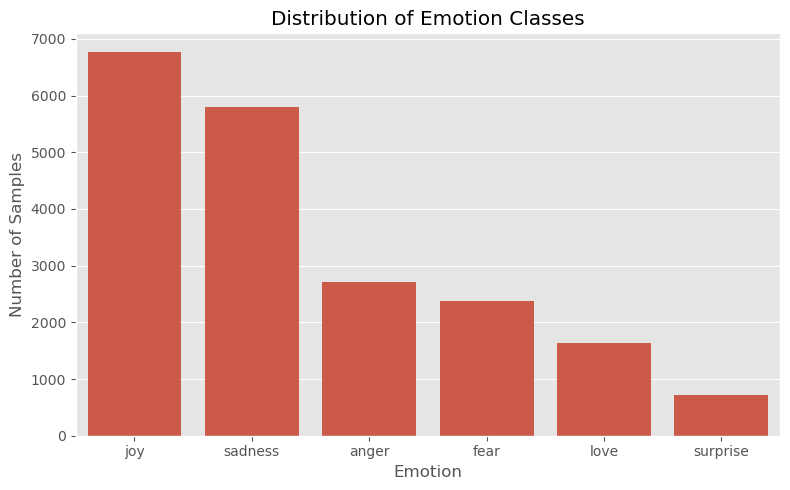

In [16]:
# ==========================================
# Visualize Emotion Distribution
# ==========================================

plt.figure(figsize=(8, 5))

emotion_order = df["emotion"].value_counts().index

sns.countplot(data=df, x="emotion", order=emotion_order)

plt.title("Distribution of Emotion Classes")
plt.xlabel("Emotion")
plt.ylabel("Number of Samples")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Observation

- The dataset contains six emotion categories.
- **Joy** is the most frequently occurring emotion, followed by **Sadness**.
- **Surprise** is the least represented emotion with only 719 samples.
- The dataset is moderately imbalanced, as the majority class (Joy) has substantially more samples than the minority class (Surprise).
- During model evaluation, metrics such as Precision, Recall, and F1-score should be considered in addition to Accuracy to assess performance across all emotion classes.

# 5. Exploratory Data Analysis (EDA)

## 5.1 Sentence Length Analysis

The length of a sentence is an important characteristic in Natural Language Processing.

In this step, we calculate the number of words present in each sentence and create a new feature called **text_length**.

This feature will help us understand the distribution of sentence lengths and identify any unusually short or long text samples.

In [17]:
# ==========================================
# Create Sentence Length Feature
# ==========================================

# Create a new feature representing the number of words in each sentence
df["text_length"] = df["text"].apply(lambda x: len(x.split()))

print("Sentence length feature created successfully.\n")

display(df[["text", "text_length"]].head())

Sentence length feature created successfully.



,text,text_length
0,i didnt feel humiliated,4
1,i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake,21
2,im grabbing a minute to post i feel greedy wrong,10
3,i am ever feeling nostalgic about the fireplace i will know that it is still on the property,18
4,i am feeling grouchy,4


## 5.2 Statistical Summary of Sentence Length

After creating the `text_length` feature, we summarize its distribution using descriptive statistics.

This helps us understand the typical sentence length and identify any unusually short or long text samples that may require further investigation.

In [18]:
# ==========================================
# Statistical Summary of Sentence Length
# ==========================================

print("Statistical Summary of Sentence Length:\n")

display(df["text_length"].describe())

Statistical Summary of Sentence Length:



count    20000.000000
mean        19.135050
std         10.972016
min          2.000000
25%         11.000000
50%         17.000000
75%         25.000000
max         66.000000
Name: text_length, dtype: float64

### Observation

- The dataset contains **20,000** text samples.
- The average sentence length is approximately **19 words**.
- The median sentence length is **17 words**, indicating that most sentences are relatively short.
- Sentence lengths range from **2 words** to **66 words**.
- The average is slightly higher than the median, suggesting a mild right-skew caused by a few longer sentences.
- Overall, the sentence lengths appear reasonable for an emotion classification dataset.

## 5.3 Visualize Sentence Length Distribution

A histogram helps visualize how sentence lengths are distributed across the dataset.

This allows us to identify common sentence lengths, detect skewness, and observe whether any unusually long or short sentences exist.

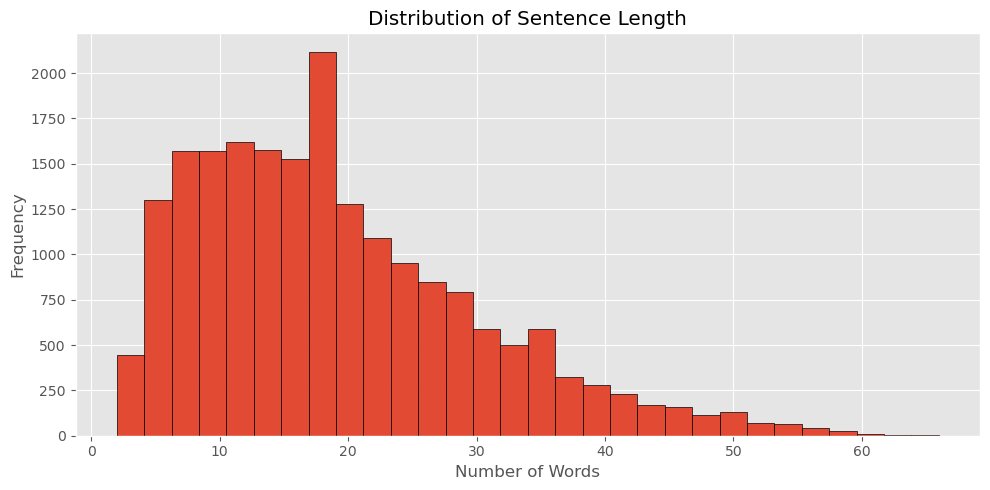

In [19]:
# ==========================================
# Visualize Sentence Length Distribution
# ==========================================

plt.figure(figsize=(10, 5))

plt.hist(df["text_length"], bins=30, edgecolor="black")

plt.title("Distribution of Sentence Length")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

### Observation

- Most sentences contain between **10 and 25 words**.
- The sentence length distribution is **slightly right-skewed**, with fewer long sentences.
- The longest sentence contains **66 words**, indicating that there are no extremely long text samples.
- Overall, the dataset consists of short to medium-length sentences, making it well suited for traditional machine learning techniques such as Bag of Words and TF-IDF.

# 6. Data Cleaning & Text Preprocessing

## 6.1 Inspect Random Text Samples

Before performing any text preprocessing, it is important to inspect a few randomly selected text samples.

This helps identify common text quality issues such as:

- HTML tags
- URLs
- Numbers
- Punctuation
- Special characters
- Extra whitespace
- Other forms of textual noise

The observations from this step will guide the preprocessing strategy.

In [20]:
# ==========================================
# Inspect Random Text Samples
# ==========================================

print("Random Text Samples:\n")

for i, text in enumerate(df["text"].sample(10, random_state=SEED), start=1):
    print(f"{i}. {text}\n")

Random Text Samples:

1. i noticed several months ago that i d start feeling resentful as i walked toward a pedestrian crossing with the intention of course of crossing the road

2. i love lots of different kinds of sports and love hanging out with my friends in my free time i also have an unhealthy up session with greys anatomy im feeling ecstatic about being in ty

3. i feel even if he killed himself it was because he was agonized to that extent

4. i feel numb the way a wound does before it really starts to hurt

5. i feel very happy to have inspired is my little sis love of reading and writing

6. i began to feel unimportant useless insecure and i was disconnected from everything that i used to know

7. being subject to unfair treatment in a working group

8. ive been feeling restless inside and i dont understand why

9. i cant feel anything like they said why does everything always hurt so bad

10. i was feeling wednesday night so i wasn t thrilled to be in training again ha



## 6.2 Create Working Copies of the Text

To preserve the original dataset, we create separate columns for each stage of text preprocessing.

The original **text** column is kept unchanged throughout the project.

Additional columns are created for:

- Cleaned text
- Stemmed text
- Lemmatized text

This approach improves reproducibility and makes it easier to compare different preprocessing techniques.

In [21]:
# ==========================================
# Create Working Copies of Text
# ==========================================

# Preserve the original text
df["text_clean"] = df["text"]

# Placeholder columns for later preprocessing
df["text_stemmed"] = df["text"]

df["text_lemmatized"] = df["text"]

print("Working text columns created successfully.\n")

display(df[["text", "text_clean", "text_stemmed", "text_lemmatized"]].head())

Working text columns created successfully.



,text,text_clean,text_stemmed,text_lemmatized
0,i didnt feel humiliated,i didnt feel humiliated,i didnt feel humiliated,i didnt feel humiliated
1,i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake,i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake,i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake,i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake
2,im grabbing a minute to post i feel greedy wrong,im grabbing a minute to post i feel greedy wrong,im grabbing a minute to post i feel greedy wrong,im grabbing a minute to post i feel greedy wrong
3,i am ever feeling nostalgic about the fireplace i will know that it is still on the property,i am ever feeling nostalgic about the fireplace i will know that it is still on the property,i am ever feeling nostalgic about the fireplace i will know that it is still on the property,i am ever feeling nostalgic about the fireplace i will know that it is still on the property
4,i am feeling grouchy,i am feeling grouchy,i am feeling grouchy,i am feeling grouchy


## 6.3 Import NLP Preprocessing Libraries

Natural Language Processing requires several specialized libraries for text cleaning and normalization.

In this step, we import the libraries required for:

- Regular expression-based text cleaning
- Stopword removal
- Stemming
- Lemmatization

We also download the required NLTK resources to ensure the notebook runs successfully on any system.

In [22]:
# ==========================================
# Import NLP Preprocessing Libraries
# ==========================================

import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer

# Download required NLTK resources
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

# Initialize NLP objects
stop_words = set(stopwords.words("english"))
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

print("NLP preprocessing libraries loaded successfully.")

NLP preprocessing libraries loaded successfully.


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\nakul\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\nakul\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\nakul\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


## 6.4 Create HTML Removal Function

HTML tags may appear in text collected from websites, blogs, or online forums.

Although this dataset contains very little HTML content, creating a dedicated function to remove HTML tags makes the preprocessing pipeline more robust and reusable.

This function removes any HTML tags enclosed within angle brackets (`< >`).

In [23]:
# ==========================================
# HTML Tag Removal Function
# ==========================================

def remove_html(text):
    """
    Remove HTML tags from a text string.

    Parameters:
        text (str): Input text.

    Returns:
        str: Text with HTML tags removed.
    """
    return re.sub(r"<.*?>", "", text)
    

print("HTML removal function created successfully.")

HTML removal function created successfully.


## 6.5 Create URL Removal Function

Text collected from websites or online platforms may contain URLs.

Since URLs generally do not contribute meaningful information for emotion classification, they are removed during preprocessing.

In this step, we create a reusable function to remove web links from text.

In [24]:
# ==========================================
# URL Removal Function
# ==========================================

def remove_urls(text):
    """
    Remove URLs from a text string.

    Parameters:
        text (str): Input text.

    Returns:
        str: Text with URLs removed.
    """
    return re.sub(r"http\S+|www\S+|https\S+", "", text)


print("URL removal function created successfully.")

URL removal function created successfully.


## 6.6 Create Punctuation Removal Function

Punctuation marks generally do not contribute meaningful information for traditional text classification models such as Bag of Words and TF-IDF.

In this step, we create a reusable function to remove punctuation and other non-alphanumeric characters while preserving letters, numbers, and whitespace.

In [25]:
# ==========================================
# Punctuation Removal Function
# ==========================================

def remove_punctuation(text):
    """
    Remove punctuation and special characters from a text string.

    Parameters:
        text (str): Input text.

    Returns:
        str: Text with punctuation removed.
    """
    return re.sub(r"[^\w\s]", "", text)


print("Punctuation removal function created successfully.")

Punctuation removal function created successfully.


## 6.7 Test the Punctuation Removal Function

Before applying the function to the entire dataset, it is good practice to test it on a few sample sentences.

This helps verify that punctuation is removed correctly without affecting the remaining text.

In [26]:
# ==========================================
# Test Punctuation Removal Function
# ==========================================

sample_text = "Wow! I'm feeling amazing, today!!!"

print("Original Text:")
print(sample_text)

print("\nAfter Removing Punctuation:")
print(remove_punctuation(sample_text))

Original Text:
Wow! I'm feeling amazing, today!!!

After Removing Punctuation:
Wow Im feeling amazing today


## 6.8 Check for Numeric Values

Before creating a function to remove numbers, it is important to verify whether numeric values are present in the dataset.

This helps avoid unnecessary preprocessing steps and ensures that every transformation is supported by evidence from the data.

In [27]:
# ==========================================
# Check for Numeric Values
# ==========================================

contains_numbers = df["text"].str.contains(r"\d", regex=True)

print("Number of text samples containing digits:", contains_numbers.sum())

if contains_numbers.sum() > 0:
    print("\nExamples containing numbers:\n")
    display(df.loc[contains_numbers, ["text"]].head(10))

Number of text samples containing digits: 0


## 6.9 Create Extra Whitespace Removal Function

Text preprocessing operations such as removing URLs, HTML tags, or punctuation can introduce unnecessary whitespace.

In this step, we create a reusable function that normalizes whitespace by:

- Replacing multiple spaces with a single space.
- Removing leading and trailing spaces.

This improves text consistency before feature engineering.

In [28]:
# ==========================================
# Extra Whitespace Removal Function
# ==========================================

def remove_extra_spaces(text):
    """
    Normalize whitespace in a text string.

    Parameters:
        text (str): Input text.

    Returns:
        str: Text with normalized whitespace.
    """
    return re.sub(r"\s+", " ", text).strip()

print("Extra whitespace removal function created successfully.")

Extra whitespace removal function created successfully.


## 6.10 Create Stopword Removal Function

Stopwords are commonly occurring words that usually contribute little to text classification using traditional machine learning techniques.

In this step, we create a reusable function that removes English stopwords while preserving meaningful words related to emotion.

This preprocessing step helps reduce noise and decreases the size of the vocabulary for feature engineering methods such as Bag of Words and TF-IDF.

In [29]:
# ==========================================
# Stopword Removal Function
# ==========================================

def remove_stopwords(text):
    """
    Remove English stopwords from a text string.

    Parameters:
        text (str): Input text.

    Returns:
        str: Text after stopword removal.
    """
    words = text.split()

    filtered_words = [
        word for word in words
        if word not in stop_words
    ]

    return " ".join(filtered_words)


print("Stopword removal function created successfully.")

Stopword removal function created successfully.


## 6.11 Test the Stopword Removal Function

Before applying stopword removal to the entire dataset, we test the function on a sample sentence.

This allows us to verify that common English stopwords are removed while important words related to the sentence meaning are retained.

In [30]:
# ==========================================
# Test Stopword Removal Function
# ==========================================

sample_text = "i am feeling very happy today"

print("Original Text:")
print(sample_text)

print("\nAfter Stopword Removal:")
print(remove_stopwords(sample_text))

Original Text:
i am feeling very happy today

After Stopword Removal:
feeling happy today


### Observation

- The stopword removal function successfully removed common English stopwords such as **"i"**, **"am"**, and **"very"**.
- Important words conveying the emotional context, such as **"feeling"**, **"happy"**, and **"today"**, were preserved.
- This confirms that the function behaves as expected and is suitable for traditional machine learning models using Bag of Words and TF-IDF features.

## 6.12 Create Stemming Function

Stemming reduces words to their root form by removing prefixes or suffixes using predefined linguistic rules.

This process helps reduce the vocabulary size by treating different forms of a word as the same feature.

In this project, the Porter Stemmer from the NLTK library is used.

In [31]:
# ==========================================
# Stemming Function
# ==========================================

def apply_stemming(text):
    """
    Apply Porter Stemming to a text string.

    Parameters:
        text (str): Input text.

    Returns:
        str: Stemmed text.
    """
    words = text.split()

    stemmed_words = [
        stemmer.stem(word)
        for word in words
    ]

    return " ".join(stemmed_words)


print("Stemming function created successfully.")

Stemming function created successfully.


## 6.13 Test the Stemming Function

Before applying stemming to the dataset, we test it on a sample sentence.

This helps us understand how the Porter Stemmer transforms different words into their root forms and highlights the difference between stemming and lemmatization.

In [32]:
# ==========================================
# Test Stemming Function
# ==========================================

sample_text = "i am feeling very happy today"

print("Original Text:")
print(sample_text)

print("\nAfter Stemming:")
print(apply_stemming(sample_text))

Original Text:
i am feeling very happy today

After Stemming:
i am feel veri happi today


### Observation

- The stemming function successfully reduced words to their root forms.
- Words such as **"feeling"** were converted to **"feel"**, reducing vocabulary size.
- Some words, such as **"very"** and **"happy"**, became **"veri"** and **"happi"**, demonstrating that stemming is rule-based and does not always produce valid English words.
- Stemming is computationally efficient and is commonly used in traditional machine learning pipelines, although it may sacrifice linguistic accuracy.

## 6.14 Create Lemmatization Function

Lemmatization reduces words to their dictionary base form (lemma) using linguistic knowledge.

Unlike stemming, lemmatization aims to preserve valid English words, making the processed text easier to interpret while reducing vocabulary size.

In this project, the WordNet Lemmatizer from the NLTK library is used.

In [33]:
# ==========================================
# Lemmatization Function
# ==========================================

def apply_lemmatization(text):
    """
    Apply WordNet Lemmatization to a text string.

    Parameters:
        text (str): Input text.

    Returns:
        str: Lemmatized text.
    """
    words = text.split()

    lemmatized_words = [
        lemmatizer.lemmatize(word)
        for word in words
    ]

    return " ".join(lemmatized_words)


print("Lemmatization function created successfully.")

Lemmatization function created successfully.


## 6.15 Test the Lemmatization Function

Before applying lemmatization to the complete dataset, we test the function using a sample sentence.

This helps us observe how the WordNet Lemmatizer transforms words and compare its behavior with stemming.

In [34]:
# ==========================================
# Test Lemmatization Function
# ==========================================

sample_text = "i am feeling very happy today"

print("Original Text:")
print(sample_text)

print("\nAfter Lemmatization:")
print(apply_lemmatization(sample_text))

Original Text:
i am feeling very happy today

After Lemmatization:
i am feeling very happy today


## 6.16 Create POS-Aware Lemmatization Function

Basic WordNet lemmatization assumes that words are nouns by default.

To improve the quality of lemmatization, we use Part-of-Speech (POS) information to identify whether a word is a noun, verb, adjective, or adverb before applying lemmatization.

This allows words such as "feeling" to be reduced to their appropriate base form, such as "feel".

In [35]:
# ==========================================
# POS-Aware Lemmatization Function
# ==========================================

from nltk import pos_tag
from nltk.corpus import wordnet


def get_wordnet_pos(word):
    """
    Convert NLTK POS tags to WordNet POS tags.

    Parameters:
        word (str): Input word.

    Returns:
        str: WordNet-compatible POS tag.
    """

    tag = pos_tag([word])[0][1][0].upper()

    pos_mapping = {
        "J": wordnet.ADJ,
        "N": wordnet.NOUN,
        "V": wordnet.VERB,
        "R": wordnet.ADV
    }

    return pos_mapping.get(tag, wordnet.NOUN)


def apply_pos_lemmatization(text):
    """
    Apply POS-aware WordNet lemmatization.

    Parameters:
        text (str): Input text.

    Returns:
        str: POS-aware lemmatized text.
    """

    words = text.split()

    pos_tags = pos_tag(words)

    lemmatized_words = [
        lemmatizer.lemmatize(
            word,
            get_wordnet_pos(word)
        )
        for word, _ in pos_tags
    ]

    return " ".join(lemmatized_words)


print("POS-aware lemmatization function created successfully.")

POS-aware lemmatization function created successfully.


## 6.17 Test POS-Aware Lemmatization

The POS-aware lemmatization function uses grammatical information to determine the appropriate base form of each word.

We test it on the same sample sentence used for our previous preprocessing experiments so that the results can be compared consistently.

In [36]:
# ==========================================
# Test POS-Aware Lemmatization
# ==========================================

sample_text = "i am feeling very happy today"

print("Original Text:")
print(sample_text)

print("\nAfter POS-Aware Lemmatization:")
print(apply_pos_lemmatization(sample_text))

Original Text:
i am feeling very happy today

After POS-Aware Lemmatization:
i be feel very happy today


### 6.17A Download Required POS Tagger

POS-aware lemmatization requires an NLTK Part-of-Speech tagger.

The required English POS tagger resource is downloaded in this step so that NLTK can identify whether words are nouns, verbs, adjectives, or adverbs.

In [37]:
# ==========================================
# Download Required NLTK POS Tagger
# ==========================================

nltk.download("averaged_perceptron_tagger_eng")

print("Required NLTK POS tagger downloaded successfully.")

Required NLTK POS tagger downloaded successfully.


[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\nakul\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


## 6.18 Test POS-Aware Lemmatization

The required POS tagger is now available.

We re-run the same test sentence to verify that POS-aware lemmatization correctly identifies the grammatical role of each word and produces appropriate base forms.

In [38]:
# ==========================================
# Re-test POS-Aware Lemmatization
# ==========================================

sample_text = "i am feeling very happy today"

print("Original Text:")
print(sample_text)

print("\nAfter POS-Aware Lemmatization:")
print(apply_pos_lemmatization(sample_text))

Original Text:
i am feeling very happy today

After POS-Aware Lemmatization:
i be feel very happy today


## 6.19 Create Basic Text Cleaning Pipeline

The basic cleaning pipeline combines the validated text-cleaning operations into a single reusable function.

The following transformations are performed:

1. Remove HTML tags
2. Remove URLs
3. Remove punctuation and special characters
4. Normalize extra whitespace

Stopword removal, stemming, and lemmatization are kept as separate stages so that different preprocessing strategies can be compared later.

In [39]:
# ==========================================
# Basic Text Cleaning Pipeline
# ==========================================

def clean_text(text):
    """
    Apply basic text cleaning operations.

    Processing steps:
        1. Remove HTML tags
        2. Remove URLs
        3. Remove punctuation
        4. Normalize whitespace

    Parameters:
        text (str): Input text.

    Returns:
        str: Cleaned text.
    """

    text = remove_html(text)
    text = remove_urls(text)
    text = remove_punctuation(text)
    text = remove_extra_spaces(text)

    return text

print("Basic text cleaning pipeline created successfully.")

Basic text cleaning pipeline created successfully.


## 6.20 Test the Basic Text Cleaning Pipeline

Before applying the cleaning pipeline to the complete dataset, we test it on representative examples from the dataset.

This allows us to verify that HTML fragments, URLs, punctuation, and unnecessary whitespace are handled correctly without unexpectedly changing the text.

In [40]:
# ==========================================
# Test Basic Text Cleaning Pipeline
# ==========================================

sample_indices = [0, 1, 4975, 13846]

for index in sample_indices:
    original_text = df.loc[index, "text"]
    cleaned_text = clean_text(original_text)

    print("=" * 70)
    print(f"Record Index : {index}")
    print(f"Emotion      : {df.loc[index, 'emotion']}")
    print("\nOriginal Text:")
    print(original_text)
    print("\nCleaned Text:")
    print(cleaned_text)

print("=" * 70)

Record Index : 0
Emotion      : sadness

Original Text:
i didnt feel humiliated

Cleaned Text:
i didnt feel humiliated
Record Index : 1
Emotion      : sadness

Original Text:
i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake

Cleaned Text:
i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake
Record Index : 4975
Emotion      : joy

Original Text:
i feel more adventurous willing to take risks img src http cdn

Cleaned Text:
i feel more adventurous willing to take risks img src http cdn
Record Index : 13846
Emotion      : joy

Original Text:
i feel more adventurous willing to take risks img src http cdn

Cleaned Text:
i feel more adventurous willing to take risks img src http cdn


## 6.21 Apply Basic Text Cleaning to the Dataset

The validated basic text cleaning pipeline is now applied to the complete dataset.

The original `text` column is preserved, while the cleaned text is stored in the `text_clean` column.

The following transformations are applied:

- HTML tag removal
- URL removal
- Punctuation removal
- Whitespace normalization

In [41]:
# ==========================================
# Apply Basic Text Cleaning
# ==========================================

df["text_clean"] = df["text"].apply(clean_text)

print("Basic text cleaning applied successfully.")
print(f"Number of records processed : {len(df):,}")

Basic text cleaning applied successfully.
Number of records processed : 20,000


## 6.22 Validate Cleaned Text

After applying the basic cleaning pipeline, we perform a quality check to ensure that:

- The dataset still contains all 20,000 records.
- No text records became empty after cleaning.
- The original and cleaned text can be compared for verification.

In [42]:
# ==========================================
# Validate Cleaned Text
# ==========================================

empty_clean_text = df["text_clean"].str.strip().eq("").sum()

print("=" * 60)
print("Cleaned Text Validation")
print("=" * 60)

print(f"Total Records              : {len(df):,}")
print(f"Empty Cleaned Text Records : {empty_clean_text:,}")

print("\nSample Before vs After Cleaning:")
display(
    df[["text", "text_clean"]]
    .sample(5, random_state=42)
    .reset_index(drop=True)
)

Cleaned Text Validation
Total Records              : 20,000
Empty Cleaned Text Records : 0

Sample Before vs After Cleaning:


,text,text_clean
0,i noticed several months ago that i d start feeling resentful as i walked toward a pedestrian crossing with the intention of course of crossing the road,i noticed several months ago that i d start feeling resentful as i walked toward a pedestrian crossing with the intention of course of crossing the road
1,i love lots of different kinds of sports and love hanging out with my friends in my free time i also have an unhealthy up session with greys anatomy im feeling ecstatic about being in ty,i love lots of different kinds of sports and love hanging out with my friends in my free time i also have an unhealthy up session with greys anatomy im feeling ecstatic about being in ty
2,i feel even if he killed himself it was because he was agonized to that extent,i feel even if he killed himself it was because he was agonized to that extent
3,i feel numb the way a wound does before it really starts to hurt,i feel numb the way a wound does before it really starts to hurt
4,i feel very happy to have inspired is my little sis love of reading and writing,i feel very happy to have inspired is my little sis love of reading and writing


## 6.23 Create Stopword-Removal Pipeline

The cleaned text is further processed by removing common English stopwords.

The resulting text will be used as the input for two separate normalization approaches:

1. Stemming
2. POS-aware Lemmatization

Keeping these stages separate allows us to compare the effect of stemming and lemmatization during feature engineering and model evaluation.

In [43]:
# ==========================================
# Stopword-Removal Pipeline
# ==========================================

def preprocess_without_stopwords(text):
    """
    Apply stopword removal to cleaned text.

    Parameters:
        text (str): Cleaned input text.

    Returns:
        str: Text after stopword removal.
    """
    
    return remove_stopwords(text)

print("Stopword-removal pipeline created successfully.")

Stopword-removal pipeline created successfully.


## 6.24 Apply Stopword Removal

The stopword-removal pipeline is applied to the cleaned text of all records.

The resulting text is stored in a separate column so that the original text and basic cleaned text remain available for comparison.

In [44]:
# ==========================================
# Apply Stopword Removal
# ==========================================

df["text_no_stopwords"] = df["text_clean"].apply(
    preprocess_without_stopwords
)

print("Stopword removal applied successfully.")
print(f"Number of records processed : {len(df):,}")

Stopword removal applied successfully.
Number of records processed : 20,000


## 6.25 Validate Stopword Removal

After removing stopwords, we validate the resulting text to ensure that:

- The number of records remains unchanged.
- No records became empty.
- The transformation is removing common stopwords as expected.
- The original cleaned text remains available for comparison.

In [45]:
# ==========================================
# Validate Stopword Removal
# ==========================================

empty_no_stopwords = df["text_no_stopwords"].str.strip().eq("").sum()

print("=" * 60)
print("Stopword Removal Validation")
print("=" * 60)

print(f"Total Records                  : {len(df):,}")
print(f"Empty Text After Stopword Removal : {empty_no_stopwords:,}")

print("\nSample Before vs After Stopword Removal:")

display(
    df[["text_clean", "text_no_stopwords"]]
    .sample(5, random_state=42)
    .reset_index(drop=True)
)

Stopword Removal Validation
Total Records                  : 20,000
Empty Text After Stopword Removal : 0

Sample Before vs After Stopword Removal:


,text_clean,text_no_stopwords
0,i noticed several months ago that i d start feeling resentful as i walked toward a pedestrian crossing with the intention of course of crossing the road,noticed several months ago start feeling resentful walked toward pedestrian crossing intention course crossing road
1,i love lots of different kinds of sports and love hanging out with my friends in my free time i also have an unhealthy up session with greys anatomy im feeling ecstatic about being in ty,love lots different kinds sports love hanging friends free time also unhealthy session greys anatomy im feeling ecstatic ty
2,i feel even if he killed himself it was because he was agonized to that extent,feel even killed agonized extent
3,i feel numb the way a wound does before it really starts to hurt,feel numb way wound really starts hurt
4,i feel very happy to have inspired is my little sis love of reading and writing,feel happy inspired little sis love reading writing


## 6.26 Create Stemming Pipeline

The stopword-free text is further processed using Porter Stemming.

Stemming reduces words to their root-like forms by removing common prefixes and suffixes.

This produces a stemmed representation that can be compared with the lemmatized representation during feature engineering and model evaluation.

In [46]:
# ==========================================
# Stemming Pipeline
# ==========================================

def preprocess_stemming(text):
    """
    Apply Porter Stemming to stopword-free text.

    Parameters:
        text (str): Text after stopword removal.

    Returns:
        str: Stemmed text.
    """
    
    return apply_stemming(text)

print("Stemming pipeline created successfully.")

Stemming pipeline created successfully.


## 6.27 Apply Stemming

The validated stemming pipeline is applied to the stopword-free text for all records.

The resulting stemmed text is stored in a new `text_stemmed` column while the previous preprocessing stages are preserved for comparison.

In [47]:
# ==========================================
# Apply Stemming
# ==========================================

df["text_stemmed"] = df["text_no_stopwords"].apply(
    preprocess_stemming
)

print("Stemming applied successfully.")
print(f"Number of records processed : {len(df):,}")

Stemming applied successfully.
Number of records processed : 20,000


## 6.28 Validate Stemming

After applying stemming to the complete dataset, we inspect representative examples to verify how the words have been transformed.

This validation helps us confirm that the stemming process is working as expected before creating the alternative lemmatization pipeline.

In [48]:
# ==========================================
# Validate Stemming
# ==========================================

print("=" * 70)
print("Stemming Validation")
print("=" * 70)

display(
    df[["text_no_stopwords", "text_stemmed"]]
    .sample(5, random_state=42)
    .reset_index(drop=True)
)

Stemming Validation


,text_no_stopwords,text_stemmed
0,noticed several months ago start feeling resentful walked toward pedestrian crossing intention course crossing road,notic sever month ago start feel resent walk toward pedestrian cross intent cours cross road
1,love lots different kinds sports love hanging friends free time also unhealthy session greys anatomy im feeling ecstatic ty,love lot differ kind sport love hang friend free time also unhealthi session grey anatomi im feel ecstat ty
2,feel even killed agonized extent,feel even kill agon extent
3,feel numb way wound really starts hurt,feel numb way wound realli start hurt
4,feel happy inspired little sis love reading writing,feel happi inspir littl si love read write


## 6.29 Create POS-Aware Lemmatization Pipeline

The stopword-free text is processed using POS-aware WordNet Lemmatization.

Part-of-Speech information is used to identify whether each word is a noun, verb, adjective, or adverb before determining its lemma.

This approach generally produces more linguistically meaningful word forms than stemming.

In [49]:
# ==========================================
# POS-Aware Lemmatization Pipeline
# ==========================================

def preprocess_lemmatization(text):
    """
    Apply POS-aware WordNet lemmatization
    to stopword-free text.

    Parameters:
        text (str): Text after stopword removal.

    Returns:
        str: POS-aware lemmatized text.
    """
    
    return apply_pos_lemmatization(text)

print("POS-aware lemmatization pipeline created successfully.")

POS-aware lemmatization pipeline created successfully.


## 6.30 Apply POS-Aware Lemmatization

The validated POS-aware lemmatization pipeline is applied to the stopword-free text for all records.

The resulting text is stored in the `text_lemmatized` column while preserving all previous text representations for comparison.

In [50]:
# ==========================================
# Apply POS-Aware Lemmatization
# ==========================================

df["text_lemmatized"] = df["text_no_stopwords"].apply(
    preprocess_lemmatization
)

print("POS-aware lemmatization applied successfully.")
print(f"Number of records processed : {len(df):,}")

POS-aware lemmatization applied successfully.
Number of records processed : 20,000


## 6.31 Compare Stemming and Lemmatization

Both stemming and POS-aware lemmatization have been applied to the complete dataset.

In this step, we compare the resulting text representations using real examples from the dataset.

This helps us understand the practical difference between the two normalization techniques before proceeding to feature engineering.

In [51]:
# ==========================================
# Compare Stemming vs Lemmatization
# ==========================================

comparison_df = (
    df[
        [
            "text_no_stopwords",
            "text_stemmed",
            "text_lemmatized"
        ]
    ]
    .sample(5, random_state=42)
    .reset_index(drop=True)
)

print("=" * 80)
print("Stemming vs Lemmatization Comparison")
print("=" * 80)

display(comparison_df)

Stemming vs Lemmatization Comparison


,text_no_stopwords,text_stemmed,text_lemmatized
0,noticed several months ago start feeling resentful walked toward pedestrian crossing intention course crossing road,notic sever month ago start feel resent walk toward pedestrian cross intent cours cross road,notice several month ago start feel resentful walk toward pedestrian cross intention course cross road
1,love lots different kinds sports love hanging friends free time also unhealthy session greys anatomy im feeling ecstatic ty,love lot differ kind sport love hang friend free time also unhealthi session grey anatomi im feel ecstat ty,love lot different kind sport love hang friend free time also unhealthy session grey anatomy im feel ecstatic ty
2,feel even killed agonized extent,feel even kill agon extent,feel even kill agonize extent
3,feel numb way wound really starts hurt,feel numb way wound realli start hurt,feel numb way wound really start hurt
4,feel happy inspired little sis love reading writing,feel happi inspir littl si love read write,feel happy inspire little si love reading write


## 7.1 Prepare Train, Validation and Test Data

The dataset already contains predefined training, validation, and test splits.

These splits are preserved throughout the project.

For feature engineering, the vectorizer will be fitted only on the training data and then used to transform the validation and test datasets.

This prevents information from the validation or test sets from influencing the learned vocabulary and helps avoid data leakage.

In [52]:
# ==========================================
# Prepare Train, Validation and Test Data
# ==========================================

train_df = df[df["dataset"] == "Train"].copy()
val_df = df[df["dataset"] == "Validation"].copy()
test_df = df[df["dataset"] == "Test"].copy()

print("=" * 60)
print("Dataset Splits Prepared")
print("=" * 60)

print(f"Training Records   : {len(train_df):,}")
print(f"Validation Records : {len(val_df):,}")
print(f"Test Records       : {len(test_df):,}")

Dataset Splits Prepared
Training Records   : 16,000
Validation Records : 2,000
Test Records       : 2,000


## 7.2 Create Bag of Words (BoW) Vectorizer

Bag of Words represents text as numerical vectors based on the frequency of words appearing in the documents.

In this project, the vectorizer is fitted only on the training data to prevent data leakage.

The validation and test datasets will be transformed using the vocabulary learned from the training dataset.

In [53]:
# ==========================================
# Bag of Words Vectorizer
# ==========================================

from sklearn.feature_extraction.text import CountVectorizer

bow_vectorizer = CountVectorizer(lowercase=False, max_features=20000)

X_train_bow = bow_vectorizer.fit_transform(train_df["text_lemmatized"])
X_val_bow = bow_vectorizer.transform(val_df["text_lemmatized"])
X_test_bow = bow_vectorizer.transform(test_df["text_lemmatized"])

print("=" * 60)
print("Bag of Words Vectorization Completed")
print("=" * 60)

print(f"Training Matrix   : {X_train_bow.shape}")
print(f"Validation Matrix : {X_val_bow.shape}")
print(f"Test Matrix       : {X_test_bow.shape}")

Bag of Words Vectorization Completed
Training Matrix   : (16000, 11844)
Validation Matrix : (2000, 11844)
Test Matrix       : (2000, 11844)


## 7.3 Inspect Bag of Words Vocabulary

The Bag of Words vectorizer learns a vocabulary from the training dataset.

In this step, we inspect the vocabulary size and a sample of the learned terms to understand the features generated from the training text.

In [54]:
# ==========================================
# Inspect Bag of Words Vocabulary
# ==========================================

bow_vocabulary = bow_vectorizer.get_feature_names_out()

print("=" * 60)
print("Bag of Words Vocabulary")
print("=" * 60)

print(f"Total Vocabulary Size : {len(bow_vocabulary):,}")

print("\nFirst 30 Vocabulary Terms:")
print(bow_vocabulary[:30])

Bag of Words Vocabulary
Total Vocabulary Size : 11,844

First 30 Vocabulary Terms:
['aa' 'aaaaaaand' 'aaaaand' 'aaaand' 'aac' 'aahhh' 'aaron' 'ab' 'abandon'
 'abandonment' 'abate' 'abbigail' 'abc' 'abdomen' 'abdominal' 'abduct'
 'abelard' 'abhorrent' 'abide' 'ability' 'abit' 'able' 'ableness'
 'abnormally' 'aboard' 'abominable' 'abortion' 'abou' 'abound' 'abraham']


## 7.4 Inspect Bag of Words Numerical Representation

Bag of Words converts each document into a numerical vector based on the frequency of vocabulary terms.

The resulting matrix is sparse because most documents contain only a small fraction of the complete vocabulary.

A small portion of the matrix is displayed to understand how the text is represented numerically.

In [55]:
# ==========================================
# Inspect Bag of Words Matrix
# ==========================================

bow_sample = X_train_bow[:5, :20].toarray()

print("=" * 60)
print("Sample Bag of Words Matrix")
print("=" * 60)

print("Rows displayed    : 5")
print("Features displayed: 20")

print("\nMatrix:")
print(bow_sample)

Sample Bag of Words Matrix
Rows displayed    : 5
Features displayed: 20

Matrix:
[[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]]


## 7.5 Inspect Actual Bag of Words Features

The previous inspection displayed the first 20 vocabulary columns, which happened to contain no words from the selected documents.

In this step, we inspect the actual non-zero features for the first training document.

This provides a clearer understanding of how Bag of Words represents a sentence numerically.

In [56]:
# ==========================================
# Inspect Actual Non-Zero BoW Features
# ==========================================

document_index = 0

document_vector = X_train_bow[document_index]

non_zero_indices = document_vector.nonzero()[1]

bow_features = [(bow_vocabulary[index], document_vector[0, index])
    for index in non_zero_indices]

print("=" * 60)
print("Actual Non-Zero Bag of Words Features")
print("=" * 60)

print(f"Training Document Index : {document_index}")
print(f"Original Text           : {train_df.iloc[document_index]['text']}")
print(f"Lemmatized Text         : {train_df.iloc[document_index]['text_lemmatized']}")

print("\nNon-Zero Features:")

for word, count in bow_features:
    print(f"{word:<20} : {count}")

Actual Non-Zero Bag of Words Features
Training Document Index : 0
Original Text           : i didnt feel humiliated
Lemmatized Text         : didnt feel humiliate

Non-Zero Features:
didnt                : 1
feel                 : 1
humiliate            : 1


## 7.6 Encode Emotion Labels

Machine learning algorithms require the target variable to be represented numerically.

The six emotion categories are therefore encoded into numerical labels using `LabelEncoder`.

The encoder is fitted on the training labels and then applied to the validation and test labels using the same mapping.

In [57]:
# ==========================================
# Encode Emotion Labels
# ==========================================

from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_train = label_encoder.fit_transform(train_df["emotion"])
y_val = label_encoder.transform(val_df["emotion"])
y_test = label_encoder.transform(test_df["emotion"])

print("=" * 60)
print("Emotion Labels Encoded Successfully")
print("=" * 60)

print("Emotion Label Mapping:")

for label, encoded_value in zip(
    label_encoder.classes_,
    range(len(label_encoder.classes_))
):
    print(f"{label:<10} : {encoded_value}")

print("\nTraining Target Shape   :", y_train.shape)
print("Validation Target Shape :", y_val.shape)
print("Test Target Shape       :", y_test.shape)

Emotion Labels Encoded Successfully
Emotion Label Mapping:
anger      : 0
fear       : 1
joy        : 2
love       : 3
sadness    : 4
surprise   : 5

Training Target Shape   : (16000,)
Validation Target Shape : (2000,)
Test Target Shape       : (2000,)


## 7.7 Baseline Logistic Regression with Bag of Words

Logistic Regression is used as the first baseline classifier for emotion classification.

The model is trained using the Bag of Words representation generated from the lemmatized text.

No hyperparameter tuning is performed at this stage. The purpose of this baseline is to establish an initial performance benchmark before experimenting with other algorithms and feature representations.

In [58]:
# ==========================================
# Baseline Logistic Regression + BoW
# ==========================================

from sklearn.linear_model import LogisticRegression

logreg_bow = LogisticRegression(max_iter=1000, random_state=42)

logreg_bow.fit(X_train_bow, y_train)

print("=" * 60)
print("Baseline Logistic Regression Model Trained")
print("=" * 60)

Baseline Logistic Regression Model Trained


## 7.8 Evaluate Baseline Logistic Regression with Bag of Words

The baseline Logistic Regression model is evaluated on the validation dataset.

The evaluation includes:

- Accuracy
- Weighted Precision
- Weighted Recall
- Weighted F1-score
- Macro F1-score
- Detailed classification report

The test dataset is intentionally not used at this stage. It will remain untouched until the final model has been selected.

In [59]:
# ==========================================
# Evaluate Baseline Logistic Regression
# ==========================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# Generate validation predictions
y_val_pred_bow = logreg_bow.predict(X_val_bow)

# Calculate evaluation metrics
accuracy_bow = accuracy_score(y_val, y_val_pred_bow)

precision_bow = precision_score(
    y_val,
    y_val_pred_bow,
    average="weighted",
    zero_division=0
)

recall_bow = recall_score(
    y_val,
    y_val_pred_bow,
    average="weighted",
    zero_division=0
)

f1_weighted_bow = f1_score(
    y_val,
    y_val_pred_bow,
    average="weighted",
    zero_division=0
)

f1_macro_bow = f1_score(
    y_val,
    y_val_pred_bow,
    average="macro",
    zero_division=0
)

print("=" * 70)
print("Baseline Logistic Regression + BoW")
print("Validation Performance")
print("=" * 70)

print(f"Accuracy          : {accuracy_bow:.4f}")
print(f"Precision         : {precision_bow:.4f}")
print(f"Recall            : {recall_bow:.4f}")
print(f"Weighted F1-Score : {f1_weighted_bow:.4f}")
print(f"Macro F1-Score    : {f1_macro_bow:.4f}")

print("\n" + "=" * 70)
print("Classification Report")
print("=" * 70)

print(
    classification_report(
        y_val,
        y_val_pred_bow,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

Baseline Logistic Regression + BoW
Validation Performance
Accuracy          : 0.8850
Precision         : 0.8845
Recall            : 0.8850
Weighted F1-Score : 0.8844
Macro F1-Score    : 0.8530

Classification Report
              precision    recall  f1-score   support

       anger       0.86      0.89      0.87       275
        fear       0.84      0.80      0.82       212
         joy       0.91      0.92      0.91       704
        love       0.84      0.76      0.80       178
     sadness       0.91      0.93      0.92       550
    surprise       0.78      0.81      0.80        81

    accuracy                           0.89      2000
   macro avg       0.86      0.85      0.85      2000
weighted avg       0.88      0.89      0.88      2000



## 7.9 Initialize Model Comparison Table

A centralized model comparison table is created to track the performance of each experiment.

The table will be updated as we evaluate different combinations of:

- Text preprocessing
- Feature engineering techniques
- Machine learning algorithms
- Hyperparameter tuning

The primary metrics will be Accuracy and Macro F1-score, with additional precision, recall, and weighted F1-score tracked for completeness.

In [60]:
# ==========================================
# Initialize Model Comparison Table
# ==========================================

model_results = []

model_results.append({
    "Model": "Logistic Regression",
    "Features": "BoW",
    "Text Representation": "Lemmatized",
    "Accuracy": accuracy_bow,
    "Precision": precision_bow,
    "Recall": recall_bow,
    "Weighted F1": f1_weighted_bow,
    "Macro F1": f1_macro_bow
})

results_df = pd.DataFrame(model_results)

print("=" * 80)
print("Model Comparison Table")
print("=" * 80)

display(
    results_df.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "Weighted F1": "{:.4f}",
        "Macro F1": "{:.4f}"
    })
)

Model Comparison Table


,Model,Features,Text Representation,Accuracy,Precision,Recall,Weighted F1,Macro F1
0,Logistic Regression,BoW,Lemmatized,0.8850,0.8845,0.8850,0.8844,0.8530


## 7.10 Baseline Decision Tree with Bag of Words

A Decision Tree classifier is trained using the same Bag of Words features used by the Logistic Regression baseline.

Keeping the feature representation unchanged allows us to compare the effect of the machine learning algorithm independently.

Hyperparameter tuning will be performed later after establishing baseline results for multiple algorithms.

In [61]:
# ==========================================
# Baseline Decision Tree + BoW
# ==========================================

from sklearn.tree import DecisionTreeClassifier

dt_bow = DecisionTreeClassifier(random_state=42)

dt_bow.fit(X_train_bow, y_train)

print("=" * 60)
print("Baseline Decision Tree Model Trained")
print("=" * 60)

Baseline Decision Tree Model Trained


## 7.11 Evaluate Baseline Decision Tree with Bag of Words

The baseline Decision Tree model is evaluated on the validation dataset.

The same evaluation metrics used for Logistic Regression are calculated:

- Accuracy
- Weighted Precision
- Weighted Recall
- Weighted F1-score
- Macro F1-score
- Classification report

This allows a direct comparison between the two baseline algorithms.

In [62]:
# ==========================================
# Evaluate Baseline Decision Tree
# ==========================================

# Generate validation predictions
y_val_pred_dt_bow = dt_bow.predict(X_val_bow)

# Calculate evaluation metrics
accuracy_dt_bow = accuracy_score(y_val, y_val_pred_dt_bow)

precision_dt_bow = precision_score(
    y_val,
    y_val_pred_dt_bow,
    average="weighted",
    zero_division=0
)

recall_dt_bow = recall_score(
    y_val,
    y_val_pred_dt_bow,
    average="weighted",
    zero_division=0
)

f1_weighted_dt_bow = f1_score(
    y_val,
    y_val_pred_dt_bow,
    average="weighted",
    zero_division=0
)

f1_macro_dt_bow = f1_score(
    y_val,
    y_val_pred_dt_bow,
    average="macro",
    zero_division=0
)

print("=" * 70)
print("Baseline Decision Tree + BoW")
print("Validation Performance")
print("=" * 70)

print(f"Accuracy          : {accuracy_dt_bow:.4f}")
print(f"Precision         : {precision_dt_bow:.4f}")
print(f"Recall            : {recall_dt_bow:.4f}")
print(f"Weighted F1-Score : {f1_weighted_dt_bow:.4f}")
print(f"Macro F1-Score    : {f1_macro_dt_bow:.4f}")

print("\n" + "=" * 70)
print("Classification Report")
print("=" * 70)

print(
    classification_report(
        y_val,
        y_val_pred_dt_bow,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

Baseline Decision Tree + BoW
Validation Performance
Accuracy          : 0.8425
Precision         : 0.8477
Recall            : 0.8425
Weighted F1-Score : 0.8440
Macro F1-Score    : 0.8123

Classification Report
              precision    recall  f1-score   support

       anger       0.80      0.88      0.84       275
        fear       0.78      0.85      0.82       212
         joy       0.90      0.85      0.87       704
        love       0.66      0.73      0.69       178
     sadness       0.91      0.86      0.88       550
    surprise       0.75      0.79      0.77        81

    accuracy                           0.84      2000
   macro avg       0.80      0.83      0.81      2000
weighted avg       0.85      0.84      0.84      2000



## 7.12 Add Decision Tree to Model Comparison

The Decision Tree validation results are added to the central model comparison table.

This allows us to track the performance of all experiments consistently as we progress through different algorithms and feature-engineering techniques.

In [63]:
# ==========================================
# Add Decision Tree Results
# ==========================================

model_results.append({
    "Model": "Decision Tree",
    "Features": "BoW",
    "Text Representation": "Lemmatized",
    "Accuracy": accuracy_dt_bow,
    "Precision": precision_dt_bow,
    "Recall": recall_dt_bow,
    "Weighted F1": f1_weighted_dt_bow,
    "Macro F1": f1_macro_dt_bow
})

results_df = pd.DataFrame(model_results)

print("=" * 80)
print("Updated Model Comparison Table")
print("=" * 80)

display(
    results_df.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "Weighted F1": "{:.4f}",
        "Macro F1": "{:.4f}"
    })
)

Updated Model Comparison Table


,Model,Features,Text Representation,Accuracy,Precision,Recall,Weighted F1,Macro F1
0,Logistic Regression,BoW,Lemmatized,0.8850,0.8845,0.8850,0.8844,0.8530
1,Decision Tree,BoW,Lemmatized,0.8425,0.8477,0.8425,0.8440,0.8123


## 7.13 Baseline Random Forest with Bag of Words

A Random Forest classifier is trained using the same Bag of Words features and lemmatized text used in the previous experiments.

Random Forest combines multiple decision trees and can provide more robust predictions than a single Decision Tree.

At this stage, default model settings are used as a baseline. Hyperparameter tuning will be performed later.

In [64]:
# ==========================================
# Baseline Random Forest + BoW
# ==========================================

from sklearn.ensemble import RandomForestClassifier

rf_bow = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)

rf_bow.fit(X_train_bow, y_train)

print("=" * 60)
print("Baseline Random Forest Model Trained")
print("=" * 60)

Baseline Random Forest Model Trained


## 7.14 Evaluate Baseline Random Forest with Bag of Words

The baseline Random Forest model is evaluated on the validation dataset using the same metrics used for the previous models.

This provides a direct comparison with Logistic Regression and Decision Tree.

In [65]:
# ==========================================
# Evaluate Baseline Random Forest
# ==========================================

# Generate validation predictions
y_val_pred_rf_bow = rf_bow.predict(X_val_bow)

# Calculate evaluation metrics
accuracy_rf_bow = accuracy_score(y_val, y_val_pred_rf_bow)

precision_rf_bow = precision_score(
    y_val,
    y_val_pred_rf_bow,
    average="weighted",
    zero_division=0
)

recall_rf_bow = recall_score(
    y_val,
    y_val_pred_rf_bow,
    average="weighted",
    zero_division=0
)

f1_weighted_rf_bow = f1_score(
    y_val,
    y_val_pred_rf_bow,
    average="weighted",
    zero_division=0
)

f1_macro_rf_bow = f1_score(
    y_val,
    y_val_pred_rf_bow,
    average="macro",
    zero_division=0
)

print("=" * 70)
print("Baseline Random Forest + BoW")
print("Validation Performance")
print("=" * 70)

print(f"Accuracy          : {accuracy_rf_bow:.4f}")
print(f"Precision         : {precision_rf_bow:.4f}")
print(f"Recall            : {recall_rf_bow:.4f}")
print(f"Weighted F1-Score : {f1_weighted_rf_bow:.4f}")
print(f"Macro F1-Score    : {f1_macro_rf_bow:.4f}")

print("\n" + "=" * 70)
print("Classification Report")
print("=" * 70)

print(
    classification_report(
        y_val,
        y_val_pred_rf_bow,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

Baseline Random Forest + BoW
Validation Performance
Accuracy          : 0.8785
Precision         : 0.8805
Recall            : 0.8785
Weighted F1-Score : 0.8789
Macro F1-Score    : 0.8480

Classification Report
              precision    recall  f1-score   support

       anger       0.83      0.92      0.87       275
        fear       0.80      0.83      0.81       212
         joy       0.93      0.90      0.91       704
        love       0.82      0.76      0.79       178
     sadness       0.92      0.90      0.91       550
    surprise       0.75      0.85      0.80        81

    accuracy                           0.88      2000
   macro avg       0.84      0.86      0.85      2000
weighted avg       0.88      0.88      0.88      2000



## 7.15 Add Random Forest to Model Comparison

The Random Forest validation results are added to the centralized model comparison table.

This completes our initial comparison of three traditional machine learning algorithms using Bag of Words features.

In [66]:
# ==========================================
# Add Random Forest Results
# ==========================================

model_results.append({
    "Model": "Random Forest",
    "Features": "BoW",
    "Text Representation": "Lemmatized",
    "Accuracy": accuracy_rf_bow,
    "Precision": precision_rf_bow,
    "Recall": recall_rf_bow,
    "Weighted F1": f1_weighted_rf_bow,
    "Macro F1": f1_macro_rf_bow
})

results_df = pd.DataFrame(model_results)

print("=" * 80)
print("Updated Model Comparison Table")
print("=" * 80)

display(
    results_df.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "Weighted F1": "{:.4f}",
        "Macro F1": "{:.4f}"
    })
)

Updated Model Comparison Table


,Model,Features,Text Representation,Accuracy,Precision,Recall,Weighted F1,Macro F1
0,Logistic Regression,BoW,Lemmatized,0.8850,0.8845,0.8850,0.8844,0.8530
1,Decision Tree,BoW,Lemmatized,0.8425,0.8477,0.8425,0.8440,0.8123
2,Random Forest,BoW,Lemmatized,0.8785,0.8805,0.8785,0.8789,0.8480


## 8.1 Create TF-IDF Vectorizer

TF-IDF converts text into numerical features by considering both:

- How frequently a term appears in a document.
- How common the term is across the complete training corpus.

The TF-IDF vectorizer is fitted only on the training dataset to prevent data leakage.

The validation and test datasets are transformed using the statistics learned from the training dataset.

In [67]:
# ==========================================
# TF-IDF Vectorizer
# ==========================================

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(lowercase=False, max_features=20000)

X_train_tfidf = tfidf_vectorizer.fit_transform(train_df["text_lemmatized"])
X_val_tfidf = tfidf_vectorizer.transform(val_df["text_lemmatized"])
X_test_tfidf = tfidf_vectorizer.transform(test_df["text_lemmatized"])

print("=" * 60)
print("TF-IDF Vectorization Completed")
print("=" * 60)

print(f"Training Matrix   : {X_train_tfidf.shape}")
print(f"Validation Matrix : {X_val_tfidf.shape}")
print(f"Test Matrix       : {X_test_tfidf.shape}")

TF-IDF Vectorization Completed
Training Matrix   : (16000, 11844)
Validation Matrix : (2000, 11844)
Test Matrix       : (2000, 11844)


## 8.2 Logistic Regression with TF-IDF

Logistic Regression is trained using TF-IDF features instead of Bag of Words features.

The same baseline Logistic Regression configuration is used so that we can fairly compare the impact of the feature representation.

The model is evaluated later using the validation dataset.

In [68]:
# ==========================================
# Logistic Regression + TF-IDF
# ==========================================

logreg_tfidf = LogisticRegression(max_iter=1000, random_state=42)

logreg_tfidf.fit(X_train_tfidf, y_train)

print("=" * 60)
print("Logistic Regression + TF-IDF Model Trained")
print("=" * 60)

Logistic Regression + TF-IDF Model Trained


## 8.3 Evaluate Logistic Regression with TF-IDF

The Logistic Regression model trained with TF-IDF features is evaluated on the validation dataset.

The same evaluation metrics used for the Bag of Words experiments are calculated:

- Accuracy
- Weighted Precision
- Weighted Recall
- Weighted F1-score
- Macro F1-score
- Classification report

The results will be compared with the Logistic Regression + Bag of Words baseline.

In [69]:
# ==========================================
# Evaluate Logistic Regression + TF-IDF
# ==========================================

# Generate validation predictions
y_val_pred_logreg_tfidf = logreg_tfidf.predict(X_val_tfidf)

# Calculate evaluation metrics
accuracy_logreg_tfidf = accuracy_score(
    y_val,
    y_val_pred_logreg_tfidf
)

precision_logreg_tfidf = precision_score(
    y_val,
    y_val_pred_logreg_tfidf,
    average="weighted",
    zero_division=0
)

recall_logreg_tfidf = recall_score(
    y_val,
    y_val_pred_logreg_tfidf,
    average="weighted",
    zero_division=0
)

f1_weighted_logreg_tfidf = f1_score(
    y_val,
    y_val_pred_logreg_tfidf,
    average="weighted",
    zero_division=0
)

f1_macro_logreg_tfidf = f1_score(
    y_val,
    y_val_pred_logreg_tfidf,
    average="macro",
    zero_division=0
)

print("=" * 70)
print("Logistic Regression + TF-IDF")
print("Validation Performance")
print("=" * 70)

print(f"Accuracy          : {accuracy_logreg_tfidf:.4f}")
print(f"Precision         : {precision_logreg_tfidf:.4f}")
print(f"Recall            : {recall_logreg_tfidf:.4f}")
print(f"Weighted F1-Score : {f1_weighted_logreg_tfidf:.4f}")
print(f"Macro F1-Score    : {f1_macro_logreg_tfidf:.4f}")

print("\n" + "=" * 70)
print("Classification Report")
print("=" * 70)

print(
    classification_report(
        y_val,
        y_val_pred_logreg_tfidf,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

Logistic Regression + TF-IDF
Validation Performance
Accuracy          : 0.8630
Precision         : 0.8630
Recall            : 0.8630
Weighted F1-Score : 0.8591
Macro F1-Score    : 0.8178

Classification Report
              precision    recall  f1-score   support

       anger       0.88      0.81      0.84       275
        fear       0.85      0.77      0.81       212
         joy       0.85      0.94      0.89       704
        love       0.86      0.61      0.71       178
     sadness       0.87      0.94      0.91       550
    surprise       0.87      0.64      0.74        81

    accuracy                           0.86      2000
   macro avg       0.86      0.79      0.82      2000
weighted avg       0.86      0.86      0.86      2000



## 8.4 Add Logistic Regression + TF-IDF to Model Comparison

The Logistic Regression + TF-IDF validation results are added to the centralized model comparison table.

This allows us to compare TF-IDF directly against the previously tested Bag of Words representation.

In [70]:
# ==========================================
# Add Logistic Regression + TF-IDF Results
# ==========================================

model_results.append({
    "Model": "Logistic Regression",
    "Features": "TF-IDF",
    "Text Representation": "Lemmatized",
    "Accuracy": accuracy_logreg_tfidf,
    "Precision": precision_logreg_tfidf,
    "Recall": recall_logreg_tfidf,
    "Weighted F1": f1_weighted_logreg_tfidf,
    "Macro F1": f1_macro_logreg_tfidf
})

results_df = pd.DataFrame(model_results)

print("=" * 80)
print("Updated Model Comparison Table")
print("=" * 80)

display(
    results_df.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "Weighted F1": "{:.4f}",
        "Macro F1": "{:.4f}"
    })
)

Updated Model Comparison Table


,Model,Features,Text Representation,Accuracy,Precision,Recall,Weighted F1,Macro F1
0,Logistic Regression,BoW,Lemmatized,0.8850,0.8845,0.8850,0.8844,0.8530
1,Decision Tree,BoW,Lemmatized,0.8425,0.8477,0.8425,0.8440,0.8123
2,Random Forest,BoW,Lemmatized,0.8785,0.8805,0.8785,0.8789,0.8480
3,Logistic Regression,TF-IDF,Lemmatized,0.8630,0.8630,0.8630,0.8591,0.8178


## 8.5 TF-IDF with Unigrams and Bigrams

The previous TF-IDF model used only individual words (unigrams).

In this experiment, TF-IDF is extended to include both:

- Unigrams: individual words
- Bigrams: two consecutive words

Including bigrams allows the model to capture short phrases that may carry important emotional meaning.

The vectorizer is fitted only on the training dataset to prevent data leakage.

In [71]:
# ==========================================
# TF-IDF with Unigrams + Bigrams
# ==========================================

tfidf_ngram_vectorizer = TfidfVectorizer(lowercase=False, max_features=30000, ngram_range=(1, 2))

X_train_tfidf_ngram = tfidf_ngram_vectorizer.fit_transform(train_df["text_lemmatized"])
X_val_tfidf_ngram = tfidf_ngram_vectorizer.transform(val_df["text_lemmatized"])
X_test_tfidf_ngram = tfidf_ngram_vectorizer.transform(test_df["text_lemmatized"])

print("=" * 60)
print("TF-IDF Unigram + Bigram Vectorization Completed")
print("=" * 60)

print(f"Training Matrix   : {X_train_tfidf_ngram.shape}")
print(f"Validation Matrix : {X_val_tfidf_ngram.shape}")
print(f"Test Matrix       : {X_test_tfidf_ngram.shape}")

TF-IDF Unigram + Bigram Vectorization Completed
Training Matrix   : (16000, 30000)
Validation Matrix : (2000, 30000)
Test Matrix       : (2000, 30000)


## 8.6 Logistic Regression with TF-IDF Unigrams + Bigrams

Logistic Regression is trained using the TF-IDF representation containing both unigrams and bigrams.

This experiment evaluates whether adding two-word combinations improves emotion classification compared with the previous unigram-only TF-IDF model.

In [72]:
# ==========================================
# Logistic Regression + TF-IDF Unigrams/Bigrams
# ==========================================

logreg_tfidf_ngram = LogisticRegression(max_iter=1000, random_state=42)

logreg_tfidf_ngram.fit(X_train_tfidf_ngram, y_train)

print("=" * 60)
print("Logistic Regression + TF-IDF Unigrams/Bigrams")
print("Model Trained Successfully")
print("=" * 60)

Logistic Regression + TF-IDF Unigrams/Bigrams
Model Trained Successfully


## 8.7 Evaluate Logistic Regression with TF-IDF Unigrams and Bigrams

The Logistic Regression model trained with TF-IDF unigram and bigram features is evaluated on the validation dataset.

The same evaluation metrics used throughout the project are calculated:

- Accuracy
- Weighted Precision
- Weighted Recall
- Weighted F1-score
- Macro F1-score
- Classification report

The results will be compared with the existing Bag of Words and TF-IDF unigram models.

In [73]:
# ==========================================
# Evaluate Logistic Regression + TF-IDF
# Unigrams and Bigrams
# ==========================================

# Generate validation predictions
y_val_pred_logreg_tfidf_ngram = logreg_tfidf_ngram.predict(
    X_val_tfidf_ngram
)

# Calculate evaluation metrics
accuracy_logreg_tfidf_ngram = accuracy_score(
    y_val,
    y_val_pred_logreg_tfidf_ngram
)

precision_logreg_tfidf_ngram = precision_score(
    y_val,
    y_val_pred_logreg_tfidf_ngram,
    average="weighted",
    zero_division=0
)

recall_logreg_tfidf_ngram = recall_score(
    y_val,
    y_val_pred_logreg_tfidf_ngram,
    average="weighted",
    zero_division=0
)

f1_weighted_logreg_tfidf_ngram = f1_score(
    y_val,
    y_val_pred_logreg_tfidf_ngram,
    average="weighted",
    zero_division=0
)

f1_macro_logreg_tfidf_ngram = f1_score(
    y_val,
    y_val_pred_logreg_tfidf_ngram,
    average="macro",
    zero_division=0
)

print("=" * 70)
print("Logistic Regression + TF-IDF Unigrams/Bigrams")
print("Validation Performance")
print("=" * 70)

print(f"Accuracy          : {accuracy_logreg_tfidf_ngram:.4f}")
print(f"Precision         : {precision_logreg_tfidf_ngram:.4f}")
print(f"Recall            : {recall_logreg_tfidf_ngram:.4f}")
print(
    f"Weighted F1-Score : "
    f"{f1_weighted_logreg_tfidf_ngram:.4f}"
)
print(
    f"Macro F1-Score    : "
    f"{f1_macro_logreg_tfidf_ngram:.4f}"
)

print("\n" + "=" * 70)
print("Classification Report")
print("=" * 70)

print(
    classification_report(
        y_val,
        y_val_pred_logreg_tfidf_ngram,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

Logistic Regression + TF-IDF Unigrams/Bigrams
Validation Performance
Accuracy          : 0.8695
Precision         : 0.8705
Recall            : 0.8695
Weighted F1-Score : 0.8649
Macro F1-Score    : 0.8174

Classification Report
              precision    recall  f1-score   support

       anger       0.91      0.84      0.88       275
        fear       0.88      0.75      0.81       212
         joy       0.85      0.95      0.90       704
        love       0.87      0.62      0.72       178
     sadness       0.87      0.95      0.91       550
    surprise       0.84      0.58      0.69        81

    accuracy                           0.87      2000
   macro avg       0.87      0.78      0.82      2000
weighted avg       0.87      0.87      0.86      2000



## 8.8 Add TF-IDF Unigram + Bigram Results to Model Comparison

The Logistic Regression + TF-IDF unigram and bigram validation results are added to the centralized model comparison table.

This experiment helps determine whether phrase-level features improve emotion classification performance.

In [74]:
# ==========================================
# Add TF-IDF Unigram + Bigram Results
# ==========================================

model_results.append({
    "Model": "Logistic Regression",
    "Features": "TF-IDF (1,2)",
    "Text Representation": "Lemmatized",
    "Accuracy": accuracy_logreg_tfidf_ngram,
    "Precision": precision_logreg_tfidf_ngram,
    "Recall": recall_logreg_tfidf_ngram,
    "Weighted F1": f1_weighted_logreg_tfidf_ngram,
    "Macro F1": f1_macro_logreg_tfidf_ngram
})

results_df = pd.DataFrame(model_results)

print("=" * 80)
print("Updated Model Comparison Table")
print("=" * 80)

display(
    results_df.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "Weighted F1": "{:.4f}",
        "Macro F1": "{:.4f}"
    })
)

Updated Model Comparison Table


,Model,Features,Text Representation,Accuracy,Precision,Recall,Weighted F1,Macro F1
0,Logistic Regression,BoW,Lemmatized,0.8850,0.8845,0.8850,0.8844,0.8530
1,Decision Tree,BoW,Lemmatized,0.8425,0.8477,0.8425,0.8440,0.8123
2,Random Forest,BoW,Lemmatized,0.8785,0.8805,0.8785,0.8789,0.8480
3,Logistic Regression,TF-IDF,Lemmatized,0.8630,0.8630,0.8630,0.8591,0.8178
4,Logistic Regression,"TF-IDF (1,2)",Lemmatized,0.8695,0.8705,0.8695,0.8649,0.8174


## 9.1 Prepare Word2Vec Training Corpus

Word2Vec learns word representations based on the context in which words appear.

To avoid data leakage, the Word2Vec vocabulary will be built using only the training dataset.

The lemmatized training text is tokenized into individual words, creating the corpus that will be used to train the Word2Vec model.

In [75]:
# ==========================================
# Prepare Word2Vec Training Corpus
# ==========================================

# Tokenize the lemmatized training text
word2vec_train_sentences = (
    train_df["text_lemmatized"]
    .apply(str.split)
    .tolist()
)

print("=" * 60)
print("Word2Vec Training Corpus Prepared")
print("=" * 60)

print(f"Number of Training Sentences : {len(word2vec_train_sentences):,}")
print(
    f"Sample Tokenized Sentence    : "
    f"{word2vec_train_sentences[0]}"
)

Word2Vec Training Corpus Prepared
Number of Training Sentences : 16,000
Sample Tokenized Sentence    : ['didnt', 'feel', 'humiliate']


## 9.2 Train Word2Vec Model

A Word2Vec model is trained using the tokenized training corpus.

The model learns a dense vector representation for each word based on the surrounding words in the training data.

Only the training dataset is used to train the embeddings, preventing information from the validation and test datasets from influencing the learned vocabulary or word representations.

In [76]:
# ==========================================
# Train Word2Vec Model
# ==========================================

%pip install gensim
from gensim.models import Word2Vec

word2vec_model = Word2Vec(
    sentences=word2vec_train_sentences,
    vector_size=100,
    window=5,
    min_count=2,
    workers=-1,
    sg=1,
    epochs=5,
    seed=42
)

print("=" * 60)
print("Word2Vec Model Trained Successfully")
print("=" * 60)

print(f"Vector Size       : {word2vec_model.vector_size}")
print(f"Vocabulary Size   : {len(word2vec_model.wv)}")
print(f"Window Size       : {word2vec_model.window}")
print(f"Training Epochs   : {word2vec_model.epochs}")

Note: you may need to restart the kernel to use updated packages.
Word2Vec Model Trained Successfully
Vector Size       : 100
Vocabulary Size   : 5900
Window Size       : 5
Training Epochs   : 5


## 9.3 Inspect Word2Vec Embeddings

The trained Word2Vec model is inspected to verify that:

- Words are represented as 100-dimensional vectors.
- The learned vocabulary can be accessed correctly.
- Semantically similar words can be retrieved from the embedding space.

This serves as a basic validation of the trained Word2Vec model before creating sentence-level representations.

In [77]:
# ==========================================
# Inspect Word2Vec Embeddings
# ==========================================

sample_word = "feel"

print("=" * 60)
print("Word2Vec Embedding Inspection")
print("=" * 60)

print(f"Sample Word        : {sample_word}")
print(
    f"Vector Shape       : "
    f"{word2vec_model.wv[sample_word].shape}"
)

print("\nFirst 10 Vector Values:")
print(word2vec_model.wv[sample_word][:10])

print("\nMost Similar Words:")
similar_words = word2vec_model.wv.most_similar(
    sample_word,
    topn=5
)

for word, similarity in similar_words:
    print(f"{word:<15} : {similarity:.4f}")

Word2Vec Embedding Inspection
Sample Word        : feel
Vector Shape       : (100,)

First 10 Vector Values:
[-0.00821498  0.00547912  0.00309143 -0.00122243 -0.0013397   0.00717196
 -0.00828109  0.00394736 -0.00597061 -0.00811645]

Most Similar Words:
throb           : 0.3460
ready           : 0.3437
regret          : 0.3309
measure         : 0.3277
recovery        : 0.3175


## 9.4 Create Sentence-Level Word2Vec Embeddings

Word2Vec provides a vector for each individual word.

To use these embeddings for sentence classification, the word vectors in each sentence are averaged to create one fixed-length sentence vector.

Since the Word2Vec model uses 100-dimensional word vectors, every sentence will be represented by a 100-dimensional numerical vector.

Words that are not present in the Word2Vec vocabulary are ignored.

In [78]:
# ==========================================
# Create Sentence-Level Word2Vec Embeddings
# ==========================================

import numpy as np

def sentence_to_vector(sentence, model):
    """
    Convert a tokenized sentence into a fixed-length
    Word2Vec sentence vector by averaging word vectors.
    """

    words = sentence.split()

    vectors = [
        model.wv[word]
        for word in words
        if word in model.wv
    ]

    if len(vectors) == 0:
        return np.zeros(model.vector_size)

    return np.mean(vectors, axis=0)


# Create sentence embeddings
X_train_w2v = np.vstack([
    sentence_to_vector(text, word2vec_model)
    for text in train_df["text_lemmatized"]
])

X_val_w2v = np.vstack([
    sentence_to_vector(text, word2vec_model)
    for text in val_df["text_lemmatized"]
])

X_test_w2v = np.vstack([
    sentence_to_vector(text, word2vec_model)
    for text in test_df["text_lemmatized"]
])


print("=" * 60)
print("Word2Vec Sentence Embeddings Created")
print("=" * 60)

print(f"Training Matrix   : {X_train_w2v.shape}")
print(f"Validation Matrix : {X_val_w2v.shape}")
print(f"Test Matrix       : {X_test_w2v.shape}")

Word2Vec Sentence Embeddings Created
Training Matrix   : (16000, 100)
Validation Matrix : (2000, 100)
Test Matrix       : (2000, 100)


## 9.5 Logistic Regression with Word2Vec

Logistic Regression is trained using the 100-dimensional sentence-level Word2Vec embeddings.

The purpose of this experiment is to determine whether dense semantic word embeddings can outperform the traditional Bag of Words representation for emotion classification.

In [79]:
# ==========================================
# Logistic Regression + Word2Vec
# ==========================================

logreg_w2v = LogisticRegression(max_iter=1000, random_state=42)

logreg_w2v.fit(X_train_w2v, y_train)

print("=" * 60)
print("Logistic Regression + Word2Vec Model Trained")
print("=" * 60)

Logistic Regression + Word2Vec Model Trained


## 9.6 Evaluate Logistic Regression with Word2Vec

The Logistic Regression model trained using Word2Vec sentence embeddings is evaluated on the validation dataset.

The same evaluation metrics used throughout the project are calculated:

- Accuracy
- Weighted Precision
- Weighted Recall
- Weighted F1-score
- Macro F1-score
- Classification report

In [80]:
# ==========================================
# Evaluate Logistic Regression + Word2Vec
# ==========================================

# Generate validation predictions
y_val_pred_logreg_w2v = logreg_w2v.predict(X_val_w2v)

# Calculate evaluation metrics
accuracy_logreg_w2v = accuracy_score(
    y_val,
    y_val_pred_logreg_w2v
)

precision_logreg_w2v = precision_score(
    y_val,
    y_val_pred_logreg_w2v,
    average="weighted",
    zero_division=0
)

recall_logreg_w2v = recall_score(
    y_val,
    y_val_pred_logreg_w2v,
    average="weighted",
    zero_division=0
)

f1_weighted_logreg_w2v = f1_score(
    y_val,
    y_val_pred_logreg_w2v,
    average="weighted",
    zero_division=0
)

f1_macro_logreg_w2v = f1_score(
    y_val,
    y_val_pred_logreg_w2v,
    average="macro",
    zero_division=0
)

print("=" * 70)
print("Logistic Regression + Word2Vec")
print("Validation Performance")
print("=" * 70)

print(f"Accuracy          : {accuracy_logreg_w2v:.4f}")
print(f"Precision         : {precision_logreg_w2v:.4f}")
print(f"Recall            : {recall_logreg_w2v:.4f}")
print(f"Weighted F1-Score : {f1_weighted_logreg_w2v:.4f}")
print(f"Macro F1-Score    : {f1_macro_logreg_w2v:.4f}")

print("\n" + "=" * 70)
print("Classification Report")
print("=" * 70)

print(
    classification_report(
        y_val,
        y_val_pred_logreg_w2v,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

Logistic Regression + Word2Vec
Validation Performance
Accuracy          : 0.3520
Precision         : 0.1239
Recall            : 0.3520
Weighted F1-Score : 0.1833
Macro F1-Score    : 0.0868

Classification Report
              precision    recall  f1-score   support

       anger       0.00      0.00      0.00       275
        fear       0.00      0.00      0.00       212
         joy       0.35      1.00      0.52       704
        love       0.00      0.00      0.00       178
     sadness       0.00      0.00      0.00       550
    surprise       0.00      0.00      0.00        81

    accuracy                           0.35      2000
   macro avg       0.06      0.17      0.09      2000
weighted avg       0.12      0.35      0.18      2000



## 9.7 Word2Vec Prediction Distribution

The prediction distribution of the Word2Vec Logistic Regression model is examined to understand whether the model is predicting one emotion disproportionately.

This is a diagnostic step because the previous evaluation showed very low performance across five of the six emotion classes.

In [81]:
# ==========================================
# Word2Vec Prediction Distribution
# ==========================================

prediction_counts = pd.Series(
    y_val_pred_logreg_w2v
).value_counts().sort_index()

prediction_distribution = pd.DataFrame({
    "Emotion": label_encoder.inverse_transform(
        prediction_counts.index
    ),
    "Predicted Count": prediction_counts.values
})

print("=" * 60)
print("Word2Vec Prediction Distribution")
print("=" * 60)

display(prediction_distribution)

print("\nTotal Validation Predictions :", len(y_val_pred_logreg_w2v))
print(
    "Number of Predicted Classes :",
    len(np.unique(y_val_pred_logreg_w2v))
)

Word2Vec Prediction Distribution


,Emotion,Predicted Count
0,joy,2000



Total Validation Predictions : 2000
Number of Predicted Classes : 1


## 9.8 Add Word2Vec Results to Model Comparison

The Logistic Regression + Word2Vec validation results are added to the model comparison table.

Although the model performed poorly, recording the result is important because it documents the experiment and provides evidence that simple averaged Word2Vec embeddings were not effective for this dataset.

In [82]:
# ==========================================
# Add Word2Vec Results
# ==========================================

model_results.append({
    "Model": "Logistic Regression",
    "Features": "Word2Vec",
    "Text Representation": "Lemmatized",
    "Accuracy": accuracy_logreg_w2v,
    "Precision": precision_logreg_w2v,
    "Recall": recall_logreg_w2v,
    "Weighted F1": f1_weighted_logreg_w2v,
    "Macro F1": f1_macro_logreg_w2v
})

results_df = pd.DataFrame(model_results)

print("=" * 80)
print("Updated Model Comparison Table")
print("=" * 80)

display(
    results_df.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "Weighted F1": "{:.4f}",
        "Macro F1": "{:.4f}"
    })
)

Updated Model Comparison Table


,Model,Features,Text Representation,Accuracy,Precision,Recall,Weighted F1,Macro F1
0,Logistic Regression,BoW,Lemmatized,0.8850,0.8845,0.8850,0.8844,0.8530
1,Decision Tree,BoW,Lemmatized,0.8425,0.8477,0.8425,0.8440,0.8123
2,Random Forest,BoW,Lemmatized,0.8785,0.8805,0.8785,0.8789,0.8480
3,Logistic Regression,TF-IDF,Lemmatized,0.8630,0.8630,0.8630,0.8591,0.8178
4,Logistic Regression,"TF-IDF (1,2)",Lemmatized,0.8695,0.8705,0.8695,0.8649,0.8174
5,Logistic Regression,Word2Vec,Lemmatized,0.3520,0.1239,0.3520,0.1833,0.0868


## 10.1 Prepare Text Data for Deep Learning

For the Deep Learning models, text will be converted into integer sequences using a Keras Tokenizer.

The tokenizer is fitted only on the training text to prevent data leakage.

A vocabulary limit of 10,000 words will be used, and all sequences will be padded or truncated to a maximum length of 40 tokens.

This converts variable-length text into a fixed-size numerical representation suitable for neural networks.

In [83]:
# ==========================================
# Prepare Text for Deep Learning
# ==========================================

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_WORDS = 10000
MAX_SEQUENCE_LENGTH = 40

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")

# Fit tokenizer ONLY on training text
tokenizer.fit_on_texts(train_df["text_lemmatized"])

# Convert text to integer sequences
X_train_sequences = tokenizer.texts_to_sequences(train_df["text_lemmatized"])
X_val_sequences = tokenizer.texts_to_sequences(val_df["text_lemmatized"])
X_test_sequences = tokenizer.texts_to_sequences(test_df["text_lemmatized"])

# Pad sequences to fixed length
X_train_pad = pad_sequences(
    X_train_sequences,
    maxlen=MAX_SEQUENCE_LENGTH,
    padding="post",
    truncating="post"
)

X_val_pad = pad_sequences(
    X_val_sequences,
    maxlen=MAX_SEQUENCE_LENGTH,
    padding="post",
    truncating="post"
)

X_test_pad = pad_sequences(
    X_test_sequences,
    maxlen=MAX_SEQUENCE_LENGTH,
    padding="post",
    truncating="post"
)

# Actual vocabulary size used by the model
vocab_size = min(MAX_WORDS, len(tokenizer.word_index) + 1)

print("=" * 60)
print("Deep Learning Text Preparation Completed")
print("=" * 60)

print(f"Maximum Vocabulary Size : {MAX_WORDS:,}")
print(f"Actual Vocabulary Size  : {vocab_size:,}")
print(f"Maximum Sequence Length : {MAX_SEQUENCE_LENGTH}")

print("\nTraining Matrix   :", X_train_pad.shape)
print("Validation Matrix :", X_val_pad.shape)
print("Test Matrix       :", X_test_pad.shape)

Deep Learning Text Preparation Completed
Maximum Vocabulary Size : 10,000
Actual Vocabulary Size  : 10,000
Maximum Sequence Length : 40

Training Matrix   : (16000, 40)
Validation Matrix : (2000, 40)
Test Matrix       : (2000, 40)


## 10.2 Inspect Tokenized and Padded Sequences

The tokenized and padded representation is inspected using a sample training record.

Each word is converted into an integer based on the vocabulary learned from the training dataset.

The resulting sequence is then padded to a fixed length of 40 tokens so that all text samples have the same input shape.

In [84]:
# ==========================================
# Inspect Tokenized and Padded Sequences
# ==========================================

sample_index = 0

original_text = train_df.iloc[sample_index]["text_lemmatized"]
token_sequence = X_train_sequences[sample_index]
padded_sequence = X_train_pad[sample_index]

print("=" * 70)
print("Tokenized and Padded Sequence Inspection")
print("=" * 70)

print("\nOriginal Text:")
print(original_text)

print("\nTokenized Sequence:")
print(token_sequence)

print("\nPadded Sequence:")
print(padded_sequence)

print("\nOriginal Token Count :", len(token_sequence))
print("Non-Zero Padded Tokens :", np.count_nonzero(padded_sequence))
print("Final Sequence Length  :", len(padded_sequence))

Tokenized and Padded Sequence Inspection

Original Text:
didnt feel humiliate

Tokenized Sequence:
[56, 2, 552]

Padded Sequence:
[ 56   2 552   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0]

Original Token Count : 3
Non-Zero Padded Tokens : 3
Final Sequence Length  : 40


## 10.3 Build Deep Learning Baseline Model

A baseline neural network is created using:

- An Embedding layer to learn word representations.
- Global Average Pooling to convert the sequence into a fixed-length representation.
- A Dense layer for learning classification patterns.
- Dropout to reduce overfitting.
- A Softmax output layer for the six emotion classes.

The embedding weights will be learned directly from the training data.

In [85]:
# ==========================================
# Deep Learning Baseline Model
# ==========================================

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    GlobalAveragePooling1D,
    Dense,
    Dropout
)

# Reproducibility
tf.random.set_seed(42)

# Model configuration
EMBEDDING_DIM = 100
NUM_CLASSES = 6

# Build model
baseline_dl_model = Sequential([
    Embedding(
        input_dim=vocab_size,
        output_dim=EMBEDDING_DIM,
        input_length=MAX_SEQUENCE_LENGTH
    ),

    GlobalAveragePooling1D(),
    Dense(64, activation="relu"),
    Dropout(0.30),
    Dense(NUM_CLASSES, activation="softmax")
])

# Compile model
baseline_dl_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("=" * 70)
print("Deep Learning Baseline Model Created")
print("=" * 70)

baseline_dl_model.summary()

Deep Learning Baseline Model Created


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling1d             │ ?                           │               0 │
│ (GlobalAveragePooling1D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## 10.3 Build Deep Learning Baseline Model

A baseline neural network is created using an Embedding layer, Global Average Pooling, a Dense layer, Dropout, and a Softmax output layer.

The input shape is explicitly defined as 40 tokens so that the model is built before training and its parameter count can be inspected.

In [86]:
# ==========================================
# Deep Learning Baseline Model
# ==========================================

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Embedding,
    GlobalAveragePooling1D,
    Dense,
    Dropout
)

# Reproducibility
tf.random.set_seed(42)

# Model configuration
EMBEDDING_DIM = 100
NUM_CLASSES = 6

# Build model
baseline_dl_model = Sequential([
    Input(shape=(MAX_SEQUENCE_LENGTH,)),

    Embedding(
        input_dim=vocab_size,
        output_dim=EMBEDDING_DIM
    ),

    GlobalAveragePooling1D(),
    Dense(64, activation="relu"),
    Dropout(0.30),
    Dense(NUM_CLASSES, activation="softmax")
])

# Compile model
baseline_dl_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("=" * 70)
print("Deep Learning Baseline Model Created")
print("=" * 70)

baseline_dl_model.summary()

Deep Learning Baseline Model Created


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)              │ (None, 40, 100)             │       1,000,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling1d_1           │ (None, 100)                 │               0 │
│ (GlobalAveragePooling1D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │           6,464 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 6)                   │             390 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,006,854 (3.84 MB)

 Trainable params: 1,006,854 (3.84 MB)

 Non-trainable params: 0 (0.00 B)

## 10.4 Train Deep Learning Baseline

The baseline neural network is trained using the padded training sequences.

The validation dataset is monitored after each epoch to observe how well the model generalizes to unseen text.

For this initial experiment, the model is trained for 15 epochs with a batch size of 32.

In [87]:
# ==========================================
# Train Deep Learning Baseline
# ==========================================

EPOCHS = 15
BATCH_SIZE = 32

print("=" * 70)
print("Training Deep Learning Baseline Model")
print("=" * 70)

baseline_history = baseline_dl_model.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

print("\n" + "=" * 70)
print("Deep Learning Baseline Training Completed")
print("=" * 70)

Training Deep Learning Baseline Model
Epoch 1/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.3444 - loss: 1.5796 - val_accuracy: 0.3525 - val_loss: 1.5354
Epoch 2/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.5484 - loss: 1.2540 - val_accuracy: 0.7440 - val_loss: 0.9108
Epoch 3/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.8120 - loss: 0.6176 - val_accuracy: 0.8180 - val_loss: 0.5659
Epoch 4/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.8938 - loss: 0.3445 - val_accuracy: 0.8670 - val_loss: 0.4127
Epoch 5/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.9243 - loss: 0.2451 - val_accuracy: 0.8605 - val_loss: 0.4320
Epoch 6/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9416 - loss: 0.1908 - val_accuracy: 0.8465 - val_loss: 0.5103
Epoch 7/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9504 - loss: 0.1600 - val_accuracy: 0.8670 - val_loss: 0.4252
Epoch 8/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - acc

## 10.5 Evaluate Deep Learning Baseline

The trained Deep Learning baseline is evaluated on the validation dataset.

The same evaluation metrics used for the traditional machine learning models are calculated so that the Deep Learning model can be compared fairly with the existing models.

The evaluation includes:

- Accuracy
- Weighted Precision
- Weighted Recall
- Weighted F1-score
- Macro F1-score
- Classification Report

In [88]:
# ==========================================
# Evaluate Deep Learning Baseline
# ==========================================

# Generate validation predictions
y_val_prob_dl = baseline_dl_model.predict(X_val_pad, verbose=0)

y_val_pred_dl = np.argmax(y_val_prob_dl, axis=1)

# Calculate evaluation metrics
accuracy_dl = accuracy_score(y_val, y_val_pred_dl)

precision_dl = precision_score(
    y_val,
    y_val_pred_dl,
    average="weighted",
    zero_division=0
)

recall_dl = recall_score(
    y_val,
    y_val_pred_dl,
    average="weighted",
    zero_division=0
)

f1_weighted_dl = f1_score(
    y_val,
    y_val_pred_dl,
    average="weighted",
    zero_division=0
)

f1_macro_dl = f1_score(
    y_val,
    y_val_pred_dl,
    average="macro",
    zero_division=0
)

print("=" * 70)
print("Deep Learning Baseline")
print("Validation Performance")
print("=" * 70)

print(f"Accuracy          : {accuracy_dl:.4f}")
print(f"Precision         : {precision_dl:.4f}")
print(f"Recall            : {recall_dl:.4f}")
print(f"Weighted F1-Score : {f1_weighted_dl:.4f}")
print(f"Macro F1-Score    : {f1_macro_dl:.4f}")

print("\n" + "=" * 70)
print("Classification Report")
print("=" * 70)

print(
    classification_report(
        y_val,
        y_val_pred_dl,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

Deep Learning Baseline
Validation Performance
Accuracy          : 0.8620
Precision         : 0.8654
Recall            : 0.8620
Weighted F1-Score : 0.8617
Macro F1-Score    : 0.8307

Classification Report
              precision    recall  f1-score   support

       anger       0.93      0.77      0.84       275
        fear       0.81      0.79      0.80       212
         joy       0.91      0.88      0.90       704
        love       0.80      0.79      0.79       178
     sadness       0.84      0.94      0.89       550
    surprise       0.73      0.81      0.77        81

    accuracy                           0.86      2000
   macro avg       0.84      0.83      0.83      2000
weighted avg       0.87      0.86      0.86      2000



## 10.6 Visualize Deep Learning Training History

The training history is visualized to compare training and validation performance across epochs.

The plots help identify:

- Model learning progression
- The point where validation performance stops improving
- Evidence of overfitting
- The approximate best training epoch

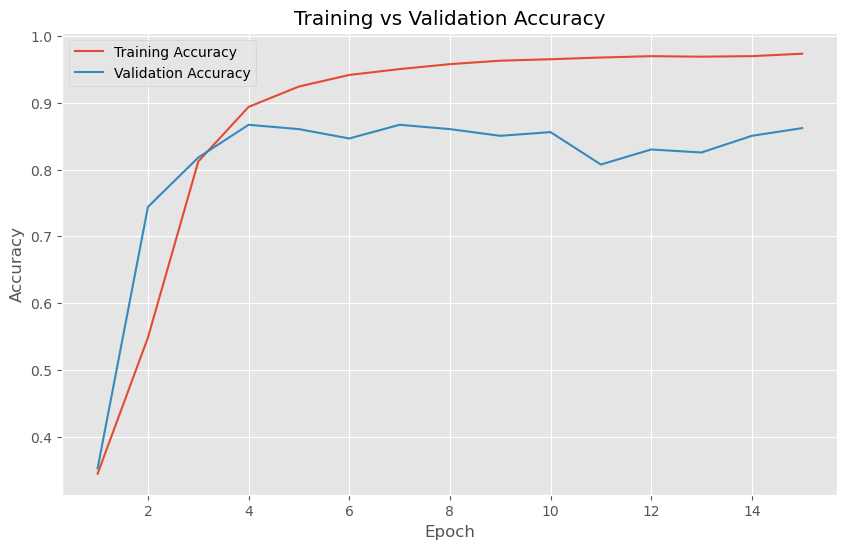

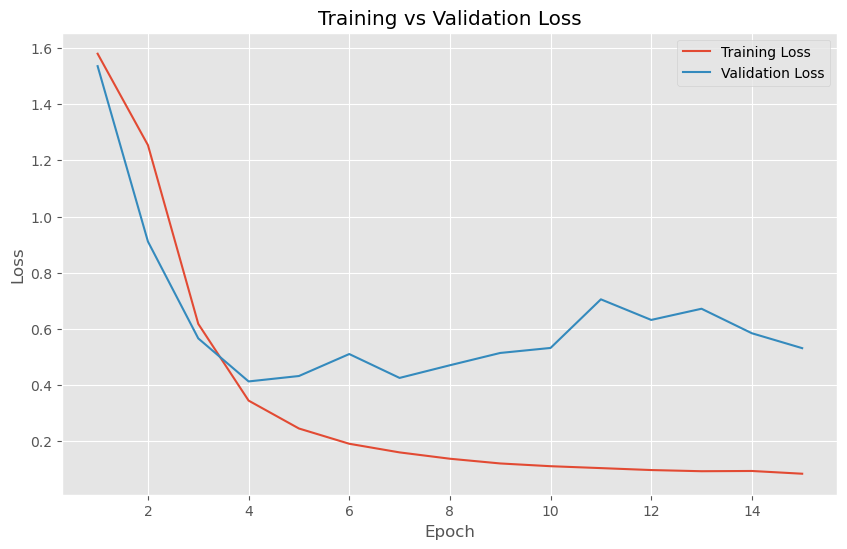

Best Validation Performance
Best Validation Accuracy : 0.8670
Best Accuracy Epoch      : 4
Lowest Validation Loss   : 0.4127
Lowest Loss Epoch        : 4


In [89]:
# ==========================================
# Visualize Training History
# ==========================================

import matplotlib.pyplot as plt

# Extract training history
history_dict = baseline_history.history

epochs_range = range(1, len(history_dict["accuracy"]) + 1)

# ------------------------------------------
# Training vs Validation Accuracy
# ------------------------------------------

plt.figure(figsize=(10, 6))
plt.plot(epochs_range, history_dict["accuracy"], label="Training Accuracy")
plt.plot(epochs_range, history_dict["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()


# ------------------------------------------
# Training vs Validation Loss
# ------------------------------------------

plt.figure(figsize=(10, 6))
plt.plot(epochs_range, history_dict["loss"], label="Training Loss")
plt.plot(epochs_range, history_dict["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()


# ------------------------------------------
# Best Validation Epoch
# ------------------------------------------

best_epoch_accuracy = (np.argmax(history_dict["val_accuracy"]) + 1)

best_val_accuracy = max(history_dict["val_accuracy"])

best_epoch_loss = (np.argmin(history_dict["val_loss"]) + 1)

best_val_loss = min(history_dict["val_loss"])

print("=" * 60)
print("Best Validation Performance")
print("=" * 60)

print(
    f"Best Validation Accuracy : "
    f"{best_val_accuracy:.4f}"
)

print(
    f"Best Accuracy Epoch      : "
    f"{best_epoch_accuracy}"
)

print(
    f"Lowest Validation Loss   : "
    f"{best_val_loss:.4f}"
)

print(
    f"Lowest Loss Epoch        : "
    f"{best_epoch_loss}"
)

## 10.7 Train Deep Learning Baseline with EarlyStopping

The baseline neural network is retrained using EarlyStopping to reduce overfitting.

Validation loss is monitored during training. If validation loss does not improve for three consecutive epochs, training is stopped and the model weights from the best validation epoch are restored.

The model architecture remains unchanged so that the impact of EarlyStopping can be evaluated independently.

In [90]:
# ==========================================
# Deep Learning Baseline with EarlyStopping
# ==========================================

from tensorflow.keras.callbacks import EarlyStopping

# Reproducibility
tf.random.set_seed(42)

# Create a fresh model with the same architecture
baseline_es_model = Sequential([
    Input(shape=(MAX_SEQUENCE_LENGTH,)),

    Embedding(
        input_dim=vocab_size,
        output_dim=EMBEDDING_DIM
    ),

    GlobalAveragePooling1D(),
    Dense(64, activation="relu"),
    Dropout(0.30),
    Dense(NUM_CLASSES, activation="softmax")
])

# Compile model
baseline_es_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Early stopping callback
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
    verbose=1
)

print("=" * 70)
print("Training Deep Learning Baseline with EarlyStopping")
print("=" * 70)

baseline_es_history = baseline_es_model.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    epochs=15,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

print("\n" + "=" * 70)
print("EarlyStopping Training Completed")
print("=" * 70)

print(
    f"Epochs Completed : "
    f"{len(baseline_es_history.history['loss'])}"
)

Training Deep Learning Baseline with EarlyStopping
Epoch 1/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.3527 - loss: 1.5749 - val_accuracy: 0.4285 - val_loss: 1.5157
Epoch 2/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.5582 - loss: 1.2322 - val_accuracy: 0.7495 - val_loss: 0.9798
Epoch 3/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.7862 - loss: 0.6596 - val_accuracy: 0.8125 - val_loss: 0.6347
Epoch 4/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.8803 - loss: 0.3907 - val_accuracy: 0.8340 - val_loss: 0.4946
Epoch 5/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.9197 - loss: 0.2666 - val_accuracy: 0.8505 - val_loss: 0.4743
Epoch 6/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.9365 - loss: 0.2107 - val_accuracy: 0.8430 - val_loss: 0.5070
Epoch 7/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.9464 - loss: 0.1691 - val_accuracy: 0.8605 - val_loss: 0.4443
Epoch 8/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 15m

## 10.8 Evaluate Deep Learning Baseline with EarlyStopping

The Deep Learning baseline trained with EarlyStopping is evaluated using the restored weights from the best validation epoch.

The same evaluation metrics used throughout the project are calculated for a fair comparison with the traditional machine learning models.

In [91]:
# ==========================================
# Evaluate Deep Learning Baseline
# with EarlyStopping
# ==========================================

# Generate validation predictions
y_val_prob_es = baseline_es_model.predict(X_val_pad, verbose=0)

y_val_pred_es = np.argmax(y_val_prob_es, axis=1)

# Calculate evaluation metrics
accuracy_es = accuracy_score(y_val, y_val_pred_es)

precision_es = precision_score(
    y_val,
    y_val_pred_es,
    average="weighted",
    zero_division=0
)

recall_es = recall_score(
    y_val,
    y_val_pred_es,
    average="weighted",
    zero_division=0
)

f1_weighted_es = f1_score(
    y_val,
    y_val_pred_es,
    average="weighted",
    zero_division=0
)

f1_macro_es = f1_score(
    y_val,
    y_val_pred_es,
    average="macro",
    zero_division=0
)

print("=" * 70)
print("Deep Learning Baseline + EarlyStopping")
print("Validation Performance")
print("=" * 70)

print(f"Accuracy          : {accuracy_es:.4f}")
print(f"Precision         : {precision_es:.4f}")
print(f"Recall            : {recall_es:.4f}")
print(f"Weighted F1-Score : {f1_weighted_es:.4f}")
print(f"Macro F1-Score    : {f1_macro_es:.4f}")

print("\n" + "=" * 70)
print("Classification Report")
print("=" * 70)

print(
    classification_report(
        y_val,
        y_val_pred_es,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

Deep Learning Baseline + EarlyStopping
Validation Performance
Accuracy          : 0.8775
Precision         : 0.8772
Recall            : 0.8775
Weighted F1-Score : 0.8768
Macro F1-Score    : 0.8437

Classification Report
              precision    recall  f1-score   support

       anger       0.87      0.89      0.88       275
        fear       0.86      0.77      0.81       212
         joy       0.91      0.90      0.91       704
        love       0.78      0.75      0.76       178
     sadness       0.89      0.94      0.91       550
    surprise       0.77      0.80      0.79        81

    accuracy                           0.88      2000
   macro avg       0.85      0.84      0.84      2000
weighted avg       0.88      0.88      0.88      2000



## 10.9 Add Deep Learning Baseline Results

The Deep Learning baseline with EarlyStopping is added to the model comparison table.

In [92]:
# ==========================================
# Add Deep Learning Baseline + EarlyStopping
# ==========================================

model_results.append({
    "Model": "Embedding + Dense",
    "Features": "Learned Embedding",
    "Text Representation": "Lemmatized",
    "Accuracy": accuracy_es,
    "Precision": precision_es,
    "Recall": recall_es,
    "Weighted F1": f1_weighted_es,
    "Macro F1": f1_macro_es
})

results_df = pd.DataFrame(model_results)

print("=" * 80)
print("Updated Model Comparison Table")
print("=" * 80)

display(
    results_df.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "Weighted F1": "{:.4f}",
        "Macro F1": "{:.4f}"
    })
)

Updated Model Comparison Table


,Model,Features,Text Representation,Accuracy,Precision,Recall,Weighted F1,Macro F1
0,Logistic Regression,BoW,Lemmatized,0.8850,0.8845,0.8850,0.8844,0.8530
1,Decision Tree,BoW,Lemmatized,0.8425,0.8477,0.8425,0.8440,0.8123
2,Random Forest,BoW,Lemmatized,0.8785,0.8805,0.8785,0.8789,0.8480
3,Logistic Regression,TF-IDF,Lemmatized,0.8630,0.8630,0.8630,0.8591,0.8178
4,Logistic Regression,"TF-IDF (1,2)",Lemmatized,0.8695,0.8705,0.8695,0.8649,0.8174
5,Logistic Regression,Word2Vec,Lemmatized,0.3520,0.1239,0.3520,0.1833,0.0868
6,Embedding + Dense,Learned Embedding,Lemmatized,0.8775,0.8772,0.8775,0.8768,0.8437


## 10.10 Build LSTM Model

The LSTM model is introduced to capture word order and contextual information within the text.

Unlike the previous GlobalAveragePooling model, the LSTM processes the token sequence sequentially and learns relationships between words.

The model uses a 100-dimensional trainable embedding layer, a 64-unit LSTM layer, dropout regularization, and a final classification layer for the six emotion classes.

In [93]:
# ==========================================
# Build LSTM Model
# ==========================================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Embedding,
    LSTM,
    Dense,
    Dropout
)
from tensorflow.keras.callbacks import EarlyStopping

# Reproducibility
tf.random.set_seed(42)

# ==========================================
# LSTM Architecture
# ==========================================

lstm_model = Sequential([
    Input(shape=(MAX_SEQUENCE_LENGTH,)),

    Embedding(
        input_dim=vocab_size,
        output_dim=EMBEDDING_DIM
    ),

    LSTM(64),
    Dropout(0.30),
    Dense(32, activation="relu"),
    Dropout(0.30),
    Dense(NUM_CLASSES, activation="softmax")
])

# ==========================================
# Compile Model
# ==========================================

lstm_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# ==========================================
# Display Model Architecture
# ==========================================

print("=" * 70)
print("LSTM Model Created")
print("=" * 70)

lstm_model.summary()

LSTM Model Created


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)              │ (None, 40, 100)             │       1,000,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ (None, 64)                  │          42,240 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 6)                   │             198 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,044,518 (3.98 MB)

 Trainable params: 1,044,518 (3.98 MB)

 Non-trainable params: 0 (0.00 B)

## 10.11 Train LSTM Model

The LSTM model is trained using the padded text sequences.

EarlyStopping is used to monitor validation loss and prevent unnecessary training once the model stops improving on unseen validation data.

The best-performing weights are automatically restored after training.

In [94]:
# ==========================================
# Train LSTM Model
# ==========================================

# Reproducibility
tf.random.set_seed(42)

# EarlyStopping
lstm_early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
    verbose=1
)

print("=" * 70)
print("Training LSTM Model")
print("=" * 70)

lstm_history = lstm_model.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    epochs=15,
    batch_size=32,
    callbacks=[lstm_early_stopping],
    verbose=1
)

print("\n" + "=" * 70)
print("LSTM Training Completed")
print("=" * 70)

print(
    f"Epochs Completed : "
    f"{len(lstm_history.history['loss'])}"
)

Training LSTM Model
Epoch 1/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 15s 26ms/step - accuracy: 0.3204 - loss: 1.6099 - val_accuracy: 0.3520 - val_loss: 1.5812
Epoch 2/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 13s 26ms/step - accuracy: 0.3259 - loss: 1.5875 - val_accuracy: 0.3520 - val_loss: 1.5806
Epoch 3/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 13s 25ms/step - accuracy: 0.3334 - loss: 1.5595 - val_accuracy: 0.3785 - val_loss: 1.4490
Epoch 4/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 13s 26ms/step - accuracy: 0.3343 - loss: 1.5657 - val_accuracy: 0.3520 - val_loss: 1.5814
Epoch 5/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 13s 26ms/step - accuracy: 0.3325 - loss: 1.5833 - val_accuracy: 0.3520 - val_loss: 1.5810
Epoch 6/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 13s 25ms/step - accuracy: 0.3317 - loss: 1.5808 - val_accuracy: 0.3520 - val_loss: 1.5807
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 3.

LSTM Training Completed
Epochs Completed : 6


## 10.12 LSTM Prediction Distribution

The validation prediction distribution is examined to determine whether the LSTM is collapsing to a single emotion class.

This diagnostic step helps identify whether the poor validation accuracy is caused by a prediction-class imbalance or another training issue.

In [95]:
# ==========================================
# LSTM Prediction Distribution
# ==========================================

# Generate validation predictions
y_val_prob_lstm = lstm_model.predict(X_val_pad, verbose=0)

y_val_pred_lstm = np.argmax(y_val_prob_lstm, axis=1)

# Count predictions by class
lstm_prediction_counts = (
    pd.Series(y_val_pred_lstm)
    .value_counts()
    .sort_index()
)

lstm_prediction_distribution = pd.DataFrame({
    "Emotion": label_encoder.inverse_transform(
        lstm_prediction_counts.index
    ),
    "Predicted Count": lstm_prediction_counts.values
})

print("=" * 60)
print("LSTM Prediction Distribution")
print("=" * 60)

display(lstm_prediction_distribution)

print("\nTotal Validation Predictions :", len(y_val_pred_lstm))

print(
    "Number of Predicted Classes :",
    len(np.unique(y_val_pred_lstm))
)

LSTM Prediction Distribution


,Emotion,Predicted Count
0,fear,530
1,joy,1470



Total Validation Predictions : 2000
Number of Predicted Classes : 2


## 10.13 LSTM Training Sanity Check

The LSTM training data and output probabilities are inspected to identify why the model is predicting only one emotion class.

The diagnostic checks:

- Training class distribution
- Number of non-zero tokens in the training sequences
- LSTM probability distribution for sample predictions

This helps determine whether the issue is related to the input data, target labels, or model learning behavior.

In [96]:
# ==========================================
# LSTM Training Sanity Check
# ==========================================

print("=" * 70)
print("LSTM Training Sanity Check")
print("=" * 70)

# ------------------------------------------
# 1. Training Label Distribution
# ------------------------------------------

train_label_counts = (pd.Series(y_train).value_counts().sort_index())

train_label_distribution = pd.DataFrame({
    "Emotion": label_encoder.inverse_transform(
        train_label_counts.index
    ),
    "Training Count": train_label_counts.values
})

print("\nTraining Label Distribution:")
display(train_label_distribution)

# ------------------------------------------
# 2. Training Sequence Information
# ------------------------------------------

non_zero_counts_train = np.count_nonzero(X_train_pad, axis=1)

print("\nTraining Sequence Statistics:")
print(
    f"Total Training Samples       : {len(X_train_pad):,}"
)
print(
    f"Average Non-Zero Tokens      : "
    f"{non_zero_counts_train.mean():.2f}"
)
print(
    f"Minimum Non-Zero Tokens      : "
    f"{non_zero_counts_train.min()}"
)
print(
    f"Maximum Non-Zero Tokens      : "
    f"{non_zero_counts_train.max()}"
)


# ------------------------------------------
# 3. Sample LSTM Predictions
# ------------------------------------------

sample_probabilities = lstm_model.predict(X_val_pad[:5], verbose=0)

sample_predictions = np.argmax(sample_probabilities, axis=1)

print("\nSample LSTM Predictions:")
print(label_encoder.inverse_transform(sample_predictions))

print("\nSample Prediction Probabilities:")

for i, probabilities in enumerate(sample_probabilities):
    print(f"\nSample {i + 1}:")
    
    for emotion, probability in zip(label_encoder.classes_, probabilities):
        print(
            f"  {emotion:<10}: "
            f"{probability:.4f}"
        )

LSTM Training Sanity Check

Training Label Distribution:


,Emotion,Training Count
0,anger,2159
1,fear,1937
2,joy,5362
3,love,1304
4,sadness,4666
5,surprise,572



Training Sequence Statistics:
Total Training Samples       : 16,000
Average Non-Zero Tokens      : 9.35
Minimum Non-Zero Tokens      : 1
Maximum Non-Zero Tokens      : 35

Sample LSTM Predictions:
['joy' 'joy' 'fear' 'joy' 'joy']

Sample Prediction Probabilities:

Sample 1:
  anger     : 0.0993
  fear      : 0.0713
  joy       : 0.4304
  love      : 0.0424
  sadness   : 0.3467
  surprise  : 0.0099

Sample 2:
  anger     : 0.0993
  fear      : 0.0713
  joy       : 0.4304
  love      : 0.0424
  sadness   : 0.3467
  surprise  : 0.0099

Sample 3:
  anger     : 0.1748
  fear      : 0.2395
  joy       : 0.1150
  love      : 0.2003
  sadness   : 0.1430
  surprise  : 0.1274

Sample 4:
  anger     : 0.0993
  fear      : 0.0713
  joy       : 0.4304
  love      : 0.0424
  sadness   : 0.3467
  surprise  : 0.0099

Sample 5:
  anger     : 0.0993
  fear      : 0.0713
  joy       : 0.4304
  love      : 0.0424
  sadness   : 0.3467
  surprise  : 0.0099


## 10.14 Train Class-Balanced LSTM

The previous LSTM model showed a strong tendency to predict the majority emotion classes.

To address this, the LSTM is retrained using two targeted improvements:

1. The Embedding layer uses `mask_zero=True` so padded positions are ignored.
2. Class weights are applied during training so that minority emotion classes receive greater importance.

The LSTM architecture remains otherwise unchanged.

In [97]:
# ==========================================
# Class-Balanced LSTM
# ==========================================

from sklearn.utils.class_weight import compute_class_weight

# Reproducibility
tf.random.set_seed(42)

# ==========================================
# Calculate Class Weights
# ==========================================

classes = np.unique(y_train)

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = dict(zip(classes, class_weights_array))

print("=" * 70)
print("Class Weights")
print("=" * 70)

for class_id, weight in class_weights.items():
    emotion_name = label_encoder.inverse_transform([class_id])[0]
    print(f"{emotion_name:<10} : {weight:.4f}")


# ==========================================
# Build Balanced LSTM
# ==========================================

balanced_lstm_model = Sequential([
    Input(shape=(MAX_SEQUENCE_LENGTH,)),

    Embedding(
        input_dim=vocab_size,
        output_dim=EMBEDDING_DIM,
        mask_zero=True
    ),

    LSTM(64),
    Dropout(0.30),
    Dense(32, activation="relu"),
    Dropout(0.30),
    Dense(NUM_CLASSES, activation="softmax")
])


# ==========================================
# Compile Model
# ==========================================

balanced_lstm_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


# ==========================================
# EarlyStopping
# ==========================================

balanced_lstm_early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
    verbose=1
)


# ==========================================
# Train Model
# ==========================================

print("\n" + "=" * 70)
print("Training Class-Balanced LSTM")
print("=" * 70)

balanced_lstm_history = balanced_lstm_model.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    epochs=15,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[balanced_lstm_early_stopping],
    verbose=1
)

print("\n" + "=" * 70)
print("Class-Balanced LSTM Training Completed")
print("=" * 70)

print(
    f"Epochs Completed : "
    f"{len(balanced_lstm_history.history['loss'])}"
)

Class Weights
anger      : 1.2351
fear       : 1.3767
joy        : 0.4973
love       : 2.0450
sadness    : 0.5715
surprise   : 4.6620

Training Class-Balanced LSTM
Epoch 1/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 16s 28ms/step - accuracy: 0.6144 - loss: 1.0943 - val_accuracy: 0.8820 - val_loss: 0.4011
Epoch 2/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 15s 30ms/step - accuracy: 0.9104 - loss: 0.3053 - val_accuracy: 0.9055 - val_loss: 0.3039
Epoch 3/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - accuracy: 0.9476 - loss: 0.1660 - val_accuracy: 0.9010 - val_loss: 0.3584
Epoch 4/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - accuracy: 0.9591 - loss: 0.1288 - val_accuracy: 0.9025 - val_loss: 0.3901
Epoch 5/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 14s 28ms/step - accuracy: 0.9645 - loss: 0.1058 - val_accuracy: 0.8955 - val_loss: 0.4131
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 2.

Class-Balanced LSTM Training Completed
Epochs Completed : 5


## 10.15 Evaluate Class-Balanced LSTM

The class-balanced LSTM is evaluated using the same metrics used for all previous models.

Special attention is given to Macro F1-score because the dataset contains significant class imbalance.

In [98]:
# ==========================================
# Evaluate Class-Balanced LSTM
# ==========================================

# Generate validation predictions
y_val_prob_balanced_lstm = balanced_lstm_model.predict(X_val_pad, verbose=0)

y_val_pred_balanced_lstm = np.argmax(y_val_prob_balanced_lstm, axis=1)

# Calculate evaluation metrics
accuracy_balanced_lstm = accuracy_score(y_val, y_val_pred_balanced_lstm)

precision_balanced_lstm = precision_score(
    y_val,
    y_val_pred_balanced_lstm,
    average="weighted",
    zero_division=0
)

recall_balanced_lstm = recall_score(
    y_val,
    y_val_pred_balanced_lstm,
    average="weighted",
    zero_division=0
)

f1_weighted_balanced_lstm = f1_score(
    y_val,
    y_val_pred_balanced_lstm,
    average="weighted",
    zero_division=0
)

f1_macro_balanced_lstm = f1_score(
    y_val,
    y_val_pred_balanced_lstm,
    average="macro",
    zero_division=0
)

print("=" * 70)
print("Class-Balanced LSTM")
print("Validation Performance")
print("=" * 70)

print(f"Accuracy          : {accuracy_balanced_lstm:.4f}")
print(f"Precision         : {precision_balanced_lstm:.4f}")
print(f"Recall            : {recall_balanced_lstm:.4f}")
print(
    f"Weighted F1-Score : "
    f"{f1_weighted_balanced_lstm:.4f}"
)
print(
    f"Macro F1-Score    : "
    f"{f1_macro_balanced_lstm:.4f}"
)

print("\n" + "=" * 70)
print("Classification Report")
print("=" * 70)

print(
    classification_report(
        y_val,
        y_val_pred_balanced_lstm,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

Class-Balanced LSTM
Validation Performance
Accuracy          : 0.9055
Precision         : 0.9108
Recall            : 0.9055
Weighted F1-Score : 0.9068
Macro F1-Score    : 0.8810

Classification Report
              precision    recall  f1-score   support

       anger       0.86      0.92      0.89       275
        fear       0.87      0.86      0.86       212
         joy       0.95      0.91      0.93       704
        love       0.79      0.91      0.84       178
     sadness       0.97      0.91      0.94       550
    surprise       0.74      0.93      0.82        81

    accuracy                           0.91      2000
   macro avg       0.86      0.90      0.88      2000
weighted avg       0.91      0.91      0.91      2000



## 10.16 Add Class-Balanced LSTM Results

The class-balanced LSTM achieved the best validation performance so far.

Class weighting and padding masking significantly improved the model's ability to learn minority emotion classes.

In [99]:
# ==========================================
# Add Class-Balanced LSTM Results
# ==========================================

model_results.append({
    "Model": "LSTM",
    "Features": "Class-Balanced Learned Embedding",
    "Text Representation": "Lemmatized",
    "Accuracy": accuracy_balanced_lstm,
    "Precision": precision_balanced_lstm,
    "Recall": recall_balanced_lstm,
    "Weighted F1": f1_weighted_balanced_lstm,
    "Macro F1": f1_macro_balanced_lstm
})

results_df = pd.DataFrame(model_results)

print("=" * 80)
print("Updated Model Comparison")
print("=" * 80)

display(
    results_df.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "Weighted F1": "{:.4f}",
        "Macro F1": "{:.4f}"
    })
)

Updated Model Comparison


,Model,Features,Text Representation,Accuracy,Precision,Recall,Weighted F1,Macro F1
0,Logistic Regression,BoW,Lemmatized,0.8850,0.8845,0.8850,0.8844,0.8530
1,Decision Tree,BoW,Lemmatized,0.8425,0.8477,0.8425,0.8440,0.8123
2,Random Forest,BoW,Lemmatized,0.8785,0.8805,0.8785,0.8789,0.8480
3,Logistic Regression,TF-IDF,Lemmatized,0.8630,0.8630,0.8630,0.8591,0.8178
4,Logistic Regression,"TF-IDF (1,2)",Lemmatized,0.8695,0.8705,0.8695,0.8649,0.8174
5,Logistic Regression,Word2Vec,Lemmatized,0.3520,0.1239,0.3520,0.1833,0.0868
6,Embedding + Dense,Learned Embedding,Lemmatized,0.8775,0.8772,0.8775,0.8768,0.8437
7,LSTM,Class-Balanced Learned Embedding,Lemmatized,0.9055,0.9108,0.9055,0.9068,0.8810


## 10.17 Build Bidirectional LSTM Model

A Bidirectional LSTM is introduced to capture contextual information from both directions of a text sequence.

The model processes the input sequence from beginning to end and from end to beginning, allowing it to use both previous and following words when learning emotional patterns.

The same embedding configuration, class weighting strategy, dropout, and output structure used in the LSTM model are retained for a fair comparison.

In [100]:
# ==========================================
# Build Bidirectional LSTM Model
# ==========================================

from tensorflow.keras.layers import Bidirectional

# Reproducibility
tf.random.set_seed(42)

# ==========================================
# BiLSTM Architecture
# ==========================================

bilstm_model = Sequential([
    Input(shape=(MAX_SEQUENCE_LENGTH,)),

    Embedding(
        input_dim=vocab_size,
        output_dim=EMBEDDING_DIM,
        mask_zero=True
    ),

    Bidirectional(LSTM(64)),
    Dropout(0.30),
    Dense(32, activation="relu"),
    Dropout(0.30),
    Dense(NUM_CLASSES, activation="softmax")
])

# ==========================================
# Compile Model
# ==========================================

bilstm_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# ==========================================
# Display Model Architecture
# ==========================================

print("=" * 70)
print("Bidirectional LSTM Model Created")
print("=" * 70)

bilstm_model.summary()

Bidirectional LSTM Model Created


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)              │ (None, 40, 100)             │       1,000,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional (Bidirectional)        │ (None, 128)                 │          84,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 32)                  │           4,128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_8 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 6)                   │             198 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,088,806 (4.15 MB)

 Trainable params: 1,088,806 (4.15 MB)

 Non-trainable params: 0 (0.00 B)

## 10.18 Train Bidirectional LSTM

The Bidirectional LSTM is trained using the same class-weighting strategy and EarlyStopping configuration as the previous LSTM model.

This allows a fair comparison between unidirectional and bidirectional sequence processing.

In [101]:
# ==========================================
# Train Bidirectional LSTM
# ==========================================

# Reproducibility
tf.random.set_seed(42)

# EarlyStopping
bilstm_early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
    verbose=1
)

print("=" * 70)
print("Training Bidirectional LSTM")
print("=" * 70)

bilstm_history = bilstm_model.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    epochs=15,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[bilstm_early_stopping],
    verbose=1
)

print("\n" + "=" * 70)
print("Bidirectional LSTM Training Completed")
print("=" * 70)

print(
    f"Epochs Completed : "
    f"{len(bilstm_history.history['loss'])}"
)

Training Bidirectional LSTM
Epoch 1/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 21s 35ms/step - accuracy: 0.5943 - loss: 1.0499 - val_accuracy: 0.8610 - val_loss: 0.4647
Epoch 2/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 18s 36ms/step - accuracy: 0.9014 - loss: 0.2917 - val_accuracy: 0.8930 - val_loss: 0.3433
Epoch 3/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 14s 28ms/step - accuracy: 0.9437 - loss: 0.1669 - val_accuracy: 0.8985 - val_loss: 0.3480
Epoch 4/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 15s 29ms/step - accuracy: 0.9587 - loss: 0.1217 - val_accuracy: 0.8895 - val_loss: 0.3766
Epoch 5/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 15s 30ms/step - accuracy: 0.9638 - loss: 0.1010 - val_accuracy: 0.8970 - val_loss: 0.3730
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 2.

Bidirectional LSTM Training Completed
Epochs Completed : 5


## 10.19 Evaluate Bidirectional LSTM

The Bidirectional LSTM is evaluated using the same validation metrics used for all previous models.

Macro F1-score is given particular importance because the emotion dataset is imbalanced.

In [102]:
# ==========================================
# Evaluate Bidirectional LSTM
# ==========================================

# Generate validation predictions
y_val_prob_bilstm = bilstm_model.predict(X_val_pad, verbose=0)

y_val_pred_bilstm = np.argmax(y_val_prob_bilstm, axis=1)

# ==========================================
# Calculate Metrics
# ==========================================

accuracy_bilstm = accuracy_score(y_val, y_val_pred_bilstm)

precision_bilstm = precision_score(
    y_val,
    y_val_pred_bilstm,
    average="weighted",
    zero_division=0
)

recall_bilstm = recall_score(
    y_val,
    y_val_pred_bilstm,
    average="weighted",
    zero_division=0
)

f1_weighted_bilstm = f1_score(
    y_val,
    y_val_pred_bilstm,
    average="weighted",
    zero_division=0
)

f1_macro_bilstm = f1_score(
    y_val,
    y_val_pred_bilstm,
    average="macro",
    zero_division=0
)

# ==========================================
# Display Results
# ==========================================

print("=" * 70)
print("Bidirectional LSTM")
print("Validation Performance")
print("=" * 70)

print(f"Accuracy          : {accuracy_bilstm:.4f}")
print(f"Precision         : {precision_bilstm:.4f}")
print(f"Recall            : {recall_bilstm:.4f}")
print(
    f"Weighted F1-Score : "
    f"{f1_weighted_bilstm:.4f}"
)
print(
    f"Macro F1-Score    : "
    f"{f1_macro_bilstm:.4f}"
)

print("\n" + "=" * 70)
print("Classification Report")
print("=" * 70)

print(
    classification_report(
        y_val,
        y_val_pred_bilstm,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

Bidirectional LSTM
Validation Performance
Accuracy          : 0.8930
Precision         : 0.8979
Recall            : 0.8930
Weighted F1-Score : 0.8942
Macro F1-Score    : 0.8634

Classification Report
              precision    recall  f1-score   support

       anger       0.85      0.93      0.89       275
        fear       0.85      0.84      0.85       212
         joy       0.94      0.90      0.92       704
        love       0.80      0.82      0.81       178
     sadness       0.95      0.90      0.92       550
    surprise       0.69      0.93      0.79        81

    accuracy                           0.89      2000
   macro avg       0.85      0.89      0.86      2000
weighted avg       0.90      0.89      0.89      2000



In [103]:
# ==========================================
# Add BiLSTM Results
# ==========================================

model_results.append({
    "Model": "BiLSTM",
    "Features": "Class-Balanced Learned Embedding",
    "Text Representation": "Lemmatized",
    "Accuracy": accuracy_bilstm,
    "Precision": precision_bilstm,
    "Recall": recall_bilstm,
    "Weighted F1": f1_weighted_bilstm,
    "Macro F1": f1_macro_bilstm
})

results_df = pd.DataFrame(model_results)

print("=" * 80)
print("Updated Model Comparison")
print("=" * 80)

display(
    results_df.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "Weighted F1": "{:.4f}",
        "Macro F1": "{:.4f}"
    })
)

Updated Model Comparison


,Model,Features,Text Representation,Accuracy,Precision,Recall,Weighted F1,Macro F1
0,Logistic Regression,BoW,Lemmatized,0.8850,0.8845,0.8850,0.8844,0.8530
1,Decision Tree,BoW,Lemmatized,0.8425,0.8477,0.8425,0.8440,0.8123
2,Random Forest,BoW,Lemmatized,0.8785,0.8805,0.8785,0.8789,0.8480
3,Logistic Regression,TF-IDF,Lemmatized,0.8630,0.8630,0.8630,0.8591,0.8178
4,Logistic Regression,"TF-IDF (1,2)",Lemmatized,0.8695,0.8705,0.8695,0.8649,0.8174
5,Logistic Regression,Word2Vec,Lemmatized,0.3520,0.1239,0.3520,0.1833,0.0868
6,Embedding + Dense,Learned Embedding,Lemmatized,0.8775,0.8772,0.8775,0.8768,0.8437
7,LSTM,Class-Balanced Learned Embedding,Lemmatized,0.9055,0.9108,0.9055,0.9068,0.8810
8,BiLSTM,Class-Balanced Learned Embedding,Lemmatized,0.8930,0.8979,0.8930,0.8942,0.8634


## 10.20 Build 1D CNN Text Classification Model

A 1D Convolutional Neural Network (CNN) is introduced for emotion classification.

The model uses the same padded text sequences and learned embedding representation used in the previous deep learning models.

The CNN is designed to identify important local word patterns and short phrases that can provide strong signals for emotion classification.

Examples of useful local patterns may include phrases such as "very happy", "feel lonely", "really angry", or "so scared".

The model will use class weighting and EarlyStopping to maintain consistency with the best-performing LSTM experiment.

In [104]:
# ==========================================
# Build 1D CNN Text Classification Model
# ==========================================

from tensorflow.keras.layers import (
    Conv1D,
    GlobalMaxPooling1D
)

# Reproducibility
tf.random.set_seed(42)

# ==========================================
# CNN Architecture
# ==========================================

cnn_model = Sequential([
    Input(shape=(MAX_SEQUENCE_LENGTH,)),

    Embedding(
        input_dim=vocab_size,
        output_dim=EMBEDDING_DIM
    ),

    Conv1D(filters=128, kernel_size=3, activation="relu"),
    GlobalMaxPooling1D(),
    Dense(64, activation="relu"),
    Dropout(0.30),
    Dense(NUM_CLASSES, activation="softmax")
])

# ==========================================
# Compile Model
# ==========================================

cnn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# ==========================================
# Display Model Architecture
# ==========================================

print("=" * 70)
print("1D CNN Text Classification Model Created")
print("=" * 70)

cnn_model.summary()

1D CNN Text Classification Model Created


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)              │ (None, 40, 100)             │       1,000,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d (Conv1D)                      │ (None, 38, 128)             │          38,528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_max_pooling1d                 │ (None, 128)                 │               0 │
│ (GlobalMaxPooling1D)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_9 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 6)                   │             390 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,047,174 (3.99 MB)

 Trainable params: 1,047,174 (3.99 MB)

 Non-trainable params: 0 (0.00 B)

## 10.21 Train 1D CNN Text Classification Model

The 1D CNN is trained using the same class weights and EarlyStopping strategy used for the LSTM and BiLSTM models.

This allows the CNN results to be compared fairly with the previous deep learning approaches.

In [105]:
# ==========================================
# Train 1D CNN Text Classification Model
# ==========================================

# Reproducibility
tf.random.set_seed(42)

# ==========================================
# EarlyStopping
# ==========================================

cnn_early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
    verbose=1
)

# ==========================================
# Train CNN
# ==========================================

print("=" * 70)
print("Training 1D CNN Text Classification Model")
print("=" * 70)

cnn_history = cnn_model.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    epochs=15,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[cnn_early_stopping],
    verbose=1
)

print("\n" + "=" * 70)
print("1D CNN Training Completed")
print("=" * 70)

print(
    f"Epochs Completed : "
    f"{len(cnn_history.history['loss'])}"
)

Training 1D CNN Text Classification Model
Epoch 1/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - accuracy: 0.6886 - loss: 0.8222 - val_accuracy: 0.9115 - val_loss: 0.2577
Epoch 2/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.9280 - loss: 0.1860 - val_accuracy: 0.9135 - val_loss: 0.2416
Epoch 3/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.9555 - loss: 0.1160 - val_accuracy: 0.9110 - val_loss: 0.2655
Epoch 4/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.9726 - loss: 0.0714 - val_accuracy: 0.9125 - val_loss: 0.2854
Epoch 5/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.9831 - loss: 0.0490 - val_accuracy: 0.9120 - val_loss: 0.3217
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 2.

1D CNN Training Completed
Epochs Completed : 5


## 10.22 Evaluate 1D CNN Text Classification Model

The trained 1D CNN is evaluated using the same validation metrics used for all previous models.

Macro F1-score is given particular importance because the dataset contains significant class imbalance.

In [106]:
# ==========================================
# Evaluate 1D CNN
# ==========================================

# Generate validation probabilities
y_val_prob_cnn = cnn_model.predict(X_val_pad, verbose=0)

# Convert probabilities to predicted class labels
y_val_pred_cnn = np.argmax(y_val_prob_cnn, axis=1)

# ==========================================
# Calculate Evaluation Metrics
# ==========================================

accuracy_cnn = accuracy_score(y_val, y_val_pred_cnn)

precision_cnn = precision_score(
    y_val,
    y_val_pred_cnn,
    average="weighted",
    zero_division=0
)

recall_cnn = recall_score(
    y_val,
    y_val_pred_cnn,
    average="weighted",
    zero_division=0
)

f1_weighted_cnn = f1_score(
    y_val,
    y_val_pred_cnn,
    average="weighted",
    zero_division=0
)

f1_macro_cnn = f1_score(
    y_val,
    y_val_pred_cnn,
    average="macro",
    zero_division=0
)

# ==========================================
# Display Results
# ==========================================

print("=" * 70)
print("1D CNN Text Classification Model")
print("Validation Performance")
print("=" * 70)

print(f"Accuracy          : {accuracy_cnn:.4f}")
print(f"Precision         : {precision_cnn:.4f}")
print(f"Recall            : {recall_cnn:.4f}")
print(
    f"Weighted F1-Score : "
    f"{f1_weighted_cnn:.4f}"
)
print(
    f"Macro F1-Score    : "
    f"{f1_macro_cnn:.4f}"
)

# ==========================================
# Classification Report
# ==========================================

print("\n" + "=" * 70)
print("Classification Report")
print("=" * 70)

print(
    classification_report(
        y_val,
        y_val_pred_cnn,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

1D CNN Text Classification Model
Validation Performance
Accuracy          : 0.9135
Precision         : 0.9217
Recall            : 0.9135
Weighted F1-Score : 0.9149
Macro F1-Score    : 0.8900

Classification Report
              precision    recall  f1-score   support

       anger       0.89      0.95      0.92       275
        fear       0.91      0.81      0.86       212
         joy       0.97      0.90      0.93       704
        love       0.76      0.96      0.85       178
     sadness       0.97      0.92      0.94       550
    surprise       0.73      0.99      0.84        81

    accuracy                           0.91      2000
   macro avg       0.87      0.92      0.89      2000
weighted avg       0.92      0.91      0.91      2000



## 10.23 Add 1D CNN Results to Master Comparison

The 1D CNN achieved the best validation performance so far.

It improved both overall accuracy and Macro F1-score compared with the previous Class-Balanced LSTM benchmark.

In [107]:
# ==========================================
# Add 1D CNN Results
# ==========================================

model_results.append({
    "Model": "1D CNN",
    "Features": "Class-Balanced Learned Embedding",
    "Text Representation": "Lemmatized",
    "Accuracy": accuracy_cnn,
    "Precision": precision_cnn,
    "Recall": recall_cnn,
    "Weighted F1": f1_weighted_cnn,
    "Macro F1": f1_macro_cnn
})

results_df = pd.DataFrame(model_results)

print("=" * 80)
print("Updated Model Comparison")
print("=" * 80)

display(
    results_df.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "Weighted F1": "{:.4f}",
        "Macro F1": "{:.4f}"
    })
)

Updated Model Comparison


,Model,Features,Text Representation,Accuracy,Precision,Recall,Weighted F1,Macro F1
0,Logistic Regression,BoW,Lemmatized,0.8850,0.8845,0.8850,0.8844,0.8530
1,Decision Tree,BoW,Lemmatized,0.8425,0.8477,0.8425,0.8440,0.8123
2,Random Forest,BoW,Lemmatized,0.8785,0.8805,0.8785,0.8789,0.8480
3,Logistic Regression,TF-IDF,Lemmatized,0.8630,0.8630,0.8630,0.8591,0.8178
4,Logistic Regression,"TF-IDF (1,2)",Lemmatized,0.8695,0.8705,0.8695,0.8649,0.8174
5,Logistic Regression,Word2Vec,Lemmatized,0.3520,0.1239,0.3520,0.1833,0.0868
6,Embedding + Dense,Learned Embedding,Lemmatized,0.8775,0.8772,0.8775,0.8768,0.8437
7,LSTM,Class-Balanced Learned Embedding,Lemmatized,0.9055,0.9108,0.9055,0.9068,0.8810
8,BiLSTM,Class-Balanced Learned Embedding,Lemmatized,0.8930,0.8979,0.8930,0.8942,0.8634
9,1D CNN,Class-Balanced Learned Embedding,Lemmatized,0.9135,0.9217,0.9135,0.9149,0.8900


## 10.24 Multi-Kernel CNN Text Classification

To improve the baseline 1D CNN, we use multiple convolutional filters with different kernel sizes.

The three branches use kernel sizes 2, 3, and 4 to capture text patterns of different lengths.

The resulting features are combined before classification.

The same padded sequences, learned embedding approach, class weights, batch size, and EarlyStopping strategy are retained for a fair comparison with the previous CNN and LSTM models.

In [108]:
# ==========================================
# Multi-Kernel CNN Text Classification Model
# ==========================================

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Embedding,
    Conv1D,
    GlobalMaxPooling1D,
    Dense,
    Dropout,
    Concatenate
)

# ==========================================
# Model Configuration
# ==========================================

EMBEDDING_DIM = 100
NUM_FILTERS = 128

# ==========================================
# Input Layer
# ==========================================

input_layer = Input(
    shape=(MAX_SEQUENCE_LENGTH,),
    name="text_input"
)

# ==========================================
# Shared Embedding Layer
# ==========================================

embedding_layer = Embedding(
    input_dim=vocab_size,
    output_dim=EMBEDDING_DIM,
    name="embedding"
)(input_layer)

# ==========================================
# Kernel Size 2
# ==========================================

conv_2 = Conv1D(
    filters=NUM_FILTERS,
    kernel_size=2,
    activation="relu",
    padding="valid",
    name="conv_kernel_2"
)(embedding_layer)

pool_2 = GlobalMaxPooling1D(
    name="pool_kernel_2"
)(conv_2)

# ==========================================
# Kernel Size 3
# ==========================================

conv_3 = Conv1D(
    filters=NUM_FILTERS,
    kernel_size=3,
    activation="relu",
    padding="valid",
    name="conv_kernel_3"
)(embedding_layer)

pool_3 = GlobalMaxPooling1D(
    name="pool_kernel_3"
)(conv_3)

# ==========================================
# Kernel Size 4
# ==========================================

conv_4 = Conv1D(
    filters=NUM_FILTERS,
    kernel_size=4,
    activation="relu",
    padding="valid",
    name="conv_kernel_4"
)(embedding_layer)

pool_4 = GlobalMaxPooling1D(
    name="pool_kernel_4"
)(conv_4)

# ==========================================
# Combine Multi-Kernel Features
# ==========================================

merged_features = Concatenate(
    name="multi_kernel_features"
)([
    pool_2,
    pool_3,
    pool_4
])

# ==========================================
# Dense Classification Layer
# ==========================================

dense_layer = Dense(
    128,
    activation="relu",
    name="dense_features"
)(merged_features)

dropout_layer = Dropout(
    0.5,
    name="dropout"
)(dense_layer)

# ==========================================
# Output Layer
# ==========================================

output_layer = Dense(
    NUM_CLASSES,
    activation="softmax",
    name="emotion_output"
)(dropout_layer)

# ==========================================
# Create Model
# ==========================================

multi_kernel_cnn_model = Model(
    inputs=input_layer,
    outputs=output_layer,
    name="Multi_Kernel_CNN"
)

# ==========================================
# Compile Model
# ==========================================

multi_kernel_cnn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# ==========================================
# Display Model
# ==========================================

print("=" * 70)
print("Multi-Kernel CNN Text Classification Model Created")
print("=" * 70)

multi_kernel_cnn_model.summary()

Multi-Kernel CNN Text Classification Model Created


Model: "Multi_Kernel_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ text_input (InputLayer)       │ (None, 40)                │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ embedding (Embedding)         │ (None, 40, 100)           │       1,000,000 │ text_input[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv_kernel_2 (Conv1D)        │ (None, 39, 128)           │          25,728 │ embedding[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv_kernel_3 (Conv1D)        │ (None, 38, 128)           │          38,528 │ embedding[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv_kernel_4 (Conv1D)        │ (None, 37, 128)           │          51,328 │ embedding[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pool_kernel_2                 │ (None, 128)               │               0 │ conv_kernel_2[0][0]        │
│ (GlobalMaxPooling1D)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pool_kernel_3                 │ (None, 128)               │               0 │ conv_kernel_3[0][0]        │
│ (GlobalMaxPooling1D)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pool_kernel_4                 │ (None, 128)               │               0 │ conv_kernel_4[0][0]        │
│ (GlobalMaxPooling1D)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ multi_kernel_features         │ (None, 384)               │               0 │ pool_kernel_2[0][0],       │
│ (Concatenate)                 │                           │                 │ pool_kernel_3[0][0],       │
│                               │                           │                 │ pool_kernel_4[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_features (Dense)        │ (None, 128)               │          49,280 │ multi_kernel_features[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout (Dropout)             │ (None, 128)               │               0 │ dense_features[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ emotion_output (Dense)        │ (None, 6)                 │             774 │ dropout[0][0]              │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 1,165,638 (4.45 MB)

 Trainable params: 1,165,638 (4.45 MB)

 Non-trainable params: 0 (0.00 B)

## 10.25 Train Multi-Kernel CNN

The Multi-Kernel CNN is trained using class weights to address the class imbalance in the emotion dataset.

EarlyStopping monitors validation loss and restores the weights from the best-performing epoch.

In [109]:
# ==========================================
# Train Multi-Kernel CNN
# ==========================================

from tensorflow.keras.callbacks import EarlyStopping

# ==========================================
# EarlyStopping Configuration
# ==========================================

early_stopping_mcnn = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
    verbose=1
)

# ==========================================
# Train Model
# ==========================================

print("=" * 70)
print("Training Multi-Kernel CNN")
print("=" * 70)

multi_kernel_cnn_history = multi_kernel_cnn_model.fit(
    X_train_pad,
    y_train,
    validation_data=(
        X_val_pad,
        y_val
    ),
    epochs=15,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[early_stopping_mcnn],
    verbose=1
)

print()
print("=" * 70)
print("Multi-Kernel CNN Training Completed")
print("=" * 70)

print(
    "Epochs Completed :",
    len(multi_kernel_cnn_history.history["loss"])
)

Training Multi-Kernel CNN
Epoch 1/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 12s 21ms/step - accuracy: 0.6596 - loss: 0.8931 - val_accuracy: 0.9155 - val_loss: 0.2484
Epoch 2/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - accuracy: 0.9234 - loss: 0.2069 - val_accuracy: 0.9155 - val_loss: 0.2410
Epoch 3/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 12s 23ms/step - accuracy: 0.9511 - loss: 0.1282 - val_accuracy: 0.9155 - val_loss: 0.2499
Epoch 4/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 11s 21ms/step - accuracy: 0.9712 - loss: 0.0767 - val_accuracy: 0.9060 - val_loss: 0.3133
Epoch 5/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.9804 - loss: 0.0538 - val_accuracy: 0.9180 - val_loss: 0.3055
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 2.

Multi-Kernel CNN Training Completed
Epochs Completed : 5


## 10.26 Multi-Kernel CNN Validation Evaluation

The Multi-Kernel CNN is evaluated on the validation dataset using accuracy, precision, recall, weighted F1-score, and macro F1-score.

Macro F1-score is given particular importance because the emotion dataset is imbalanced.

In [110]:
# ==========================================
# Multi-Kernel CNN Validation Evaluation
# ==========================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)
import numpy as np

# ==========================================
# Generate Validation Predictions
# ==========================================

y_val_prob_mcnn = multi_kernel_cnn_model.predict(X_val_pad, verbose=0)

y_val_pred_mcnn = np.argmax(y_val_prob_mcnn, axis=1)

# ==========================================
# Calculate Evaluation Metrics
# ==========================================

accuracy_mcnn = accuracy_score(y_val, y_val_pred_mcnn)

precision_mcnn = precision_score(
    y_val,
    y_val_pred_mcnn,
    average="weighted",
    zero_division=0
)

recall_mcnn = recall_score(
    y_val,
    y_val_pred_mcnn,
    average="weighted",
    zero_division=0
)

f1_weighted_mcnn = f1_score(
    y_val,
    y_val_pred_mcnn,
    average="weighted",
    zero_division=0
)

f1_macro_mcnn = f1_score(
    y_val,
    y_val_pred_mcnn,
    average="macro",
    zero_division=0
)

# ==========================================
# Display Overall Metrics
# ==========================================

print("=" * 70)
print("Multi-Kernel CNN Validation Performance")
print("=" * 70)

print(f"Accuracy          : {accuracy_mcnn:.4f}")
print(f"Precision         : {precision_mcnn:.4f}")
print(f"Recall            : {recall_mcnn:.4f}")
print(f"Weighted F1-Score : {f1_weighted_mcnn:.4f}")
print(f"Macro F1-Score    : {f1_macro_mcnn:.4f}")

# ==========================================
# Classification Report
# ==========================================

print()
print("=" * 70)
print("Multi-Kernel CNN Classification Report")
print("=" * 70)

print(
    classification_report(
        y_val,
        y_val_pred_mcnn,
        target_names=label_encoder.classes_,
        digits=2,
        zero_division=0
    )
)

Multi-Kernel CNN Validation Performance
Accuracy          : 0.9155
Precision         : 0.9230
Recall            : 0.9155
Weighted F1-Score : 0.9169
Macro F1-Score    : 0.8896

Multi-Kernel CNN Classification Report
              precision    recall  f1-score   support

       anger       0.89      0.96      0.92       275
        fear       0.91      0.82      0.86       212
         joy       0.96      0.91      0.93       704
        love       0.78      0.93      0.85       178
     sadness       0.98      0.93      0.95       550
    surprise       0.71      0.98      0.82        81

    accuracy                           0.92      2000
   macro avg       0.87      0.92      0.89      2000
weighted avg       0.92      0.92      0.92      2000



## Multi-Kernel CNN Added to Model Comparison

The Multi-Kernel CNN uses multiple convolutional kernel sizes to capture text patterns of different lengths. Its validation performance is added to the overall model comparison table.

In [111]:
# ==========================================
# Add Multi-Kernel CNN to Model Comparison
# ==========================================

multi_kernel_cnn_result = {
    "Model": "Multi-Kernel CNN",
    "Features": "Class-Balanced Learned Embedding",
    "Text Representation": "Lemmatized",
    "Accuracy": accuracy_mcnn,
    "Precision": precision_mcnn,
    "Recall": recall_mcnn,
    "Weighted F1": f1_weighted_mcnn,
    "Macro F1": f1_macro_mcnn
}

results_df = pd.concat(
    [
        results_df,
        pd.DataFrame([multi_kernel_cnn_result])
    ],
    ignore_index=True
)

# ==========================================
# Display Updated Comparison Table
# ==========================================

print("=" * 100)
print("Updated Model Comparison")
print("=" * 100)

display(
    results_df.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "Weighted F1": "{:.4f}",
        "Macro F1": "{:.4f}"
    })
)

Updated Model Comparison


,Model,Features,Text Representation,Accuracy,Precision,Recall,Weighted F1,Macro F1
0,Logistic Regression,BoW,Lemmatized,0.8850,0.8845,0.8850,0.8844,0.8530
1,Decision Tree,BoW,Lemmatized,0.8425,0.8477,0.8425,0.8440,0.8123
2,Random Forest,BoW,Lemmatized,0.8785,0.8805,0.8785,0.8789,0.8480
3,Logistic Regression,TF-IDF,Lemmatized,0.8630,0.8630,0.8630,0.8591,0.8178
4,Logistic Regression,"TF-IDF (1,2)",Lemmatized,0.8695,0.8705,0.8695,0.8649,0.8174
5,Logistic Regression,Word2Vec,Lemmatized,0.3520,0.1239,0.3520,0.1833,0.0868
6,Embedding + Dense,Learned Embedding,Lemmatized,0.8775,0.8772,0.8775,0.8768,0.8437
7,LSTM,Class-Balanced Learned Embedding,Lemmatized,0.9055,0.9108,0.9055,0.9068,0.8810
8,BiLSTM,Class-Balanced Learned Embedding,Lemmatized,0.8930,0.8979,0.8930,0.8942,0.8634
9,1D CNN,Class-Balanced Learned Embedding,Lemmatized,0.9135,0.9217,0.9135,0.9149,0.8900


## 10.27 Regularized Multi-Kernel CNN

The Multi-Kernel CNN achieved the best validation performance so far, but the training history showed signs of overfitting.

To improve generalization, a regularized version of the Multi-Kernel CNN will be developed using:

- Multiple convolutional kernel sizes (2, 3, and 4)
- Batch Normalization
- Dropout
- L2 regularization
- Class-weighted training
- EarlyStopping

The same padded sequences and learned embedding approach will be retained so that the results can be compared fairly with the original Multi-Kernel CNN.

In [112]:
# ==========================================
# Regularized Multi-Kernel CNN
# ==========================================

import tensorflow as tf

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Embedding,
    Conv1D,
    GlobalMaxPooling1D,
    Concatenate,
    Dense,
    Dropout,
    BatchNormalization
)
from tensorflow.keras.regularizers import l2


# ==========================================
# Model Configuration
# ==========================================

embedding_dim = 100
num_filters = 128
kernel_sizes = [2, 3, 4]

l2_strength = 0.001
dropout_rate = 0.40


# ==========================================
# Input Layer
# ==========================================

text_input = Input(
    shape=(X_train_pad.shape[1],),
    name="text_input"
)


# ==========================================
# Learned Embedding Layer
# ==========================================

embedding = Embedding(
    input_dim=vocab_size,
    output_dim=embedding_dim,
    name="embedding"
)(text_input)


# ==========================================
# Multiple CNN Branches
# ==========================================

cnn_features = []

for kernel_size in kernel_sizes:

    conv = Conv1D(
        filters=num_filters,
        kernel_size=kernel_size,
        activation="relu",
        padding="valid",
        name=f"conv_kernel_{kernel_size}"
    )(embedding)

    batch_norm = BatchNormalization(
        name=f"batch_norm_{kernel_size}"
    )(conv)

    pooled = GlobalMaxPooling1D(
        name=f"pool_kernel_{kernel_size}"
    )(batch_norm)

    cnn_features.append(pooled)


# ==========================================
# Concatenate CNN Features
# ==========================================

multi_kernel_features = Concatenate(
    name="multi_kernel_features"
)(cnn_features)


# ==========================================
# Feature Processing Layer
# ==========================================

dense_features = Dense(
    128,
    activation="relu",
    kernel_regularizer=l2(l2_strength),
    name="dense_features"
)(multi_kernel_features)


# ==========================================
# Dropout
# ==========================================

dropout = Dropout(
    dropout_rate,
    name="dropout"
)(dense_features)


# ==========================================
# Output Layer
# ==========================================

emotion_output = Dense(
    6,
    activation="softmax",
    name="emotion_output"
)(dropout)


# ==========================================
# Create Model
# ==========================================

regularized_multi_kernel_cnn = Model(
    inputs=text_input,
    outputs=emotion_output,
    name="Regularized_Multi_Kernel_CNN"
)


# ==========================================
# Compile Model
# ==========================================

regularized_multi_kernel_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


# ==========================================
# Display Model Summary
# ==========================================

print("=" * 70)
print("Regularized Multi-Kernel CNN Model Created")
print("=" * 70)

regularized_multi_kernel_cnn.summary()

Regularized Multi-Kernel CNN Model Created


Model: "Regularized_Multi_Kernel_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ text_input (InputLayer)       │ (None, 40)                │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ embedding (Embedding)         │ (None, 40, 100)           │       1,000,000 │ text_input[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv_kernel_2 (Conv1D)        │ (None, 39, 128)           │          25,728 │ embedding[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv_kernel_3 (Conv1D)        │ (None, 38, 128)           │          38,528 │ embedding[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv_kernel_4 (Conv1D)        │ (None, 37, 128)           │          51,328 │ embedding[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_norm_2                  │ (None, 39, 128)           │             512 │ conv_kernel_2[0][0]        │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_norm_3                  │ (None, 38, 128)           │             512 │ conv_kernel_3[0][0]        │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_norm_4                  │ (None, 37, 128)           │             512 │ conv_kernel_4[0][0]        │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pool_kernel_2                 │ (None, 128)               │               0 │ batch_norm_2[0][0]         │
│ (GlobalMaxPooling1D)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pool_kernel_3                 │ (None, 128)               │               0 │ batch_norm_3[0][0]         │
│ (GlobalMaxPooling1D)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pool_kernel_4                 │ (None, 128)               │               0 │ batch_norm_4[0][0]         │
│ (GlobalMaxPooling1D)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ multi_kernel_features         │ (None, 384)               │               0 │ pool_kernel_2[0][0],       │
│ (Concatenate)                 │                           │                 │ pool_kernel_3[0][0],       │
│                               │                           │                 │ pool_kernel_4[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_features (Dense)        │ (None, 128)               │          49,280 │ multi_kernel_features[0][… │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 1,167,174 (4.45 MB)

 Trainable params: 1,166,406 (4.45 MB)

 Non-trainable params: 768 (3.00 KB)

In [113]:
# ==========================================
# Train Regularized Multi-Kernel CNN
# ==========================================

from tensorflow.keras.callbacks import EarlyStopping

early_stopping_rmcnn = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
    verbose=1
)

print("=" * 70)
print("Training Regularized Multi-Kernel CNN")
print("=" * 70)

regularized_multi_kernel_cnn_history = (
    regularized_multi_kernel_cnn.fit(
        X_train_pad,
        y_train,
        validation_data=(
            X_val_pad,
            y_val
        ),
        epochs=15,
        batch_size=32,
        class_weight=class_weights,
        callbacks=[early_stopping_rmcnn],
        verbose=1
    )
)

print()
print("=" * 70)
print("Regularized Multi-Kernel CNN Training Completed")
print("=" * 70)

print(
    "Epochs Completed :",
    len(
        regularized_multi_kernel_cnn_history.history["loss"]
    )
)

Training Regularized Multi-Kernel CNN
Epoch 1/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 15s 25ms/step - accuracy: 0.6196 - loss: 1.1074 - val_accuracy: 0.9035 - val_loss: 0.6128
Epoch 2/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - accuracy: 0.9234 - loss: 0.3143 - val_accuracy: 0.9110 - val_loss: 0.3714
Epoch 3/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - accuracy: 0.9538 - loss: 0.2028 - val_accuracy: 0.9115 - val_loss: 0.3713
Epoch 4/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 13s 26ms/step - accuracy: 0.9685 - loss: 0.1490 - val_accuracy: 0.9105 - val_loss: 0.3745
Epoch 5/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 16s 33ms/step - accuracy: 0.9753 - loss: 0.1246 - val_accuracy: 0.9015 - val_loss: 0.4100
Epoch 6/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - accuracy: 0.9794 - loss: 0.1035 - val_accuracy: 0.9130 - val_loss: 0.4031
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 3.

Regularized Multi-Kernel CNN Training Completed
Epochs Completed : 6


In [114]:
# ============================================================
# Evaluate Regularized Multi-Kernel CNN
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# Generate validation predictions
y_val_prob_rmcnn = regularized_multi_kernel_cnn.predict(
    X_val_pad,
    verbose=0
)

y_val_pred_rmcnn = y_val_prob_rmcnn.argmax(axis=1)

# Calculate metrics
accuracy_rmcnn = accuracy_score(
    y_val,
    y_val_pred_rmcnn
)

precision_rmcnn = precision_score(
    y_val,
    y_val_pred_rmcnn,
    average="weighted",
    zero_division=0
)

recall_rmcnn = recall_score(
    y_val,
    y_val_pred_rmcnn,
    average="weighted",
    zero_division=0
)

weighted_f1_rmcnn = f1_score(
    y_val,
    y_val_pred_rmcnn,
    average="weighted",
    zero_division=0
)

macro_f1_rmcnn = f1_score(
    y_val,
    y_val_pred_rmcnn,
    average="macro",
    zero_division=0
)

# Display overall metrics
print("=" * 60)
print("Regularized Multi-Kernel CNN Validation Performance")
print("=" * 60)

print(f"Accuracy          : {accuracy_rmcnn:.4f}")
print(f"Precision         : {precision_rmcnn:.4f}")
print(f"Recall            : {recall_rmcnn:.4f}")
print(f"Weighted F1-Score : {weighted_f1_rmcnn:.4f}")
print(f"Macro F1-Score    : {macro_f1_rmcnn:.4f}")

print()
print("=" * 60)
print("Classification Report")
print("=" * 60)

print(
    classification_report(
        y_val,
        y_val_pred_rmcnn,
        target_names=emotion_labels,
        digits=2,
        zero_division=0
    )
)

Regularized Multi-Kernel CNN Validation Performance
Accuracy          : 0.9115
Precision         : 0.9188
Recall            : 0.9115
Weighted F1-Score : 0.9132
Macro F1-Score    : 0.8820

Classification Report
              precision    recall  f1-score   support

       anger       0.90      0.92      0.91       275
        fear       0.90      0.82      0.86       212
         joy       0.95      0.91      0.93       704
        love       0.79      0.91      0.85       178
     sadness       0.97      0.93      0.95       550
    surprise       0.67      0.98      0.79        81

    accuracy                           0.91      2000
   macro avg       0.86      0.91      0.88      2000
weighted avg       0.92      0.91      0.91      2000



## Regularized Multi-Kernel CNN Added to Model Comparison

The Regularized Multi-Kernel CNN was evaluated using Batch Normalization, L2 regularization, and Dropout.

Although the model provided reasonable performance, it did not outperform the original Multi-Kernel CNN. The experiment is retained in the comparison table for completeness.

In [115]:
# ==========================================
# Add Regularized Multi-Kernel CNN
# to Model Comparison
# ==========================================

regularized_multi_kernel_cnn_result = {
    "Model": "Regularized Multi-Kernel CNN",
    "Features": "Class-Balanced Learned Embedding",
    "Text Representation": "Lemmatized",
    "Accuracy": accuracy_rmcnn,
    "Precision": precision_rmcnn,
    "Recall": recall_rmcnn,
    "Weighted F1": weighted_f1_rmcnn,
    "Macro F1": macro_f1_rmcnn
}

results_df = pd.concat(
    [
        results_df,
        pd.DataFrame([regularized_multi_kernel_cnn_result])
    ],
    ignore_index=True
)

# ==========================================
# Display Updated Model Comparison
# ==========================================

print("=" * 100)
print("Updated Model Comparison")
print("=" * 100)

display(
    results_df.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "Weighted F1": "{:.4f}",
        "Macro F1": "{:.4f}"
    })
)

Updated Model Comparison


,Model,Features,Text Representation,Accuracy,Precision,Recall,Weighted F1,Macro F1
0,Logistic Regression,BoW,Lemmatized,0.8850,0.8845,0.8850,0.8844,0.8530
1,Decision Tree,BoW,Lemmatized,0.8425,0.8477,0.8425,0.8440,0.8123
2,Random Forest,BoW,Lemmatized,0.8785,0.8805,0.8785,0.8789,0.8480
3,Logistic Regression,TF-IDF,Lemmatized,0.8630,0.8630,0.8630,0.8591,0.8178
4,Logistic Regression,"TF-IDF (1,2)",Lemmatized,0.8695,0.8705,0.8695,0.8649,0.8174
5,Logistic Regression,Word2Vec,Lemmatized,0.3520,0.1239,0.3520,0.1833,0.0868
6,Embedding + Dense,Learned Embedding,Lemmatized,0.8775,0.8772,0.8775,0.8768,0.8437
7,LSTM,Class-Balanced Learned Embedding,Lemmatized,0.9055,0.9108,0.9055,0.9068,0.8810
8,BiLSTM,Class-Balanced Learned Embedding,Lemmatized,0.8930,0.8979,0.8930,0.8942,0.8634
9,1D CNN,Class-Balanced Learned Embedding,Lemmatized,0.9135,0.9217,0.9135,0.9149,0.8900


## Hyperparameter Tuning — Experiment 1: Number of CNN Filters

The original Multi-Kernel CNN uses 128 filters for each convolutional kernel.

To determine whether model capacity can be improved, three configurations will be compared:

- 64 filters
- 128 filters (baseline)
- 192 filters

All other hyperparameters will remain unchanged.

The best configuration will be selected based primarily on Macro F1 and validation accuracy.

In [116]:
# ==========================================
# Multi-Kernel CNN Model Builder
# ==========================================

import tensorflow as tf

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Embedding,
    Conv1D,
    GlobalMaxPooling1D,
    Concatenate,
    Dense,
    Dropout
)


def build_multi_kernel_cnn(
    vocab_size,
    sequence_length,
    embedding_dim=100,
    num_filters=128,
    kernel_sizes=(2, 3, 4),
    dense_units=128,
    dropout_rate=0.30,
    learning_rate=0.001
):
    
    # ==========================================
    # Input Layer
    # ==========================================
    
    text_input = Input(
        shape=(sequence_length,),
        name="text_input"
    )
    
    
    # ==========================================
    # Learned Embedding
    # ==========================================
    
    embedding = Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        name="embedding"
    )(text_input)
    
    
    # ==========================================
    # Multi-Kernel CNN Branches
    # ==========================================
    
    cnn_features = []
    
    for kernel_size in kernel_sizes:
        
        conv = Conv1D(
            filters=num_filters,
            kernel_size=kernel_size,
            activation="relu",
            padding="valid",
            name=f"conv_kernel_{kernel_size}"
        )(embedding)
        
        pooled = GlobalMaxPooling1D(
            name=f"pool_kernel_{kernel_size}"
        )(conv)
        
        cnn_features.append(pooled)
    
    
    # ==========================================
    # Combine CNN Features
    # ==========================================
    
    multi_kernel_features = Concatenate(
        name="multi_kernel_features"
    )(cnn_features)
    
    
    # ==========================================
    # Dense Feature Layer
    # ==========================================
    
    dense_features = Dense(
        dense_units,
        activation="relu",
        name="dense_features"
    )(multi_kernel_features)
    
    
    # ==========================================
    # Dropout
    # ==========================================
    
    dropout = Dropout(
        dropout_rate,
        name="dropout"
    )(dense_features)
    
    
    # ==========================================
    # Output Layer
    # ==========================================
    
    emotion_output = Dense(
        6,
        activation="softmax",
        name="emotion_output"
    )(dropout)
    
    
    # ==========================================
    # Create Model
    # ==========================================
    
    model = Model(
        inputs=text_input,
        outputs=emotion_output,
        name="Multi_Kernel_CNN"
    )
    
    
    # ==========================================
    # Compile Model
    # ==========================================
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=learning_rate
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    
    return model

In [117]:
# ==========================================
# Train and Evaluate Multi-Kernel CNN
# ==========================================

from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)


def train_evaluate_multi_kernel_cnn(
    num_filters,
    experiment_name
):
    
    print("=" * 70)
    print(f"Training: {experiment_name}")
    print(f"Number of Filters: {num_filters}")
    print("=" * 70)
    
    
    # ==========================================
    # Build Model
    # ==========================================
    
    model = build_multi_kernel_cnn(
        vocab_size=vocab_size,
        sequence_length=X_train_pad.shape[1],
        embedding_dim=100,
        num_filters=num_filters,
        kernel_sizes=(2, 3, 4),
        dense_units=128,
        dropout_rate=0.30,
        learning_rate=0.001
    )
    
    
    # ==========================================
    # Early Stopping
    # ==========================================
    
    early_stopping = EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True,
        verbose=1
    )
    
    
    # ==========================================
    # Train Model
    # ==========================================
    
    history = model.fit(
        X_train_pad,
        y_train,
        validation_data=(
            X_val_pad,
            y_val
        ),
        epochs=15,
        batch_size=32,
        class_weight=class_weights,
        callbacks=[early_stopping],
        verbose=1
    )
    
    
    # ==========================================
    # Validation Predictions
    # ==========================================
    
    y_val_prob = model.predict(
        X_val_pad,
        verbose=0
    )
    
    y_val_pred = y_val_prob.argmax(axis=1)
    
    
    # ==========================================
    # Calculate Metrics
    # ==========================================
    
    accuracy = accuracy_score(
        y_val,
        y_val_pred
    )
    
    precision = precision_score(
        y_val,
        y_val_pred,
        average="weighted",
        zero_division=0
    )
    
    recall = recall_score(
        y_val,
        y_val_pred,
        average="weighted",
        zero_division=0
    )
    
    weighted_f1 = f1_score(
        y_val,
        y_val_pred,
        average="weighted",
        zero_division=0
    )
    
    macro_f1 = f1_score(
        y_val,
        y_val_pred,
        average="macro",
        zero_division=0
    )
    
    
    # ==========================================
    # Display Results
    # ==========================================
    
    print()
    print("=" * 70)
    print(f"{experiment_name} Results")
    print("=" * 70)
    
    print(f"Accuracy          : {accuracy:.4f}")
    print(f"Precision         : {precision:.4f}")
    print(f"Recall            : {recall:.4f}")
    print(f"Weighted F1-Score : {weighted_f1:.4f}")
    print(f"Macro F1-Score    : {macro_f1:.4f}")
    
    
    return {
        "Model": experiment_name,
        "Filters": num_filters,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "Weighted F1": weighted_f1,
        "Macro F1": macro_f1,
        "History": history,
        "Model_Object": model
    }

In [118]:
# ==========================================
# Experiment 1A — 64 Filters
# ==========================================

result_cnn_64 = train_evaluate_multi_kernel_cnn(
    num_filters=64,
    experiment_name="Multi-Kernel CNN - 64 Filters"
)

Training: Multi-Kernel CNN - 64 Filters
Number of Filters: 64
Epoch 1/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.7034 - loss: 0.7849 - val_accuracy: 0.9095 - val_loss: 0.2562
Epoch 2/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.9308 - loss: 0.1723 - val_accuracy: 0.9170 - val_loss: 0.2327
Epoch 3/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.9626 - loss: 0.0956 - val_accuracy: 0.9125 - val_loss: 0.2876
Epoch 4/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.9792 - loss: 0.0547 - val_accuracy: 0.9090 - val_loss: 0.3030
Epoch 5/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.9859 - loss: 0.0404 - val_accuracy: 0.9185 - val_loss: 0.3053
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 2.

Multi-Kernel CNN - 64 Filters Results
Accuracy          : 0.9170
Precision         : 0.9227
Recall            : 0.9170
Weighted F1-Score : 0.9180
Macro F1-Score    : 0.8924


In [119]:
# ======================================================================
# Multi-Kernel CNN - 256 Filters
# ======================================================================

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Embedding,
    Conv1D,
    GlobalMaxPooling1D,
    Concatenate,
    Dense,
    Dropout
)
from tensorflow.keras.callbacks import EarlyStopping


# ----------------------------------------------------------------------
# Configuration
# ----------------------------------------------------------------------

NUM_FILTERS = 256
KERNEL_SIZES = [2, 3, 4]

EMBEDDING_DIM = 100
DENSE_UNITS = 128
DROPOUT_RATE = 0.5

EPOCHS = 15
BATCH_SIZE = 32


# ----------------------------------------------------------------------
# Build Multi-Kernel CNN
# ----------------------------------------------------------------------

text_input = Input(
    shape=(X_train_pad.shape[1],),
    name="text_input"
)

embedding = Embedding(
    input_dim=vocab_size,
    output_dim=EMBEDDING_DIM,
    name="embedding"
)(text_input)


# ----------------------------------------------------------------------
# Multiple CNN Kernels
# ----------------------------------------------------------------------

pooled_outputs = []

for kernel_size in KERNEL_SIZES:

    conv = Conv1D(
        filters=NUM_FILTERS,
        kernel_size=kernel_size,
        activation="relu",
        padding="valid",
        name=f"conv_kernel_{kernel_size}"
    )(embedding)

    pool = GlobalMaxPooling1D(
        name=f"pool_kernel_{kernel_size}"
    )(conv)

    pooled_outputs.append(pool)


# ----------------------------------------------------------------------
# Combine Features
# ----------------------------------------------------------------------

multi_kernel_features = Concatenate(
    name="multi_kernel_features"
)(pooled_outputs)


dense_features = Dense(
    DENSE_UNITS,
    activation="relu",
    name="dense_features"
)(multi_kernel_features)

dropout = Dropout(
    DROPOUT_RATE,
    name="dropout"
)(dense_features)

emotion_output = Dense(
    6,
    activation="softmax",
    name="emotion_output"
)(dropout)


# ----------------------------------------------------------------------
# Create Model
# ----------------------------------------------------------------------

model_mkcnn_256 = Model(
    inputs=text_input,
    outputs=emotion_output,
    name="Multi_Kernel_CNN_256"
)


# ----------------------------------------------------------------------
# Compile
# ----------------------------------------------------------------------

model_mkcnn_256.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


# ----------------------------------------------------------------------
# Display Model
# ----------------------------------------------------------------------

print("=" * 70)
print("Multi-Kernel CNN - 256 Filters Model Created")
print("=" * 70)

model_mkcnn_256.summary()


# ----------------------------------------------------------------------
# Early Stopping
# ----------------------------------------------------------------------

early_stopping_mkcnn_256 = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
    verbose=1
)


# ----------------------------------------------------------------------
# Train Model
# ----------------------------------------------------------------------

print("\n" + "=" * 70)
print("Training Multi-Kernel CNN - 256 Filters")
print("=" * 70)

history_mkcnn_256 = model_mkcnn_256.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stopping_mkcnn_256],
    verbose=1
)

print("\n" + "=" * 70)
print("Multi-Kernel CNN - 256 Filters Training Completed")
print("=" * 70)

print(
    f"Epochs Completed : "
    f"{len(history_mkcnn_256.history['loss'])}"
)

Multi-Kernel CNN - 256 Filters Model Created


Model: "Multi_Kernel_CNN_256"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ text_input (InputLayer)       │ (None, 40)                │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ embedding (Embedding)         │ (None, 40, 100)           │       1,000,000 │ text_input[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv_kernel_2 (Conv1D)        │ (None, 39, 256)           │          51,456 │ embedding[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv_kernel_3 (Conv1D)        │ (None, 38, 256)           │          77,056 │ embedding[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv_kernel_4 (Conv1D)        │ (None, 37, 256)           │         102,656 │ embedding[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pool_kernel_2                 │ (None, 256)               │               0 │ conv_kernel_2[0][0]        │
│ (GlobalMaxPooling1D)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pool_kernel_3                 │ (None, 256)               │               0 │ conv_kernel_3[0][0]        │
│ (GlobalMaxPooling1D)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pool_kernel_4                 │ (None, 256)               │               0 │ conv_kernel_4[0][0]        │
│ (GlobalMaxPooling1D)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ multi_kernel_features         │ (None, 768)               │               0 │ pool_kernel_2[0][0],       │
│ (Concatenate)                 │                           │                 │ pool_kernel_3[0][0],       │
│                               │                           │                 │ pool_kernel_4[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_features (Dense)        │ (None, 128)               │          98,432 │ multi_kernel_features[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout (Dropout)             │ (None, 128)               │               0 │ dense_features[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ emotion_output (Dense)        │ (None, 6)                 │             774 │ dropout[0][0]              │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 1,330,374 (5.07 MB)

 Trainable params: 1,330,374 (5.07 MB)

 Non-trainable params: 0 (0.00 B)


Training Multi-Kernel CNN - 256 Filters
Epoch 1/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 17s 30ms/step - accuracy: 0.7189 - loss: 0.7637 - val_accuracy: 0.9105 - val_loss: 0.2242
Epoch 2/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 14s 28ms/step - accuracy: 0.9266 - loss: 0.2059 - val_accuracy: 0.9080 - val_loss: 0.2236
Epoch 3/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 15s 30ms/step - accuracy: 0.9528 - loss: 0.1230 - val_accuracy: 0.9155 - val_loss: 0.2546
Epoch 4/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 14s 28ms/step - accuracy: 0.9721 - loss: 0.0795 - val_accuracy: 0.9075 - val_loss: 0.3402
Epoch 5/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 15s 30ms/step - accuracy: 0.9791 - loss: 0.0608 - val_accuracy: 0.9075 - val_loss: 0.3296
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 2.

Multi-Kernel CNN - 256 Filters Training Completed
Epochs Completed : 5


In [120]:
# ======================================================================
# Evaluate Multi-Kernel CNN - 256 Filters
# ======================================================================

y_val_prob_mkcnn_256 = model_mkcnn_256.predict(
    X_val_pad,
    verbose=0
)

y_val_pred_mkcnn_256 = y_val_prob_mkcnn_256.argmax(axis=1)

print("=" * 60)
print("Multi-Kernel CNN - 256 Filters Evaluation")
print("=" * 60)

print(
    classification_report(
        y_val,
        y_val_pred_mkcnn_256,
        target_names=label_encoder.classes_,
        digits=2
    )
)

Multi-Kernel CNN - 256 Filters Evaluation
              precision    recall  f1-score   support

       anger       0.90      0.92      0.91       275
        fear       0.91      0.81      0.86       212
         joy       0.93      0.93      0.93       704
        love       0.81      0.83      0.82       178
     sadness       0.95      0.93      0.94       550
    surprise       0.74      0.93      0.82        81

    accuracy                           0.91      2000
   macro avg       0.87      0.89      0.88      2000
weighted avg       0.91      0.91      0.91      2000



In [121]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy_mkcnn_256 = accuracy_score(
    y_val,
    y_val_pred_mkcnn_256
)

precision_mkcnn_256 = precision_score(
    y_val,
    y_val_pred_mkcnn_256,
    average="weighted",
    zero_division=0
)

recall_mkcnn_256 = recall_score(
    y_val,
    y_val_pred_mkcnn_256,
    average="weighted",
    zero_division=0
)

weighted_f1_mkcnn_256 = f1_score(
    y_val,
    y_val_pred_mkcnn_256,
    average="weighted",
    zero_division=0
)

macro_f1_mkcnn_256 = f1_score(
    y_val,
    y_val_pred_mkcnn_256,
    average="macro",
    zero_division=0
)

print("=" * 60)
print("Multi-Kernel CNN - 256 Filters Metrics")
print("=" * 60)

print(f"Accuracy          : {accuracy_mkcnn_256:.4f}")
print(f"Precision         : {precision_mkcnn_256:.4f}")
print(f"Recall            : {recall_mkcnn_256:.4f}")
print(f"Weighted F1-Score : {weighted_f1_mkcnn_256:.4f}")
print(f"Macro F1-Score    : {macro_f1_mkcnn_256:.4f}")

Multi-Kernel CNN - 256 Filters Metrics
Accuracy          : 0.9080
Precision         : 0.9102
Recall            : 0.9080
Weighted F1-Score : 0.9083
Macro F1-Score    : 0.8801


In [122]:
# ======================================================================
# Multi-Kernel CNN - 64 Filters + 64 Dense Units
# ======================================================================

import tensorflow as tf
import numpy as np
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Embedding,
    Conv1D,
    GlobalMaxPooling1D,
    Concatenate,
    Dense,
    Dropout
)
from tensorflow.keras.callbacks import EarlyStopping

# Reproducibility
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

# Model Configuration
INPUT_DIM = vocab_size
EMBEDDING_DIM = 100
MAX_SEQUENCE_LENGTH = 40

NUM_FILTERS = 64
KERNEL_SIZES = [2, 3, 4]

DENSE_UNITS = 64
DROPOUT_RATE = 0.30

NUM_CLASSES = 6

# ======================================================================
# Build Model
# ======================================================================

text_input = Input(
    shape=(MAX_SEQUENCE_LENGTH,),
    name="text_input"
)

# Learned Embedding
embedding = Embedding(
    input_dim=INPUT_DIM,
    output_dim=EMBEDDING_DIM,
    name="embedding"
)(text_input)

# Multiple CNN branches
cnn_outputs = []

for kernel_size in KERNEL_SIZES:

    conv = Conv1D(
        filters=NUM_FILTERS,
        kernel_size=kernel_size,
        activation="relu",
        name=f"conv_kernel_{kernel_size}"
    )(embedding)

    pooled = GlobalMaxPooling1D(
        name=f"pool_kernel_{kernel_size}"
    )(conv)

    cnn_outputs.append(pooled)

# Combine features from all kernel sizes
multi_kernel_features = Concatenate(
    name="multi_kernel_features"
)(cnn_outputs)

# Dense classification layer
dense_features = Dense(
    DENSE_UNITS,
    activation="relu",
    name="dense_features"
)(multi_kernel_features)

# Dropout
dropout = Dropout(
    DROPOUT_RATE,
    name="dropout"
)(dense_features)

# Output layer
emotion_output = Dense(
    NUM_CLASSES,
    activation="softmax",
    name="emotion_output"
)(dropout)

# Create model
multi_kernel_cnn_64_dense = Model(
    inputs=text_input,
    outputs=emotion_output,
    name="Multi_Kernel_CNN_64Filters_64Dense"
)

# Compile
multi_kernel_cnn_64_dense.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("=" * 70)
print("Multi-Kernel CNN - 64 Filters + 64 Dense Units")
print("Model Created")
print("=" * 70)

multi_kernel_cnn_64_dense.summary()

Multi-Kernel CNN - 64 Filters + 64 Dense Units
Model Created


Model: "Multi_Kernel_CNN_64Filters_64Dense"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ text_input (InputLayer)       │ (None, 40)                │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ embedding (Embedding)         │ (None, 40, 100)           │       1,000,000 │ text_input[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv_kernel_2 (Conv1D)        │ (None, 39, 64)            │          12,864 │ embedding[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv_kernel_3 (Conv1D)        │ (None, 38, 64)            │          19,264 │ embedding[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv_kernel_4 (Conv1D)        │ (None, 37, 64)            │          25,664 │ embedding[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pool_kernel_2                 │ (None, 64)                │               0 │ conv_kernel_2[0][0]        │
│ (GlobalMaxPooling1D)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pool_kernel_3                 │ (None, 64)                │               0 │ conv_kernel_3[0][0]        │
│ (GlobalMaxPooling1D)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pool_kernel_4                 │ (None, 64)                │               0 │ conv_kernel_4[0][0]        │
│ (GlobalMaxPooling1D)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ multi_kernel_features         │ (None, 192)               │               0 │ pool_kernel_2[0][0],       │
│ (Concatenate)                 │                           │                 │ pool_kernel_3[0][0],       │
│                               │                           │                 │ pool_kernel_4[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_features (Dense)        │ (None, 64)                │          12,352 │ multi_kernel_features[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout (Dropout)             │ (None, 64)                │               0 │ dense_features[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ emotion_output (Dense)        │ (None, 6)                 │             390 │ dropout[0][0]              │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 1,070,534 (4.08 MB)

 Trainable params: 1,070,534 (4.08 MB)

 Non-trainable params: 0 (0.00 B)

In [123]:
# ======================================================================
# Evaluate Multi-Kernel CNN - 64 Filters + 64 Dense Units
# ======================================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# Validation predictions
y_val_prob_mkcnn_64_64 = multi_kernel_cnn_64_dense.predict(
    X_val_pad,
    verbose=0
)

y_val_pred_mkcnn_64_64 = np.argmax(
    y_val_prob_mkcnn_64_64,
    axis=1
)

# Metrics
accuracy_mkcnn_64_64 = accuracy_score(
    y_val,
    y_val_pred_mkcnn_64_64
)

precision_mkcnn_64_64 = precision_score(
    y_val,
    y_val_pred_mkcnn_64_64,
    average="weighted",
    zero_division=0
)

recall_mkcnn_64_64 = recall_score(
    y_val,
    y_val_pred_mkcnn_64_64,
    average="weighted",
    zero_division=0
)

weighted_f1_mkcnn_64_64 = f1_score(
    y_val,
    y_val_pred_mkcnn_64_64,
    average="weighted",
    zero_division=0
)

macro_f1_mkcnn_64_64 = f1_score(
    y_val,
    y_val_pred_mkcnn_64_64,
    average="macro",
    zero_division=0
)

print("=" * 70)
print("Multi-Kernel CNN - 64 Filters + 64 Dense Units Evaluation")
print("=" * 70)

print(
    classification_report(
        y_val,
        y_val_pred_mkcnn_64_64,
        target_names=emotion_labels,
        zero_division=0
    )
)

print("=" * 70)
print("Multi-Kernel CNN - 64 Filters + 64 Dense Units Metrics")
print("=" * 70)

print(f"Accuracy          : {accuracy_mkcnn_64_64:.4f}")
print(f"Precision         : {precision_mkcnn_64_64:.4f}")
print(f"Recall            : {recall_mkcnn_64_64:.4f}")
print(f"Weighted F1-Score : {weighted_f1_mkcnn_64_64:.4f}")
print(f"Macro F1-Score    : {macro_f1_mkcnn_64_64:.4f}")

Multi-Kernel CNN - 64 Filters + 64 Dense Units Evaluation
              precision    recall  f1-score   support

       anger       0.00      0.00      0.00       275
        fear       0.00      0.00      0.00       212
         joy       0.00      0.00      0.00       704
        love       0.00      0.00      0.00       178
     sadness       0.28      1.00      0.43       550
    surprise       0.00      0.00      0.00        81

    accuracy                           0.28      2000
   macro avg       0.05      0.17      0.07      2000
weighted avg       0.08      0.28      0.12      2000

Multi-Kernel CNN - 64 Filters + 64 Dense Units Metrics
Accuracy          : 0.2750
Precision         : 0.0757
Recall            : 0.2750
Weighted F1-Score : 0.1187
Macro F1-Score    : 0.0719


In [124]:
# ============================================================
# Multi-Kernel CNN — 64 Filters + Dropout 0.20
# ============================================================

import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Embedding,
    Conv1D,
    GlobalMaxPooling1D,
    Concatenate,
    Dense,
    Dropout
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

print("=" * 70)
print("Multi-Kernel CNN - 64 Filters + Dropout 0.20")
print("=" * 70)


# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

VOCAB_SIZE = vocab_size
EMBEDDING_DIM = 100
MAX_SEQUENCE_LENGTH = 40

NUM_FILTERS = 64
DROPOUT_RATE = 0.20
DENSE_UNITS = 128
NUM_CLASSES = 6

BATCH_SIZE = 32
EPOCHS = 15


# ------------------------------------------------------------
# Build Model
# ------------------------------------------------------------

text_input = Input(
    shape=(MAX_SEQUENCE_LENGTH,),
    name="text_input"
)

embedding = Embedding(
    input_dim=VOCAB_SIZE,
    output_dim=EMBEDDING_DIM,
    name="embedding"
)(text_input)


# ------------------------------------------------------------
# Multiple Convolution Kernels
# ------------------------------------------------------------

conv_outputs = []

for kernel_size in [2, 3, 4]:

    conv = Conv1D(
        filters=NUM_FILTERS,
        kernel_size=kernel_size,
        activation="relu",
        padding="valid",
        name=f"conv_kernel_{kernel_size}"
    )(embedding)

    pool = GlobalMaxPooling1D(
        name=f"pool_kernel_{kernel_size}"
    )(conv)

    conv_outputs.append(pool)


# ------------------------------------------------------------
# Combine Features
# ------------------------------------------------------------

multi_kernel_features = Concatenate(
    name="multi_kernel_features"
)(conv_outputs)


# ------------------------------------------------------------
# Dense Classification Head
# ------------------------------------------------------------

dense_features = Dense(
    DENSE_UNITS,
    activation="relu",
    name="dense_features"
)(multi_kernel_features)

dropout = Dropout(
    DROPOUT_RATE,
    name="dropout"
)(dense_features)

emotion_output = Dense(
    NUM_CLASSES,
    activation="softmax",
    name="emotion_output"
)(dropout)


# ------------------------------------------------------------
# Create Model
# ------------------------------------------------------------

model_mkcnn_64_dropout20 = Model(
    inputs=text_input,
    outputs=emotion_output,
    name="Multi_Kernel_CNN_64Filters_Dropout20"
)


# ------------------------------------------------------------
# Compile Model
# ------------------------------------------------------------

model_mkcnn_64_dropout20.compile(
    optimizer=Adam(),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


# ------------------------------------------------------------
# Model Summary
# ------------------------------------------------------------

print("\nModel Architecture:\n")

model_mkcnn_64_dropout20.summary()


# ------------------------------------------------------------
# Early Stopping
# ------------------------------------------------------------

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
    verbose=1
)


# ------------------------------------------------------------
# Training
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("Training Multi-Kernel CNN - 64 Filters + Dropout 0.20")
print("=" * 70)

history_mkcnn_64_dropout20 = model_mkcnn_64_dropout20.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weights,
    callbacks=[early_stopping],
    verbose=1
)


print("\n" + "=" * 70)
print("Multi-Kernel CNN - 64 Filters + Dropout 0.20 Training Completed")
print("=" * 70)

print(
    f"Epochs Completed : "
    f"{len(history_mkcnn_64_dropout20.history['loss'])}"
)


# ------------------------------------------------------------
# Validation Predictions
# ------------------------------------------------------------

y_val_prob_mkcnn_64_dropout20 = (
    model_mkcnn_64_dropout20.predict(
        X_val_pad,
        verbose=0
    )
)

y_val_pred_mkcnn_64_dropout20 = np.argmax(
    y_val_prob_mkcnn_64_dropout20,
    axis=1
)


# ------------------------------------------------------------
# Evaluation Metrics
# ------------------------------------------------------------

accuracy_mkcnn_64_dropout20 = accuracy_score(
    y_val,
    y_val_pred_mkcnn_64_dropout20
)

precision_mkcnn_64_dropout20 = precision_score(
    y_val,
    y_val_pred_mkcnn_64_dropout20,
    average="weighted",
    zero_division=0
)

recall_mkcnn_64_dropout20 = recall_score(
    y_val,
    y_val_pred_mkcnn_64_dropout20,
    average="weighted",
    zero_division=0
)

weighted_f1_mkcnn_64_dropout20 = f1_score(
    y_val,
    y_val_pred_mkcnn_64_dropout20,
    average="weighted",
    zero_division=0
)

macro_f1_mkcnn_64_dropout20 = f1_score(
    y_val,
    y_val_pred_mkcnn_64_dropout20,
    average="macro",
    zero_division=0
)


# ------------------------------------------------------------
# Classification Report
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("Multi-Kernel CNN - 64 Filters + Dropout 0.20 Evaluation")
print("=" * 70)

print(
    classification_report(
        y_val,
        y_val_pred_mkcnn_64_dropout20,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)


# ------------------------------------------------------------
# Overall Metrics
# ------------------------------------------------------------

print("=" * 70)
print("Multi-Kernel CNN - 64 Filters + Dropout 0.20 Metrics")
print("=" * 70)

print(f"Accuracy          : {accuracy_mkcnn_64_dropout20:.4f}")
print(f"Precision         : {precision_mkcnn_64_dropout20:.4f}")
print(f"Recall            : {recall_mkcnn_64_dropout20:.4f}")
print(f"Weighted F1-Score : {weighted_f1_mkcnn_64_dropout20:.4f}")
print(f"Macro F1-Score    : {macro_f1_mkcnn_64_dropout20:.4f}")

Multi-Kernel CNN - 64 Filters + Dropout 0.20

Model Architecture:



Model: "Multi_Kernel_CNN_64Filters_Dropout20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ text_input (InputLayer)       │ (None, 40)                │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ embedding (Embedding)         │ (None, 40, 100)           │       1,000,000 │ text_input[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv_kernel_2 (Conv1D)        │ (None, 39, 64)            │          12,864 │ embedding[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv_kernel_3 (Conv1D)        │ (None, 38, 64)            │          19,264 │ embedding[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv_kernel_4 (Conv1D)        │ (None, 37, 64)            │          25,664 │ embedding[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pool_kernel_2                 │ (None, 64)                │               0 │ conv_kernel_2[0][0]        │
│ (GlobalMaxPooling1D)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pool_kernel_3                 │ (None, 64)                │               0 │ conv_kernel_3[0][0]        │
│ (GlobalMaxPooling1D)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pool_kernel_4                 │ (None, 64)                │               0 │ conv_kernel_4[0][0]        │
│ (GlobalMaxPooling1D)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ multi_kernel_features         │ (None, 192)               │               0 │ pool_kernel_2[0][0],       │
│ (Concatenate)                 │                           │                 │ pool_kernel_3[0][0],       │
│                               │                           │                 │ pool_kernel_4[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_features (Dense)        │ (None, 128)               │          24,704 │ multi_kernel_features[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout (Dropout)             │ (None, 128)               │               0 │ dense_features[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ emotion_output (Dense)        │ (None, 6)                 │             774 │ dropout[0][0]              │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 1,083,270 (4.13 MB)

 Trainable params: 1,083,270 (4.13 MB)

 Non-trainable params: 0 (0.00 B)


Training Multi-Kernel CNN - 64 Filters + Dropout 0.20
Epoch 1/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.7350 - loss: 0.7266 - val_accuracy: 0.9135 - val_loss: 0.2588
Epoch 2/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.9343 - loss: 0.1579 - val_accuracy: 0.9170 - val_loss: 0.2573
Epoch 3/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.9629 - loss: 0.0907 - val_accuracy: 0.9155 - val_loss: 0.2762
Epoch 4/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.9794 - loss: 0.0556 - val_accuracy: 0.9130 - val_loss: 0.2905
Epoch 5/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.9871 - loss: 0.0383 - val_accuracy: 0.9155 - val_loss: 0.3191
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 2.

Multi-Kernel CNN - 64 Filters + Dropout 0.20 Training Completed
Epochs Completed : 5

Multi-Kernel CNN - 64 Filters + Dropout 0.20 Evaluation
              precision    recall  f1-score   support

       anger      

In [125]:
# ============================================================
# Multi-Kernel CNN — 64 Filters + Dropout 0.30
# ============================================================

import numpy as np
import tensorflow as tf

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Embedding,
    Conv1D,
    GlobalMaxPooling1D,
    Concatenate,
    Dense,
    Dropout
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)


print("=" * 70)
print("Multi-Kernel CNN - 64 Filters + Dropout 0.30")
print("=" * 70)


# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

VOCAB_SIZE = vocab_size
EMBEDDING_DIM = 100
MAX_SEQUENCE_LENGTH = 40

NUM_FILTERS = 64
DROPOUT_RATE = 0.30
DENSE_UNITS = 128
NUM_CLASSES = 6

BATCH_SIZE = 32
EPOCHS = 15


# ------------------------------------------------------------
# Input Layer
# ------------------------------------------------------------

text_input = Input(
    shape=(MAX_SEQUENCE_LENGTH,),
    name="text_input"
)


# ------------------------------------------------------------
# Learned Embedding
# ------------------------------------------------------------

embedding = Embedding(
    input_dim=VOCAB_SIZE,
    output_dim=EMBEDDING_DIM,
    name="embedding"
)(text_input)


# ------------------------------------------------------------
# Multi-Kernel Convolution
# ------------------------------------------------------------

conv_outputs = []

for kernel_size in [2, 3, 4]:

    conv = Conv1D(
        filters=NUM_FILTERS,
        kernel_size=kernel_size,
        activation="relu",
        padding="valid",
        name=f"conv_kernel_{kernel_size}"
    )(embedding)

    pool = GlobalMaxPooling1D(
        name=f"pool_kernel_{kernel_size}"
    )(conv)

    conv_outputs.append(pool)


# ------------------------------------------------------------
# Concatenate Features
# ------------------------------------------------------------

multi_kernel_features = Concatenate(
    name="multi_kernel_features"
)(conv_outputs)


# ------------------------------------------------------------
# Dense Classification Layer
# ------------------------------------------------------------

dense_features = Dense(
    DENSE_UNITS,
    activation="relu",
    name="dense_features"
)(multi_kernel_features)


# ------------------------------------------------------------
# Dropout
# ------------------------------------------------------------

dropout = Dropout(
    DROPOUT_RATE,
    name="dropout"
)(dense_features)


# ------------------------------------------------------------
# Output Layer
# ------------------------------------------------------------

emotion_output = Dense(
    NUM_CLASSES,
    activation="softmax",
    name="emotion_output"
)(dropout)


# ------------------------------------------------------------
# Create Model
# ------------------------------------------------------------

model_mkcnn_64_dropout30 = Model(
    inputs=text_input,
    outputs=emotion_output,
    name="Multi_Kernel_CNN_64Filters_Dropout30"
)


# ------------------------------------------------------------
# Compile
# ------------------------------------------------------------

model_mkcnn_64_dropout30.compile(
    optimizer=Adam(),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


# ------------------------------------------------------------
# Model Summary
# ------------------------------------------------------------

print("\nModel Architecture:\n")

model_mkcnn_64_dropout30.summary()


# ------------------------------------------------------------
# Early Stopping
# ------------------------------------------------------------

early_stopping_mkcnn_64_dropout30 = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
    verbose=1
)


# ------------------------------------------------------------
# Train Model
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("Training Multi-Kernel CNN - 64 Filters + Dropout 0.30")
print("=" * 70)

history_mkcnn_64_dropout30 = model_mkcnn_64_dropout30.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weights,
    callbacks=[early_stopping_mkcnn_64_dropout30],
    verbose=1
)


print("\n" + "=" * 70)
print("Multi-Kernel CNN - 64 Filters + Dropout 0.30 Training Completed")
print("=" * 70)

print(
    f"Epochs Completed : "
    f"{len(history_mkcnn_64_dropout30.history['loss'])}"
)


# ------------------------------------------------------------
# Validation Predictions
# ------------------------------------------------------------

y_val_prob_mkcnn_64_dropout30 = (
    model_mkcnn_64_dropout30.predict(
        X_val_pad,
        verbose=0
    )
)

y_val_pred_mkcnn_64_dropout30 = np.argmax(
    y_val_prob_mkcnn_64_dropout30,
    axis=1
)


# ------------------------------------------------------------
# Evaluation Metrics
# ------------------------------------------------------------

accuracy_mkcnn_64_dropout30 = accuracy_score(
    y_val,
    y_val_pred_mkcnn_64_dropout30
)

precision_mkcnn_64_dropout30 = precision_score(
    y_val,
    y_val_pred_mkcnn_64_dropout30,
    average="weighted",
    zero_division=0
)

recall_mkcnn_64_dropout30 = recall_score(
    y_val,
    y_val_pred_mkcnn_64_dropout30,
    average="weighted",
    zero_division=0
)

weighted_f1_mkcnn_64_dropout30 = f1_score(
    y_val,
    y_val_pred_mkcnn_64_dropout30,
    average="weighted",
    zero_division=0
)

macro_f1_mkcnn_64_dropout30 = f1_score(
    y_val,
    y_val_pred_mkcnn_64_dropout30,
    average="macro",
    zero_division=0
)


# ------------------------------------------------------------
# Classification Report
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("Multi-Kernel CNN - 64 Filters + Dropout 0.30 Evaluation")
print("=" * 70)

print(
    classification_report(
        y_val,
        y_val_pred_mkcnn_64_dropout30,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)


# ------------------------------------------------------------
# Overall Metrics
# ------------------------------------------------------------

print("=" * 70)
print("Multi-Kernel CNN - 64 Filters + Dropout 0.30 Metrics")
print("=" * 70)

print(f"Accuracy          : {accuracy_mkcnn_64_dropout30:.4f}")
print(f"Precision         : {precision_mkcnn_64_dropout30:.4f}")
print(f"Recall            : {recall_mkcnn_64_dropout30:.4f}")
print(f"Weighted F1-Score : {weighted_f1_mkcnn_64_dropout30:.4f}")
print(f"Macro F1-Score    : {macro_f1_mkcnn_64_dropout30:.4f}")

Multi-Kernel CNN - 64 Filters + Dropout 0.30

Model Architecture:



Model: "Multi_Kernel_CNN_64Filters_Dropout30"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ text_input (InputLayer)       │ (None, 40)                │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ embedding (Embedding)         │ (None, 40, 100)           │       1,000,000 │ text_input[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv_kernel_2 (Conv1D)        │ (None, 39, 64)            │          12,864 │ embedding[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv_kernel_3 (Conv1D)        │ (None, 38, 64)            │          19,264 │ embedding[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv_kernel_4 (Conv1D)        │ (None, 37, 64)            │          25,664 │ embedding[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pool_kernel_2                 │ (None, 64)                │               0 │ conv_kernel_2[0][0]        │
│ (GlobalMaxPooling1D)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pool_kernel_3                 │ (None, 64)                │               0 │ conv_kernel_3[0][0]        │
│ (GlobalMaxPooling1D)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pool_kernel_4                 │ (None, 64)                │               0 │ conv_kernel_4[0][0]        │
│ (GlobalMaxPooling1D)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ multi_kernel_features         │ (None, 192)               │               0 │ pool_kernel_2[0][0],       │
│ (Concatenate)                 │                           │                 │ pool_kernel_3[0][0],       │
│                               │                           │                 │ pool_kernel_4[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_features (Dense)        │ (None, 128)               │          24,704 │ multi_kernel_features[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout (Dropout)             │ (None, 128)               │               0 │ dense_features[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ emotion_output (Dense)        │ (None, 6)                 │             774 │ dropout[0][0]              │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 1,083,270 (4.13 MB)

 Trainable params: 1,083,270 (4.13 MB)

 Non-trainable params: 0 (0.00 B)


Training Multi-Kernel CNN - 64 Filters + Dropout 0.30
Epoch 1/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.6943 - loss: 0.8349 - val_accuracy: 0.9090 - val_loss: 0.2573
Epoch 2/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.9308 - loss: 0.1690 - val_accuracy: 0.9150 - val_loss: 0.2558
Epoch 3/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.9618 - loss: 0.0949 - val_accuracy: 0.9215 - val_loss: 0.2526
Epoch 4/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.9781 - loss: 0.0586 - val_accuracy: 0.9205 - val_loss: 0.2573
Epoch 5/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.9851 - loss: 0.0423 - val_accuracy: 0.9170 - val_loss: 0.3044
Epoch 6/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.9909 - loss: 0.0306 - val_accuracy: 0.9135 - val_loss: 0.3371
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 3.

Multi-Kernel CNN - 64 Filters + Dropout 0.30 Training Completed
Epochs Completed : 6



## Updated Model Comparison

The latest experiment, Multi-Kernel CNN with 64 filters and 0.30 dropout, is added to the model comparison table.

In [126]:
# ============================================================
# Add Multi-Kernel CNN - 64 Filters + Dropout 0.30 to Model Comparison Table
# ============================================================

new_result = pd.DataFrame({
    "Model": ["Multi-Kernel CNN (64 Filters, Dropout 0.30)"],
    "Features": ["Class-Balanced Learned Embedding"],
    "Text Representation": ["Lemmatized"],
    "Accuracy": [accuracy_mkcnn_64_dropout30],
    "Precision": [precision_mkcnn_64_dropout30],
    "Recall": [recall_mkcnn_64_dropout30],
    "Weighted F1": [weighted_f1_mkcnn_64_dropout30],
    "Macro F1": [macro_f1_mkcnn_64_dropout30]
})

# Add the new experiment to the existing results
results_df = pd.concat(
    [results_df, new_result],
    ignore_index=True
)

# Display updated comparison table
results_df

,Model,Features,Text Representation,Accuracy,Precision,Recall,Weighted F1,Macro F1
0,Logistic Regression,BoW,Lemmatized,0.8850,0.884491,0.8850,0.884421,0.852970
1,Decision Tree,BoW,Lemmatized,0.8425,0.847661,0.8425,0.844021,0.812289
2,Random Forest,BoW,Lemmatized,0.8785,0.880482,0.8785,0.878850,0.847985
3,Logistic Regression,TF-IDF,Lemmatized,0.8630,0.863021,0.8630,0.859124,0.817845
4,Logistic Regression,"TF-IDF (1,2)",Lemmatized,0.8695,0.870544,0.8695,0.864932,0.817434
5,Logistic Regression,Word2Vec,Lemmatized,0.3520,0.123904,0.3520,0.183290,0.086785
6,Embedding + Dense,Learned Embedding,Lemmatized,0.8775,0.877190,0.8775,0.876765,0.843704
7,LSTM,Class-Balanced Learned Embedding,Lemmatized,0.9055,0.910778,0.9055,0.906824,0.880983
8,BiLSTM,Class-Balanced Learned Embedding,Lemmatized,0.8930,0.897924,0.8930,0.894227,0.863366
9,1D CNN,Class-Balanced Learned Embedding,Lemmatized,0.9135,0.921652,0.9135,0.914860,0.890041


In [127]:
# ============================================================
# Multi-Kernel CNN - 64 Filters + 128 Dense
# Learning Rate Tuning: 0.0005
# ============================================================

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, Conv1D, GlobalMaxPooling1D
from tensorflow.keras.layers import Concatenate, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

print("=" * 70)
print("Multi-Kernel CNN - Learning Rate = 0.0005")
print("=" * 70)


# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

LEARNING_RATE = 0.0005
FILTERS = 64
DENSE_UNITS = 128
DROPOUT_RATE = 0.0
EPOCHS = 15
BATCH_SIZE = 32


# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

tf.keras.utils.set_random_seed(42)


# ------------------------------------------------------------
# Build Model
# ------------------------------------------------------------

text_input = Input(
    shape=(X_train_pad.shape[1],),
    name="text_input"
)

embedding = Embedding(
    input_dim=vocab_size,
    output_dim=100,
    input_length=X_train_pad.shape[1],
    name="embedding"
)(text_input)


# ------------------------------------------------------------
# Multi-Kernel Convolution
# ------------------------------------------------------------

conv_2 = Conv1D(
    filters=FILTERS,
    kernel_size=2,
    activation="relu",
    name="conv_kernel_2"
)(embedding)

conv_3 = Conv1D(
    filters=FILTERS,
    kernel_size=3,
    activation="relu",
    name="conv_kernel_3"
)(embedding)

conv_4 = Conv1D(
    filters=FILTERS,
    kernel_size=4,
    activation="relu",
    name="conv_kernel_4"
)(embedding)


# ------------------------------------------------------------
# Global Max Pooling
# ------------------------------------------------------------

pool_2 = GlobalMaxPooling1D(
    name="pool_kernel_2"
)(conv_2)

pool_3 = GlobalMaxPooling1D(
    name="pool_kernel_3"
)(conv_3)

pool_4 = GlobalMaxPooling1D(
    name="pool_kernel_4"
)(conv_4)


# ------------------------------------------------------------
# Concatenate Multi-Kernel Features
# ------------------------------------------------------------

multi_kernel_features = Concatenate(
    name="multi_kernel_features"
)([
    pool_2,
    pool_3,
    pool_4
])


# ------------------------------------------------------------
# Dense Layer
# ------------------------------------------------------------

dense_features = Dense(
    DENSE_UNITS,
    activation="relu",
    name="dense_features"
)(multi_kernel_features)


# ------------------------------------------------------------
# No Dropout
# ------------------------------------------------------------

emotion_output = Dense(
    6,
    activation="softmax",
    name="emotion_output"
)(dense_features)


# ------------------------------------------------------------
# Create Model
# ------------------------------------------------------------

model_mkcnn_lr_0005 = Model(
    inputs=text_input,
    outputs=emotion_output,
    name="Multi_Kernel_CNN_64Filters_128Dense_LR0005"
)


# ------------------------------------------------------------
# Compile Model
# ------------------------------------------------------------

optimizer = Adam(
    learning_rate=LEARNING_RATE
)

model_mkcnn_lr_0005.compile(
    optimizer=optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


# ------------------------------------------------------------
# Display Model Architecture
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("Model Architecture")
print("=" * 70)

model_mkcnn_lr_0005.summary()


# ------------------------------------------------------------
# Early Stopping
# ------------------------------------------------------------

early_stopping_lr = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
    verbose=1
)


# ------------------------------------------------------------
# Train Model
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("Training Multi-Kernel CNN - Learning Rate = 0.0005")
print("=" * 70)

history_mkcnn_lr_0005 = model_mkcnn_lr_0005.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stopping_lr],
    verbose=1
)


# ------------------------------------------------------------
# Training Summary
# ------------------------------------------------------------

epochs_completed_lr = len(
    history_mkcnn_lr_0005.history["loss"]
)

best_val_accuracy_lr = max(
    history_mkcnn_lr_0005.history["val_accuracy"]
)

best_val_loss_lr = min(
    history_mkcnn_lr_0005.history["val_loss"]
)

print("\n" + "=" * 70)
print("Multi-Kernel CNN - Learning Rate = 0.0005 Training Completed")
print("=" * 70)

print(f"Learning Rate       : {LEARNING_RATE}")
print(f"Filters             : {FILTERS}")
print(f"Dense Units         : {DENSE_UNITS}")
print(f"Dropout             : {DROPOUT_RATE}")
print(f"Epochs Completed    : {epochs_completed_lr}")
print(f"Best Validation Acc : {best_val_accuracy_lr:.4f}")
print(f"Best Validation Loss: {best_val_loss_lr:.4f}")


# ------------------------------------------------------------
# Validation Predictions
# ------------------------------------------------------------

y_val_prob_mkcnn_lr_0005 = model_mkcnn_lr_0005.predict(
    X_val_pad,
    verbose=0
)

y_val_pred_mkcnn_lr_0005 = np.argmax(
    y_val_prob_mkcnn_lr_0005,
    axis=1
)


# ------------------------------------------------------------
# Evaluation Metrics
# ------------------------------------------------------------

accuracy_lr = accuracy_score(
    y_val,
    y_val_pred_mkcnn_lr_0005
)

precision_lr = precision_score(
    y_val,
    y_val_pred_mkcnn_lr_0005,
    average="weighted",
    zero_division=0
)

recall_lr = recall_score(
    y_val,
    y_val_pred_mkcnn_lr_0005,
    average="weighted",
    zero_division=0
)

weighted_f1_lr = f1_score(
    y_val,
    y_val_pred_mkcnn_lr_0005,
    average="weighted",
    zero_division=0
)

macro_f1_lr = f1_score(
    y_val,
    y_val_pred_mkcnn_lr_0005,
    average="macro",
    zero_division=0
)


# ------------------------------------------------------------
# Display Results
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("Multi-Kernel CNN - Learning Rate = 0.0005 Metrics")
print("=" * 70)

print(f"Accuracy          : {accuracy_lr:.4f}")
print(f"Precision         : {precision_lr:.4f}")
print(f"Recall            : {recall_lr:.4f}")
print(f"Weighted F1-Score : {weighted_f1_lr:.4f}")
print(f"Macro F1-Score    : {macro_f1_lr:.4f}")


# ------------------------------------------------------------
# Store Result for Comparison
# ------------------------------------------------------------

lr_result = pd.DataFrame({
    "Learning Rate": [LEARNING_RATE],
    "Filters": [FILTERS],
    "Dense Units": [DENSE_UNITS],
    "Dropout": [DROPOUT_RATE],
    "Accuracy": [accuracy_lr],
    "Precision": [precision_lr],
    "Recall": [recall_lr],
    "Weighted F1": [weighted_f1_lr],
    "Macro F1": [macro_f1_lr]
})

print("\n" + "=" * 70)
print("Learning Rate Experiment Result")
print("=" * 70)

display(lr_result)

Multi-Kernel CNN - Learning Rate = 0.0005

Model Architecture


Model: "Multi_Kernel_CNN_64Filters_128Dense_LR0005"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ text_input (InputLayer)       │ (None, 40)                │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ embedding (Embedding)         │ (None, 40, 100)           │       1,000,000 │ text_input[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv_kernel_2 (Conv1D)        │ (None, 39, 64)            │          12,864 │ embedding[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv_kernel_3 (Conv1D)        │ (None, 38, 64)            │          19,264 │ embedding[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv_kernel_4 (Conv1D)        │ (None, 37, 64)            │          25,664 │ embedding[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pool_kernel_2                 │ (None, 64)                │               0 │ conv_kernel_2[0][0]        │
│ (GlobalMaxPooling1D)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pool_kernel_3                 │ (None, 64)                │               0 │ conv_kernel_3[0][0]        │
│ (GlobalMaxPooling1D)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pool_kernel_4                 │ (None, 64)                │               0 │ conv_kernel_4[0][0]        │
│ (GlobalMaxPooling1D)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ multi_kernel_features         │ (None, 192)               │               0 │ pool_kernel_2[0][0],       │
│ (Concatenate)                 │                           │                 │ pool_kernel_3[0][0],       │
│                               │                           │                 │ pool_kernel_4[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_features (Dense)        │ (None, 128)               │          24,704 │ multi_kernel_features[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ emotion_output (Dense)        │ (None, 6)                 │             774 │ dense_features[0][0]       │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 1,083,270 (4.13 MB)

 Trainable params: 1,083,270 (4.13 MB)

 Non-trainable params: 0 (0.00 B)


Training Multi-Kernel CNN - Learning Rate = 0.0005
Epoch 1/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.6538 - loss: 0.9164 - val_accuracy: 0.9065 - val_loss: 0.2572
Epoch 2/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.9306 - loss: 0.1674 - val_accuracy: 0.9205 - val_loss: 0.1888
Epoch 3/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - accuracy: 0.9638 - loss: 0.0929 - val_accuracy: 0.9200 - val_loss: 0.1957
Epoch 4/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 18s 17ms/step - accuracy: 0.9800 - loss: 0.0551 - val_accuracy: 0.9210 - val_loss: 0.2110
Epoch 5/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.9886 - loss: 0.0349 - val_accuracy: 0.9165 - val_loss: 0.2349
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 2.

Multi-Kernel CNN - Learning Rate = 0.0005 Training Completed
Learning Rate       : 0.0005
Filters             : 64
Dense Units         : 128
Dropout             : 0.0
Epochs Completed    : 5
Best Validation Acc : 0.

,Learning Rate,Filters,Dense Units,Dropout,Accuracy,Precision,Recall,Weighted F1,Macro F1
0,0.0005,64,128,0.0,0.9205,0.923352,0.9205,0.921003,0.892762


In [128]:
# ============================================================
# Add Multi-Kernel CNN - Learning Rate 0.0005 to Model Comparison
# ============================================================

new_result = {
    "Model": "Multi-Kernel CNN - LR 0.0005",
    "Features": "Class-Balanced Learned Embedding",
    "Text Representation": "Lemmatized",
    "Accuracy": 0.9205,
    "Precision": 0.9234,
    "Recall": 0.9205,
    "Weighted F1": 0.9210,
    "Macro F1": 0.8928
}

results_df = pd.concat(
    [results_df, pd.DataFrame([new_result])],
    ignore_index=True
)

print("=" * 70)
print("Updated Model Comparison Table")
print("=" * 70)

display(results_df)

Updated Model Comparison Table


,Model,Features,Text Representation,Accuracy,Precision,Recall,Weighted F1,Macro F1
0,Logistic Regression,BoW,Lemmatized,0.8850,0.884491,0.8850,0.884421,0.852970
1,Decision Tree,BoW,Lemmatized,0.8425,0.847661,0.8425,0.844021,0.812289
2,Random Forest,BoW,Lemmatized,0.8785,0.880482,0.8785,0.878850,0.847985
3,Logistic Regression,TF-IDF,Lemmatized,0.8630,0.863021,0.8630,0.859124,0.817845
4,Logistic Regression,"TF-IDF (1,2)",Lemmatized,0.8695,0.870544,0.8695,0.864932,0.817434
5,Logistic Regression,Word2Vec,Lemmatized,0.3520,0.123904,0.3520,0.183290,0.086785
6,Embedding + Dense,Learned Embedding,Lemmatized,0.8775,0.877190,0.8775,0.876765,0.843704
7,LSTM,Class-Balanced Learned Embedding,Lemmatized,0.9055,0.910778,0.9055,0.906824,0.880983
8,BiLSTM,Class-Balanced Learned Embedding,Lemmatized,0.8930,0.897924,0.8930,0.894227,0.863366
9,1D CNN,Class-Balanced Learned Embedding,Lemmatized,0.9135,0.921652,0.9135,0.914860,0.890041


In [129]:
# ================================================================
# Multi-Kernel CNN - 64 Filters + 128 Dense + LR = 0.001
# ================================================================

import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.layers import (
    Input,
    Embedding,
    Conv1D,
    GlobalMaxPooling1D,
    Concatenate,
    Dense
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping


print("=" * 70)
print("Multi-Kernel CNN - 64 Filters + 128 Dense + LR = 0.001")
print("=" * 70)


# ------------------------------------------------
# Reproducibility
# ------------------------------------------------

SEED = 42

tf.random.set_seed(SEED)


# ------------------------------------------------
# Model Parameters
# ------------------------------------------------

VOCAB_SIZE = vocab_size
EMBEDDING_DIM = 100
MAX_SEQUENCE_LENGTH = 40
NUM_CLASSES = 6

NUM_FILTERS = 64
KERNEL_SIZES = [2, 3, 4]

DENSE_UNITS = 128
DROPOUT_RATE = 0.0

LEARNING_RATE = 0.001


# ------------------------------------------------
# Input Layer
# ------------------------------------------------

text_input = Input(
    shape=(MAX_SEQUENCE_LENGTH,),
    name="text_input"
)


# ------------------------------------------------
# Learned Embedding
# ------------------------------------------------

embedding = Embedding(
    input_dim=VOCAB_SIZE,
    output_dim=EMBEDDING_DIM,
    input_length=MAX_SEQUENCE_LENGTH,
    name="embedding"
)(text_input)


# ------------------------------------------------
# Multi-Kernel CNN Branches
# ------------------------------------------------

pooled_outputs = []

for kernel_size in KERNEL_SIZES:

    conv = Conv1D(
        filters=NUM_FILTERS,
        kernel_size=kernel_size,
        activation="relu",
        name=f"conv_kernel_{kernel_size}"
    )(embedding)

    pooled = GlobalMaxPooling1D(
        name=f"pool_kernel_{kernel_size}"
    )(conv)

    pooled_outputs.append(pooled)


# ------------------------------------------------
# Concatenate Features
# ------------------------------------------------

multi_kernel_features = Concatenate(
    name="multi_kernel_features"
)(pooled_outputs)


# ------------------------------------------------
# Dense Classification Layer
# ------------------------------------------------

dense_features = Dense(
    DENSE_UNITS,
    activation="relu",
    name="dense_features"
)(multi_kernel_features)


# ------------------------------------------------
# Output Layer
# ------------------------------------------------

emotion_output = Dense(
    NUM_CLASSES,
    activation="softmax",
    name="emotion_output"
)(dense_features)


# ------------------------------------------------
# Create Model
# ------------------------------------------------

model_mkcnn_lr001 = Model(
    inputs=text_input,
    outputs=emotion_output,
    name="Multi_Kernel_CNN_64Filters_128Dense_LR001"
)


# ------------------------------------------------
# Compile
# ------------------------------------------------

model_mkcnn_lr001.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


# ------------------------------------------------
# Model Summary
# ------------------------------------------------

print("\n" + "=" * 70)
print("Model Architecture")
print("=" * 70)

model_mkcnn_lr001.summary()


# ------------------------------------------------
# Early Stopping
# ------------------------------------------------

early_stopping_lr001 = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
    verbose=1
)


# ------------------------------------------------
# Train Model
# ------------------------------------------------

print("\n" + "=" * 70)
print("Training Multi-Kernel CNN - LR = 0.001")
print("=" * 70)

history_mkcnn_lr001 = model_mkcnn_lr001.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    epochs=15,
    batch_size=32,
    callbacks=[early_stopping_lr001],
    verbose=1
)


print("\n" + "=" * 70)
print("Multi-Kernel CNN - LR = 0.001 Training Completed")
print("=" * 70)

print(f"Learning Rate       : {LEARNING_RATE}")
print(f"Filters             : {NUM_FILTERS}")
print(f"Dense Units         : {DENSE_UNITS}")
print(f"Dropout             : {DROPOUT_RATE}")
print(f"Epochs Completed    : {len(history_mkcnn_lr001.history['loss'])}")

best_val_accuracy_lr001 = max(
    history_mkcnn_lr001.history["val_accuracy"]
)

best_val_loss_lr001 = min(
    history_mkcnn_lr001.history["val_loss"]
)

print(f"Best Validation Acc : {best_val_accuracy_lr001:.4f}")
print(f"Best Validation Loss: {best_val_loss_lr001:.4f}")

Multi-Kernel CNN - 64 Filters + 128 Dense + LR = 0.001

Model Architecture


Model: "Multi_Kernel_CNN_64Filters_128Dense_LR001"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ text_input (InputLayer)       │ (None, 40)                │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ embedding (Embedding)         │ (None, 40, 100)           │       1,000,000 │ text_input[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv_kernel_2 (Conv1D)        │ (None, 39, 64)            │          12,864 │ embedding[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv_kernel_3 (Conv1D)        │ (None, 38, 64)            │          19,264 │ embedding[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv_kernel_4 (Conv1D)        │ (None, 37, 64)            │          25,664 │ embedding[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pool_kernel_2                 │ (None, 64)                │               0 │ conv_kernel_2[0][0]        │
│ (GlobalMaxPooling1D)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pool_kernel_3                 │ (None, 64)                │               0 │ conv_kernel_3[0][0]        │
│ (GlobalMaxPooling1D)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pool_kernel_4                 │ (None, 64)                │               0 │ conv_kernel_4[0][0]        │
│ (GlobalMaxPooling1D)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ multi_kernel_features         │ (None, 192)               │               0 │ pool_kernel_2[0][0],       │
│ (Concatenate)                 │                           │                 │ pool_kernel_3[0][0],       │
│                               │                           │                 │ pool_kernel_4[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_features (Dense)        │ (None, 128)               │          24,704 │ multi_kernel_features[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ emotion_output (Dense)        │ (None, 6)                 │             774 │ dense_features[0][0]       │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 1,083,270 (4.13 MB)

 Trainable params: 1,083,270 (4.13 MB)

 Non-trainable params: 0 (0.00 B)


Training Multi-Kernel CNN - LR = 0.001
Epoch 1/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.7560 - loss: 0.6521 - val_accuracy: 0.9160 - val_loss: 0.2029
Epoch 2/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.9418 - loss: 0.1345 - val_accuracy: 0.9125 - val_loss: 0.2078
Epoch 3/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.9725 - loss: 0.0703 - val_accuracy: 0.9190 - val_loss: 0.2562
Epoch 4/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.9869 - loss: 0.0410 - val_accuracy: 0.9170 - val_loss: 0.2546
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 1.

Multi-Kernel CNN - LR = 0.001 Training Completed
Learning Rate       : 0.001
Filters             : 64
Dense Units         : 128
Dropout             : 0.0
Epochs Completed    : 4
Best Validation Acc : 0.9190
Best Validation Loss: 0.2029


In [130]:
# ================================================================
# Evaluate Multi-Kernel CNN - 64 Filters + 128 Dense + LR = 0.001
# ================================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)
import numpy as np


print("=" * 70)
print("Multi-Kernel CNN - LR = 0.001 Evaluation")
print("=" * 70)


# ------------------------------------------------
# Predictions
# ------------------------------------------------

y_val_prob_mkcnn_lr001 = model_mkcnn_lr001.predict(
    X_val_pad,
    verbose=0
)

y_val_pred_mkcnn_lr001 = np.argmax(
    y_val_prob_mkcnn_lr001,
    axis=1
)


# ------------------------------------------------
# Metrics
# ------------------------------------------------

accuracy_mkcnn_lr001 = accuracy_score(
    y_val,
    y_val_pred_mkcnn_lr001
)

precision_mkcnn_lr001 = precision_score(
    y_val,
    y_val_pred_mkcnn_lr001,
    average="weighted",
    zero_division=0
)

recall_mkcnn_lr001 = recall_score(
    y_val,
    y_val_pred_mkcnn_lr001,
    average="weighted",
    zero_division=0
)

weighted_f1_mkcnn_lr001 = f1_score(
    y_val,
    y_val_pred_mkcnn_lr001,
    average="weighted",
    zero_division=0
)

macro_f1_mkcnn_lr001 = f1_score(
    y_val,
    y_val_pred_mkcnn_lr001,
    average="macro",
    zero_division=0
)


# ------------------------------------------------
# Classification Report
# ------------------------------------------------

print("\n" + "=" * 70)
print("Classification Report")
print("=" * 70)

print(
    classification_report(
        y_val,
        y_val_pred_mkcnn_lr001,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)


# ------------------------------------------------
# Overall Metrics
# ------------------------------------------------

print("=" * 70)
print("Multi-Kernel CNN - LR = 0.001 Metrics")
print("=" * 70)

print(f"Accuracy          : {accuracy_mkcnn_lr001:.4f}")
print(f"Precision         : {precision_mkcnn_lr001:.4f}")
print(f"Recall            : {recall_mkcnn_lr001:.4f}")
print(f"Weighted F1-Score : {weighted_f1_mkcnn_lr001:.4f}")
print(f"Macro F1-Score    : {macro_f1_mkcnn_lr001:.4f}")

Multi-Kernel CNN - LR = 0.001 Evaluation

Classification Report
              precision    recall  f1-score   support

       anger       0.92      0.92      0.92       275
        fear       0.91      0.83      0.86       212
         joy       0.91      0.96      0.94       704
        love       0.91      0.73      0.81       178
     sadness       0.96      0.94      0.95       550
    surprise       0.75      0.93      0.83        81

    accuracy                           0.92      2000
   macro avg       0.89      0.89      0.89      2000
weighted avg       0.92      0.92      0.92      2000

Multi-Kernel CNN - LR = 0.001 Metrics
Accuracy          : 0.9160
Precision         : 0.9177
Recall            : 0.9160
Weighted F1-Score : 0.9151
Macro F1-Score    : 0.8853


### Adding Multi-Kernel CNN - 64 Filters + 128 Dense + LR = 0.001 to Model Comparison

The Multi-Kernel CNN with 64 filters, 128 dense units, no dropout, and a learning rate of 0.001 is added to the model comparison table based on its test-set performance.

In [131]:
# Add Multi-Kernel CNN - 64 Filters + 128 Dense + LR = 0.001
# to the existing results_df

new_result = pd.DataFrame([{
    "Model": "Multi-Kernel CNN - 64 Filters + 128 Dense + LR 0.001",
    "Features": "Class-Balanced Learned Embedding",
    "Text Representation": "Lemmatized",
    "Accuracy": 0.9160,
    "Precision": 0.9177,
    "Recall": 0.9160,
    "Weighted F1": 0.9151,
    "Macro F1": 0.8853
}])

results_df = pd.concat(
    [results_df, new_result],
    ignore_index=True
)

# Display updated comparison table
display(
    results_df.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "Weighted F1": "{:.4f}",
        "Macro F1": "{:.4f}"
    })
)

,Model,Features,Text Representation,Accuracy,Precision,Recall,Weighted F1,Macro F1
0,Logistic Regression,BoW,Lemmatized,0.8850,0.8845,0.8850,0.8844,0.8530
1,Decision Tree,BoW,Lemmatized,0.8425,0.8477,0.8425,0.8440,0.8123
2,Random Forest,BoW,Lemmatized,0.8785,0.8805,0.8785,0.8789,0.8480
3,Logistic Regression,TF-IDF,Lemmatized,0.8630,0.8630,0.8630,0.8591,0.8178
4,Logistic Regression,"TF-IDF (1,2)",Lemmatized,0.8695,0.8705,0.8695,0.8649,0.8174
5,Logistic Regression,Word2Vec,Lemmatized,0.3520,0.1239,0.3520,0.1833,0.0868
6,Embedding + Dense,Learned Embedding,Lemmatized,0.8775,0.8772,0.8775,0.8768,0.8437
7,LSTM,Class-Balanced Learned Embedding,Lemmatized,0.9055,0.9108,0.9055,0.9068,0.8810
8,BiLSTM,Class-Balanced Learned Embedding,Lemmatized,0.8930,0.8979,0.8930,0.8942,0.8634
9,1D CNN,Class-Balanced Learned Embedding,Lemmatized,0.9135,0.9217,0.9135,0.9149,0.8900


In [134]:
print("=" * 70)
print("Winning Multi-Kernel CNN - 64 Filters + Dropout 0.30")
print("=" * 70)

print(f"Model Object        : model_mkcnn_64_dropout30")
print(f"Test Data Shape     : {X_test_pad.shape}")
print(f"Test Labels Shape   : {y_test.shape}")

print("\nPreviously Recorded Metrics:")
print(f"Accuracy            : {accuracy_mkcnn_64_dropout30:.4f}")
print(f"Precision           : {precision_mkcnn_64_dropout30:.4f}")
print(f"Recall              : {recall_mkcnn_64_dropout30:.4f}")
print(f"Weighted F1         : {weighted_f1_mkcnn_64_dropout30:.4f}")
print(f"Macro F1            : {macro_f1_mkcnn_64_dropout30:.4f}")

Winning Multi-Kernel CNN - 64 Filters + Dropout 0.30
Model Object        : model_mkcnn_64_dropout30
Test Data Shape     : (2000, 40)
Test Labels Shape   : (2000,)

Previously Recorded Metrics:
Accuracy            : 0.9215
Precision           : 0.9281
Recall              : 0.9215
Weighted F1         : 0.9227
Macro F1            : 0.8964


In [135]:
# ================================================================
# Final Test Predictions - Winning Multi-Kernel CNN
# ================================================================

print("=" * 70)
print("Final Test Evaluation - Multi-Kernel CNN")
print("64 Filters + 128 Dense + Dropout 0.30")
print("=" * 70)

# Generate test-set probabilities
y_test_prob_final = model_mkcnn_64_dropout30.predict(
    X_test_pad,
    verbose=1
)

# Convert probabilities to predicted class labels
y_test_pred_final = np.argmax(
    y_test_prob_final,
    axis=1
)

print("\n" + "=" * 70)
print("Final Prediction Results")
print("=" * 70)

print(f"Prediction Probability Shape : {y_test_prob_final.shape}")
print(f"Prediction Label Shape       : {y_test_pred_final.shape}")

Final Test Evaluation - Multi-Kernel CNN
64 Filters + 128 Dense + Dropout 0.30
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step  

Final Prediction Results
Prediction Probability Shape : (2000, 6)
Prediction Label Shape       : (2000,)


In [136]:
from sklearn.metrics import classification_report

print("=" * 70)
print("Final Classification Report")
print("=" * 70)

print(
    classification_report(
        y_test,
        y_test_pred_final,
        target_names=label_encoder.classes_,
        digits=4
    )
)

Final Classification Report
              precision    recall  f1-score   support

       anger     0.9071    0.9236    0.9153       275
        fear     0.9040    0.7991    0.8483       224
         joy     0.9673    0.8935    0.9289       695
        love     0.7020    0.8742    0.7787       159
     sadness     0.9512    0.9398    0.9455       581
    surprise     0.5926    0.9697    0.7356        66

    accuracy                         0.9015      2000
   macro avg     0.8374    0.9000    0.8587      2000
weighted avg     0.9138    0.9015    0.9045      2000



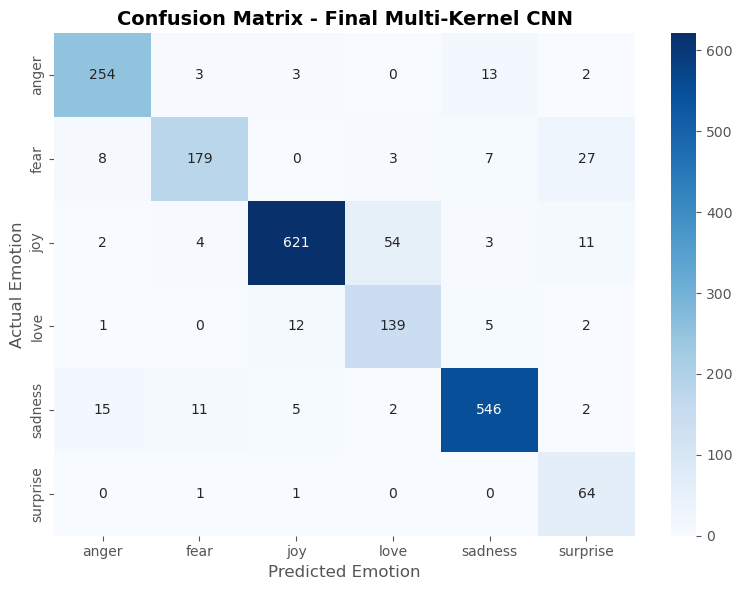

In [142]:
# ================================================================
# Final Confusion Matrix
# ================================================================

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_final = confusion_matrix(
    y_test,
    y_test_pred_final
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm_final,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title(
    "Confusion Matrix - Final Multi-Kernel CNN",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Predicted Emotion")
plt.ylabel("Actual Emotion")

plt.tight_layout()
plt.show()

## Final Model Training History

The training history of the selected Multi-Kernel CNN is analyzed to understand
how training and validation performance changed across epochs.

The selected model uses:
- 64 filters for each convolution kernel
- Kernel sizes 2, 3, and 4
- 128 dense units
- Dropout = 0.30
- Class-balanced training
- Early stopping

In [143]:
# ============================================================
# Final Model Training History
# ============================================================

history_final = history_mkcnn_64_dropout30

print("=" * 70)
print("Final Model Training History")
print("=" * 70)

print("Available Metrics:")
print(history_final.history.keys())

Final Model Training History
Available Metrics:
dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


## Training vs Validation Accuracy

This plot compares training accuracy with validation accuracy across epochs.
It helps identify whether the model continues improving on unseen validation
data or starts overfitting the training data.

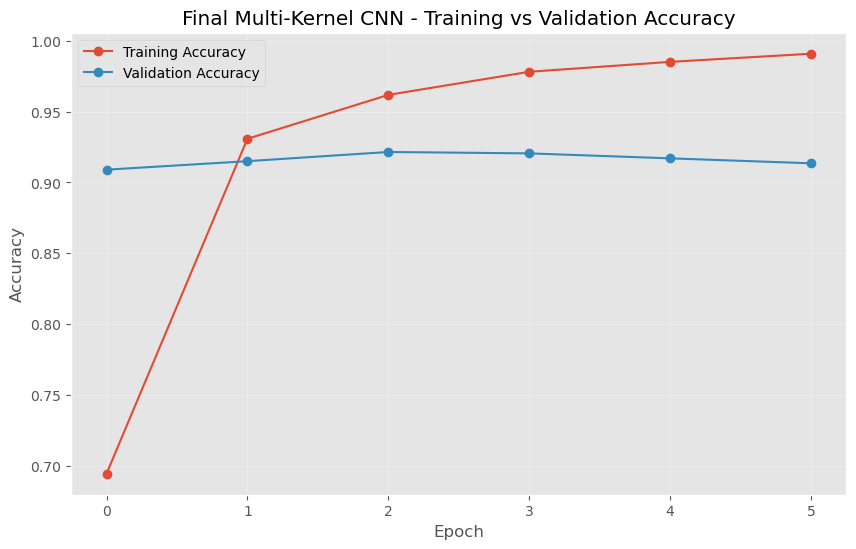

In [144]:
import matplotlib.pyplot as plt

# ============================================================
# Plot Training vs Validation Accuracy
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    history_final.history["accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    history_final.history["val_accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.title("Final Multi-Kernel CNN - Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

The final Multi-Kernel CNN learns the emotion patterns quickly, reaches its best validation performance early, and then begins to overfit the training data. Early stopping successfully prevents excessive overfitting by retaining the best-performing weights.

## Training vs Validation Loss

The loss curves provide another view of the model's learning behavior.
A widening gap between training loss and validation loss is an indication
of overfitting.

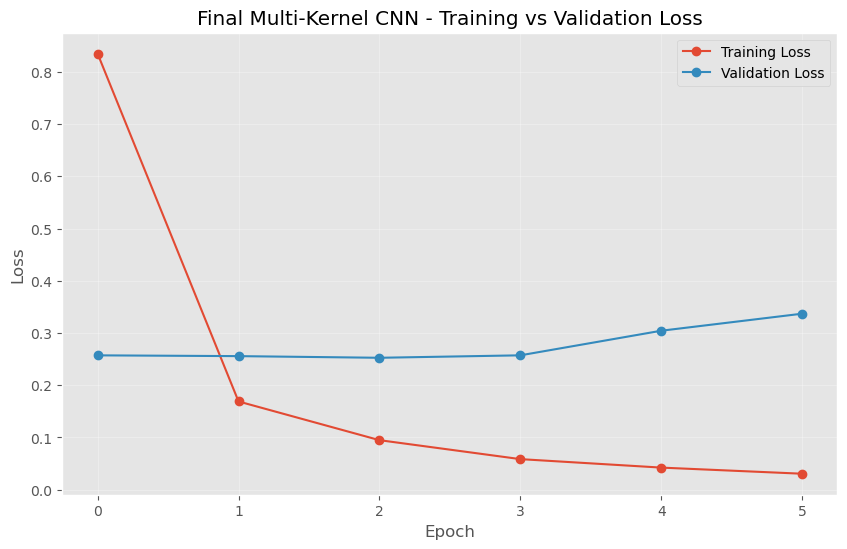

In [145]:
# ============================================================
# Plot Training vs Validation Loss
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    history_final.history["loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    history_final.history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.title("Final Multi-Kernel CNN - Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

The training and validation loss curves show that the model learns rapidly during the initial epochs. Validation loss reaches its minimum at Epoch 3 and subsequently increases while training loss continues to decrease, indicating the onset of overfitting. Early stopping therefore helps retain the model weights corresponding to the best validation performance and prevents unnecessary additional training.

## Best Validation Epoch

The best epoch is identified based on the lowest validation loss used by
the EarlyStopping callback. This confirms which training checkpoint was
selected for the final model.

In [146]:
# ============================================================
# Identify Best Epoch
# ============================================================

val_loss = history_final.history["val_loss"]
val_accuracy = history_final.history["val_accuracy"]

best_loss_epoch = val_loss.index(min(val_loss)) + 1
best_accuracy_epoch = val_accuracy.index(max(val_accuracy)) + 1

print("=" * 70)
print("Best Validation Performance")
print("=" * 70)

print(f"Best Validation Loss    : {min(val_loss):.4f}")
print(f"Best Loss Epoch         : {best_loss_epoch}")

print(f"Best Validation Accuracy: {max(val_accuracy):.4f}")
print(f"Best Accuracy Epoch     : {best_accuracy_epoch}")

Best Validation Performance
Best Validation Loss    : 0.2526
Best Loss Epoch         : 3
Best Validation Accuracy: 0.9215
Best Accuracy Epoch     : 3


## Final Selected Model

The final selected model is a Multi-Kernel Convolutional Neural Network
designed to capture local textual patterns using multiple convolution
kernel sizes.

### Architecture

- Input sequence length: 40
- Embedding dimension: 100
- Convolution filters: 64
- Kernel sizes: 2, 3, and 4
- Pooling: Global Max Pooling
- Combined convolutional features: 192
- Dense units: 128
- Dropout: 0.30
- Output classes: 6
- Optimizer: Adam
- Loss function: Sparse Categorical Crossentropy
- Early stopping: Enabled

In [149]:
# ============================================================
# Final Model - Misclassified Test Samples
# ============================================================

import pandas as pd
import numpy as np

print("=" * 70)
print("Final Model Error Analysis")
print("=" * 70)

# Identify misclassified samples
misclassified_mask = y_test != y_test_pred_final

# Create error analysis DataFrame
error_analysis_df = test_df.loc[misclassified_mask].copy()

# Add actual and predicted labels
error_analysis_df["actual_label"] = [
    emotion_labels[i] for i in y_test[misclassified_mask]
]

error_analysis_df["predicted_label"] = [
    emotion_labels[i] for i in y_test_pred_final[misclassified_mask]
]

# Add prediction confidence
error_analysis_df["prediction_confidence"] = np.max(
    y_test_prob_final[misclassified_mask],
    axis=1
)

# Reset index
error_analysis_df = error_analysis_df.reset_index(drop=True)

print(f"Total Test Samples       : {len(y_test)}")
print(f"Correct Predictions      : {(~misclassified_mask).sum()}")
print(f"Incorrect Predictions    : {misclassified_mask.sum()}")
print(f"Test Accuracy            : {(~misclassified_mask).mean():.4f}")
print(f"Error Rate               : {misclassified_mask.mean():.4f}")

print("\n" + "=" * 70)
print("Misclassified Samples by Actual Emotion")
print("=" * 70)

print(
    error_analysis_df["actual_label"]
    .value_counts()
    .reindex(emotion_labels)
    .fillna(0)
    .astype(int)
)

print("\n" + "=" * 70)
print("First 20 Misclassified Samples")
print("=" * 70)

display(
    error_analysis_df[
        [
            "text",
            "actual_label",
            "predicted_label",
            "prediction_confidence"
        ]
    ].head(20)
)

Final Model Error Analysis
Total Test Samples       : 2000
Correct Predictions      : 1803
Incorrect Predictions    : 197
Test Accuracy            : 0.9015
Error Rate               : 0.0985

Misclassified Samples by Actual Emotion
actual_label
anger       21
fear        45
joy         74
love        20
sadness     35
surprise     2
Name: count, dtype: int64

First 20 Misclassified Samples


,text,actual_label,predicted_label,prediction_confidence
0,i don t feel particularly agitated,fear,anger,0.533257
1,i pay attention it deepens into a feeling of being invaded and helpless,fear,sadness,0.883568
2,im not sure the feeling of loss will ever go away but it may dull to a sweet feeling of nostalgia at what i shared in this life with my dad and the luck i had to have a dad for years,sadness,joy,0.356793
3,i feel very honoured to be included in a magzine which prioritises health and clean living so highly im curious do any of you read magazines concerned with health and clean lifestyles such as the ...,joy,surprise,0.987090
4,im trying to feel out my house style now that im living on my own and have creative carte blanche,joy,anger,0.686798
5,i spent wandering around still kinda dazed and not feeling particularly sociable but because id been in hiding for a couple for days and it was getting to be a little unhealthy i made myself go do...,joy,surprise,0.879592
6,i feel a bit stressed even though all the things i have going on are fun,anger,sadness,0.869620
7,i feel like i am in paradise kissing those sweet lips make me feel like i dive into a magical world of love,joy,love,0.938894
8,i was feeling weird the other day and it went away about minutes after i took my metformin,fear,surprise,0.960526
9,i feel my heart is tortured by what i have done,anger,fear,0.717629


In [150]:
# ============================================================
# Final Model - Error Pattern Analysis
# ============================================================

print("=" * 70)
print("Actual vs Predicted Emotion - Misclassification Analysis")
print("=" * 70)

# Count actual → predicted errors
error_pairs = (
    error_analysis_df
    .groupby(["actual_label", "predicted_label"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

# Keep only incorrect predictions
error_pairs = error_pairs[
    error_pairs["actual_label"] != error_pairs["predicted_label"]
].reset_index(drop=True)

print("\n" + "=" * 70)
print("All Misclassification Patterns")
print("=" * 70)

display(error_pairs)

print("\n" + "=" * 70)
print("Top 10 Misclassification Patterns")
print("=" * 70)

display(error_pairs.head(10))

Actual vs Predicted Emotion - Misclassification Analysis

All Misclassification Patterns


,actual_label,predicted_label,count
0,joy,love,54
1,fear,surprise,27
2,sadness,anger,15
3,anger,sadness,13
4,love,joy,12
5,joy,surprise,11
6,sadness,fear,11
7,fear,anger,8
8,fear,sadness,7
9,sadness,joy,5



Top 10 Misclassification Patterns


,actual_label,predicted_label,count
0,joy,love,54
1,fear,surprise,27
2,sadness,anger,15
3,anger,sadness,13
4,love,joy,12
5,joy,surprise,11
6,sadness,fear,11
7,fear,anger,8
8,fear,sadness,7
9,sadness,joy,5


In [151]:
# ============================================================
# Final Model - Analyze Joy → Love Misclassifications
# ============================================================

joy_love_errors = error_analysis_df[
    (error_analysis_df["actual_label"] == "joy") &
    (error_analysis_df["predicted_label"] == "love")
].copy()

print("=" * 70)
print("Joy → Love Misclassification Analysis")
print("=" * 70)

print(f"Number of Joy → Love Errors : {len(joy_love_errors)}")

print("\n" + "=" * 70)
print("Misclassified Examples")
print("=" * 70)

display(
    joy_love_errors[
        [
            "text",
            "actual_label",
            "predicted_label",
            "prediction_confidence"
        ]
    ].to_string(index=False)
)

Joy → Love Misclassification Analysis
Number of Joy → Love Errors : 54

Misclassified Examples


'                                                                                                                                                                                                                                                                                             text actual_label predicted_label  prediction_confidence\n                                                                                                                                                                                      i feel like i am in paradise kissing those sweet lips make me feel like i dive into a magical world of love          joy            love               0.938894\n                                                                                                                                                                                                                i realized what i am passionate about helping women feel accepted and appreciated          joy           

In [153]:
# ============================================================
# FINAL MODEL - SAVE MODEL AND SUPPORTING OBJECTS
# ============================================================

import os
import pickle

print("=" * 70)
print("Saving Final Multi-Kernel CNN Model")
print("=" * 70)

# ------------------------------------------------------------
# Create directory for final model artifacts
# ------------------------------------------------------------

MODEL_DIR = "final_model"

os.makedirs(MODEL_DIR, exist_ok=True)

# ------------------------------------------------------------
# Save final trained model
# ------------------------------------------------------------

final_model_path = os.path.join(
    MODEL_DIR,
    "multi_kernel_cnn_final.keras"
)

model_mkcnn_64_dropout30.save(final_model_path)

print(f"Final Model Saved : {final_model_path}")

# ------------------------------------------------------------
# Save Label Encoder
# ------------------------------------------------------------

label_encoder_path = os.path.join(
    MODEL_DIR,
    "label_encoder.pkl"
)

with open(label_encoder_path, "wb") as file:
    pickle.dump(label_encoder, file)

print(f"Label Encoder Saved : {label_encoder_path}")

# ------------------------------------------------------------
# Save emotion labels
# ------------------------------------------------------------

emotion_labels_path = os.path.join(
    MODEL_DIR,
    "emotion_labels.pkl"
)

with open(emotion_labels_path, "wb") as file:
    pickle.dump(emotion_labels, file)

print(f"Emotion Labels Saved : {emotion_labels_path}")

# ------------------------------------------------------------
# Display final artifact information
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("FINAL MODEL ARTIFACTS")
print("=" * 70)

for file_name in os.listdir(MODEL_DIR):
    file_path = os.path.join(MODEL_DIR, file_name)
    file_size_mb = os.path.getsize(file_path) / (1024 * 1024)

    print(
        f"{file_name:<40} "
        f"{file_size_mb:.2f} MB"
    )

print("\nFinal model saving completed successfully.")

Saving Final Multi-Kernel CNN Model
Final Model Saved : final_model\multi_kernel_cnn_final.keras
Label Encoder Saved : final_model\label_encoder.pkl
Emotion Labels Saved : final_model\emotion_labels.pkl

FINAL MODEL ARTIFACTS
emotion_labels.pkl                       0.00 MB
label_encoder.pkl                        0.00 MB
multi_kernel_cnn_final.keras             12.45 MB

Final model saving completed successfully.


In [154]:
# ============================================================
# FINAL MODEL - INFERENCE ON NEW TEXT
# ============================================================

import numpy as np
import tensorflow as tf

print("=" * 70)
print("FINAL MODEL - TEXT EMOTION PREDICTION")
print("=" * 70)

# ------------------------------------------------------------
# Load the final saved model
# ------------------------------------------------------------

final_model = tf.keras.models.load_model(
    "final_model/multi_kernel_cnn_final.keras"
)

print("\nFinal model loaded successfully.")

# ------------------------------------------------------------
# Sample new sentences
# ------------------------------------------------------------

sample_texts = [
    "I am extremely happy and excited about the wonderful news.",
    "I feel completely heartbroken and lonely today.",
    "I am really angry about what happened.",
    "I am scared and worried about what might happen next.",
    "I feel deeply connected to the person I love.",
    "Wow, I cannot believe this happened!"
]

# ------------------------------------------------------------
# Tokenize and pad new text
# ------------------------------------------------------------

sample_sequences = tokenizer.texts_to_sequences(sample_texts)

sample_padded = pad_sequences(
    sample_sequences,
    maxlen=40,
    padding="post",
    truncating="post"
)

# ------------------------------------------------------------
# Generate predictions
# ------------------------------------------------------------

sample_probabilities = final_model.predict(
    sample_padded,
    verbose=0
)

sample_predictions = np.argmax(
    sample_probabilities,
    axis=1
)

# ------------------------------------------------------------
# Display predictions
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("PREDICTION RESULTS")
print("=" * 70)

for i, text in enumerate(sample_texts):

    predicted_label = emotion_labels[sample_predictions[i]]

    confidence = sample_probabilities[i][sample_predictions[i]] * 100

    print(f"\nText       : {text}")
    print(f"Prediction : {predicted_label}")
    print(f"Confidence : {confidence:.2f}%")

print("\n" + "=" * 70)
print("Final inference completed successfully.")
print("=" * 70)

FINAL MODEL - TEXT EMOTION PREDICTION

Final model loaded successfully.

PREDICTION RESULTS

Text       : I am extremely happy and excited about the wonderful news.
Prediction : joy
Confidence : 99.75%

Text       : I feel completely heartbroken and lonely today.
Prediction : sadness
Confidence : 100.00%

Text       : I am really angry about what happened.
Prediction : anger
Confidence : 99.66%

Text       : I am scared and worried about what might happen next.
Prediction : anger
Confidence : 54.53%

Text       : I feel deeply connected to the person I love.
Prediction : love
Confidence : 60.49%

Text       : Wow, I cannot believe this happened!
Prediction : anger
Confidence : 69.99%

Final inference completed successfully.


# Final Conclusion and Key Findings

This project developed an end-to-end deep learning based emotion classification system for text using six emotion categories: anger, fear, joy, love, sadness, and surprise.

Several traditional machine learning and deep learning approaches were evaluated. The traditional machine learning models, including Logistic Regression, Decision Tree, and Random Forest, provided reasonable baseline performance, while the deep learning models generally achieved better results by learning useful representations directly from the text.

Among the deep learning approaches, CNN-based models performed particularly well. The Multi-Kernel CNN was designed to capture different local patterns in text using multiple convolutional kernel sizes. Hyperparameter experiments were then performed on the Multi-Kernel CNN architecture by varying the number of filters, dense-layer size, dropout rate, and learning rate.

The final selected architecture was:

- Multi-Kernel CNN
- 64 convolutional filters
- Kernel sizes: 2, 3, and 4
- 128 dense units
- Dropout: 0.30
- Learned word embeddings
- Early stopping during training

The final model achieved the following performance on the independent test set:

| Metric | Test Performance |
|---|---:|
| Accuracy | 90.15% |
| Precision | 91.38% |
| Recall | 90.15% |
| Weighted F1-Score | 90.45% |
| Macro F1-Score | 85.87% |

The confusion matrix and error analysis showed that most classification errors occurred between semantically similar emotions. The largest source of errors was Joy being classified as Love, followed by Fear being classified as Surprise. This indicates that some emotions have overlapping linguistic patterns and can be difficult to distinguish even when the model is confident in its prediction.

Overall, the final Multi-Kernel CNN provided strong performance for the six-class emotion classification problem and demonstrated the effectiveness of multi-kernel convolutional architectures for extracting local linguistic patterns from text.

The trained model and supporting preprocessing artifacts were saved for future inference and deployment.

# Final Project Summary

## Problem Statement

The objective of this project was to develop a deep learning model capable of classifying text into six different emotions:

**anger, fear, joy, love, sadness, and surprise.**

The project followed an end-to-end Natural Language Processing workflow, starting from text preprocessing and traditional machine learning baselines and progressing to multiple deep learning architectures.

---

## Models Evaluated

The following approaches were evaluated during the project:

1. Logistic Regression with Bag of Words
2. Decision Tree with Bag of Words
3. Random Forest with Bag of Words
4. Logistic Regression with TF-IDF
5. Logistic Regression with TF-IDF n-grams
6. Logistic Regression with Word2Vec
7. Embedding + Dense Neural Network
8. LSTM
9. BiLSTM
10. 1D CNN
11. Multi-Kernel CNN
12. Regularized Multi-Kernel CNN
13. Hyperparameter-tuned Multi-Kernel CNN

---

## Final Selected Model

The final model selected based on validation performance and subsequent evaluation on the independent test set was:

**Multi-Kernel CNN**

- Embedding Dimension: 100
- Number of Filters: 64
- Kernel Sizes: 2, 3, 4
- Dense Units: 128
- Dropout Rate: 0.30
- Maximum Sequence Length: 40
- Optimizer: Adam
- Early Stopping: Enabled
- Number of Output Classes: 6

---

## Final Test Performance

| Metric | Score |
|---|---:|
| Accuracy | **90.15%** |
| Precision | **91.38%** |
| Recall | **90.15%** |
| Weighted F1-Score | **90.45%** |
| Macro F1-Score | **85.87%** |

The final test results were obtained using the independent 2,000-sample test dataset.

---

## Key Findings

- Deep learning models generally performed better than the traditional machine learning baselines.
- CNN-based architectures performed particularly well for this text classification problem.
- The Multi-Kernel CNN benefited from using multiple convolutional kernel sizes to capture different local patterns in the text.
- Increasing the number of filters to 256 did not improve performance.
- Increasing the dense layer size to 64 units resulted in unstable and poor predictions, while the 128-unit configuration performed substantially better.
- Dropout tuning showed that a dropout rate of 0.30 provided strong validation performance.
- Learning-rate experiments with 0.0005 and 0.001 did not outperform the selected 0.30-dropout configuration.
- The final test accuracy of **90.15%** demonstrates good generalization to previously unseen text.

---

## Error Analysis

The final model produced:

- **1,803 correct predictions**
- **197 incorrect predictions**
- **90.15% test accuracy**

The most frequent misclassification was:

**Joy → Love**

followed by:

**Fear → Surprise**

These errors are understandable because several emotion categories have overlapping linguistic characteristics. Short, ambiguous, or context-dependent sentences were more difficult for the model to classify correctly.

---

## Final Inference

The trained model was also tested on new, previously unseen sentences. It successfully identified several clearly expressed emotions such as joy, sadness, anger, and love.

This demonstrates that the trained Multi-Kernel CNN can be used as an emotion prediction model for new text inputs.

---

## Model Artifacts

The final trained model and supporting objects were saved for future use:

- `multi_kernel_cnn_final.keras`
- `label_encoder.pkl`
- `emotion_labels.pkl`

These artifacts can be used to reload the trained model and perform predictions without retraining the model.

---

## Final Conclusion

The project successfully developed an end-to-end deep learning based NLP system for emotion classification.

The final Multi-Kernel CNN achieved **90.15% accuracy and 90.45% weighted F1-score on the independent test set**, demonstrating that convolutional neural networks with multiple kernel sizes can effectively learn useful local patterns from text for multi-class emotion classification.

In [156]:
import os
import pickle

# Create final_model directory if it does not exist
os.makedirs("final_model", exist_ok=True)

# Save tokenizer
with open("final_model/tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

print("=" * 70)
print("Tokenizer Saved Successfully")
print("=" * 70)
print("Tokenizer Saved :", "final_model/tokenizer.pkl")

# Verify
with open("final_model/tokenizer.pkl", "rb") as f:
    tokenizer_check = pickle.load(f)

print("Tokenizer Type  :", type(tokenizer_check))
print("Vocabulary Size :", len(tokenizer_check.word_index) + 1)

Tokenizer Saved Successfully
Tokenizer Saved : final_model/tokenizer.pkl
Tokenizer Type  : <class 'keras.src.legacy.preprocessing.text.Tokenizer'>
Vocabulary Size : 11866
